In [14]:
# Run code with Python 3.8.0 
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
#mpl.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
sns.set_style("white")
sns.set_style("ticks") 

from moviepy.editor import VideoClip
from moviepy.video.io.bindings import mplfig_to_npimage

from scipy.stats import ttest_ind
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

import matlab.engine
eng = matlab.engine.start_matlab()
import sys

# Manual Data Download From Deep Learning

In [ ]:
def load_freely_moving(file_path, file_prefix):

    """
    Load data in as dictionary where keys are frame number (t1,t2,etc.) and key into numpy array with the following columns:
    1) Pixel index
    2) Normalized (?)
    3) X
    4) Y
    5) X_um
    6) Y_um
    7) RFP
    8) GCaMP
    9) RFP-GCaMP_Ratio
    10) GCaMP_adj_x
    11) GCaMP_adj_y
    The remaining columns all have the same value for each row (pixel)
    12) Soma_RFP_X position
    13) Soma_RFP_Y position
    14) Soma_RFP_Mean_Value
    15) Soma_GCaMP_X position
    16) Soma_GCaMP_Y position
    17) Soma_GCaMP_Mean_Value
    """
    import glob
    numFrames = len(glob.glob(file_path+"/*.csv"))
    print('Total frames', numFrames)
    data = {}
    lacking_data = []
    for i in range(numFrames):
        name = file_path+"/"+file_prefix+"MMStack_t"+str(i+1)+".csv"
        temp = np.loadtxt(name, delimiter=',', skiprows=1)
        #print np.shape(temp)
        if len(np.shape(temp)) < 2:
            #print (i+1),"This frame is lacking data"
            lacking_data.append(i+1)
            continue
        else:
            data[str(i+1)] = temp

    print('Frames with no data', lacking_data)

    meta_dict = {}
    with open(file_path+"/"+file_prefix+"MMStack_Pos0_metadata.txt", "r") as metadata:
        for line in metadata:
            pieces = line.split(":")
            if len(pieces) < 2:
                continue
            else:
                if "FrameKey" in pieces[0]:
                    key = str(int(pieces[0].split("-")[1])+1)
                    meta_dict[key] = {}
                else:
                    if eval(pieces[0].strip()) == "MeasuredStageX":
                        meta_dict[key]["StageX"] = float(pieces[1].strip().strip(','))
                    elif eval(pieces[0].strip()) == "MeasuredStageY":
                        meta_dict[key]["StageY"] = float(pieces[1].strip().strip(','))
                    elif eval(pieces[0].strip()) == "ElapsedTime-ms":
                        meta_dict[key]["ElapsedTime"] = float(pieces[1].strip().strip(','))
                        
    xFOV = []
    yFOV = []
    Time = []
    NeuronXPos = []
    NeuronYPos = []
    Soma_RFP_mean = []
    Soma_GCaMP_mean = []
    SomaRatio = []
    frame_list = []
    for frame in data.keys():
        if np.isnan([meta_dict[frame]["StageX"], meta_dict[frame]["StageY"], float(meta_dict[frame]["ElapsedTime"]), \
                     np.nanmean(data[frame][:,11]), np.nanmean(data[frame][:,12]), int(frame), np.nanmean(list(data[frame][:,13].astype(float))),\
                     np.nanmean(list(data[frame][:,16].astype(float)))]).any():
            continue
        else:
            xFOV.append(meta_dict[frame]["StageX"])
            yFOV.append(meta_dict[frame]["StageY"])
            Time.append(float(meta_dict[frame]["ElapsedTime"])/1000)
            NeuronXPos.append(np.nanmean(data[frame][:,11])*1.26)
            NeuronYPos.append(np.nanmean(data[frame][:,12])*1.26)
            frame_list.append(int(frame))
            temp_RFP = np.nanmean(list(data[frame][:,13].astype(float)))
            temp_GCaMP = np.nanmean(list(data[frame][:,16].astype(float)))
            Soma_RFP_mean.append(temp_RFP)
            Soma_GCaMP_mean.append(temp_GCaMP)
            SomaRatio.append(temp_GCaMP/temp_RFP)
        
    frame_list_sorted, Soma_RFP_mean_sorted, Soma_GCaMP_mean_sorted, Soma_Ratio_sorted, xFOV_sorted, yFOV_sorted, \
    NeuronXPos_sorted, NeuronYPos_sorted, Time_sorted = (list(t) for t in zip(*sorted(zip(frame_list,Soma_RFP_mean, \
                                        Soma_GCaMP_mean, SomaRatio, xFOV, yFOV, NeuronXPos, NeuronYPos, Time))))
    
    return frame_list_sorted, Soma_RFP_mean_sorted, Soma_GCaMP_mean_sorted, Soma_Ratio_sorted, xFOV_sorted, yFOV_sorted, \
    NeuronXPos_sorted, NeuronYPos_sorted, Time_sorted
    

def stitch_and_analyze_free_move(directories, prefixes, Origin, Gradient):
    #Gradient is degrees C change per cm (shallow is often 2 deg C over 7 cm, steep is 7 deg C over 7 cm)
    #Origin is temperature at start (left end) of gradient
    steepness=((Gradient)*10**-4) #converting gradient steepnes to celcius/um
    frame_list_sorted = []
    Soma_RFP_mean_sorted = []
    Soma_GCaMP_mean_sorted = []
    Soma_Ratio_sorted = []
    xFOV_sorted = []
    yFOV_sorted = []
    NeuronXPos_sorted = []
    NeuronYPos_sorted = []
    Time_sorted = []

    for i in range(len(directories)):
        print(directories[i])
        frame_list_temp, Soma_RFP_mean_temp, Soma_GCaMP_mean_temp, Soma_Ratio_temp, xFOV_temp, yFOV_temp, NeuronXPos_temp, \
        NeuronYPos_temp, Time_temp = load_freely_moving(directories[i],prefixes[i])
        if i == 0:
            frame_list_sorted += frame_list_temp
            Time_sorted += Time_temp
        else:
            last_frame = max(frame_list_sorted)
            last_time = max(Time_sorted)
            frame_list_sorted += [j + last_frame for j in frame_list_temp]
            Time_sorted += [j + last_time for j in Time_temp]
        Soma_RFP_mean_sorted += Soma_RFP_mean_temp
        Soma_GCaMP_mean_sorted += Soma_GCaMP_mean_temp
        Soma_Ratio_sorted += Soma_Ratio_temp
        xFOV_sorted += xFOV_temp
        yFOV_sorted += yFOV_temp
        NeuronXPos_sorted += NeuronXPos_temp
        NeuronYPos_sorted += NeuronYPos_temp
    
    yVal = []
    xVal = []
    deltaX = []
    X0 = 15544.999 #this is position at right courner of stage where temp is Xc
    deltaT=[]
    TxTip = []
    for i in range(len(NeuronYPos_sorted)):
        neuron_Ypos = (NeuronYPos_sorted[i]+yFOV_sorted[i])*(-1)
        yVal.append(neuron_Ypos)
        neuron_Xpos = NeuronXPos_sorted[i]+xFOV_sorted[i]
        xVal.append(neuron_Xpos)
        X_moved = neuron_Xpos - X0
        deltaX.append(X_moved)
        temp_change = X_moved*steepness
        deltaT.append(temp_change)
        TxTip.append(temp_change+Origin)

    Soma_GCaMP_smoothed = gaussian_filter1d(Soma_GCaMP_mean_sorted, sigma=25)
    Soma_Ratio_smoothed = gaussian_filter1d(Soma_Ratio_sorted, sigma=25)
    plt.clf()
    plt.figure(figsize=(4,4),dpi=300)#plt.ylim(0,1)
    ax1 = plt.subplot(1,1,1)
    ax1.plot(Time_sorted, TxTip, 'k')
    ax1.set_ylabel('Temp (Deg C)', fontsize=15)
    ax1.set_xlabel('Time (s)', fontsize=15)
    ax1.set_ylim(min(TxTip),max(TxTip))
    ax1.set_xlim(0, max(Time_sorted))
    ax1.tick_params(axis = 'both', labelsize=15)
    ax2 = ax1.twinx()
    ax2.plot(Time_sorted,Soma_Ratio_smoothed, 'r', lw=2)
    ax2.set_ylabel('Soma Ratio (GCaMP/RFP)', fontsize=15)
    ax2.set_xlabel('Time (s)', fontsize=15)
    ax2.set_ylim(min(Soma_Ratio_smoothed), max(Soma_Ratio_smoothed))
    ax2.set_xlim(0, max(Time_sorted))
    ax2.tick_params(axis = 'both', labelsize=15)
    plt.show()
    plt.close()
    
    return yVal, xVal, TxTip, Soma_GCaMP_smoothed, Soma_Ratio_smoothed, Time_sorted

In [ ]:
directories = ["2_5_20_19to21_Tc25_2__2_1__2_2__2_3/GCY8Mix_5.5_19to21_Tc25_2_/CSVs_Multi", \
               "2_5_20_19to21_Tc25_2__2_1__2_2__2_3/GCY8Mix_5.5_19to21_Tc25_2__1/CSVs_Multi", \
               "2_5_20_19to21_Tc25_2__2_1__2_2__2_3/GCY8Mix_5.5_19to21_Tc25_2__2/CSVs_Multi", \
               "2_5_20_19to21_Tc25_2__2_1__2_2__2_3/GCY8Mix_5.5_19to21_Tc25_2__3/CSVs_Multi"]
prefixes = ["", "GCY8Mix_5.5_19to21_Tc25_2__1_", "GCY8Mix_5.5_19to21_Tc25_2__2_", "GCY8Mix_5.5_19to21_Tc25_2__3_"]

Shallow_5p5_2_5_20_2 = {}
Shallow_5p5_2_5_20_2['y'], Shallow_5p5_2_5_20_2['x'], Shallow_5p5_2_5_20_2['Temp'], Shallow_5p5_2_5_20_2['GCaMP'], \
Shallow_5p5_2_5_20_2['Ratio'], Shallow_5p5_2_5_20_2['Time'] = stitch_and_analyze_free_move(directories, prefixes, 19, float(2/7))

2_5_20_19to21_Tc25_1__1_1\GCY8Mix_5.5_19to21_Tc25_1_\CSVs_Multi
Total frames 4995
Frames with no data [148, 149, 150, 1363, 1364, 1365, 2596, 2597, 3095, 3126, 3131, 3490, 3491, 3492, 3493, 3494, 3495, 4036, 4357]
2_5_20_19to21_Tc25_1__1_1\GCY8Mix_5.5_19to21_Tc25_1__1\CSVs_Multi
Total frames 4995
Frames with no data [85, 86, 87, 88, 181, 1543, 1576, 1636, 1637, 1638, 1639, 1640, 1641, 1642, 1643, 1644, 1645, 1646, 1647, 1648, 1649, 1650, 1651, 1652, 1653, 1654, 1655, 1656, 1657, 1658, 1659, 1660, 1661, 1662, 1663, 1664, 1665, 1666, 1667, 1668, 1669, 1670, 1671, 1672, 1673, 1674, 1675, 1676, 1677, 1678, 1679, 1680, 1924, 1925, 1926, 1927, 1928, 1929, 3602, 3662, 3663, 4340, 4341, 4342, 4343, 4344, 4345, 4346, 4347, 4348, 4349, 4350]


<Figure size 432x288 with 0 Axes>

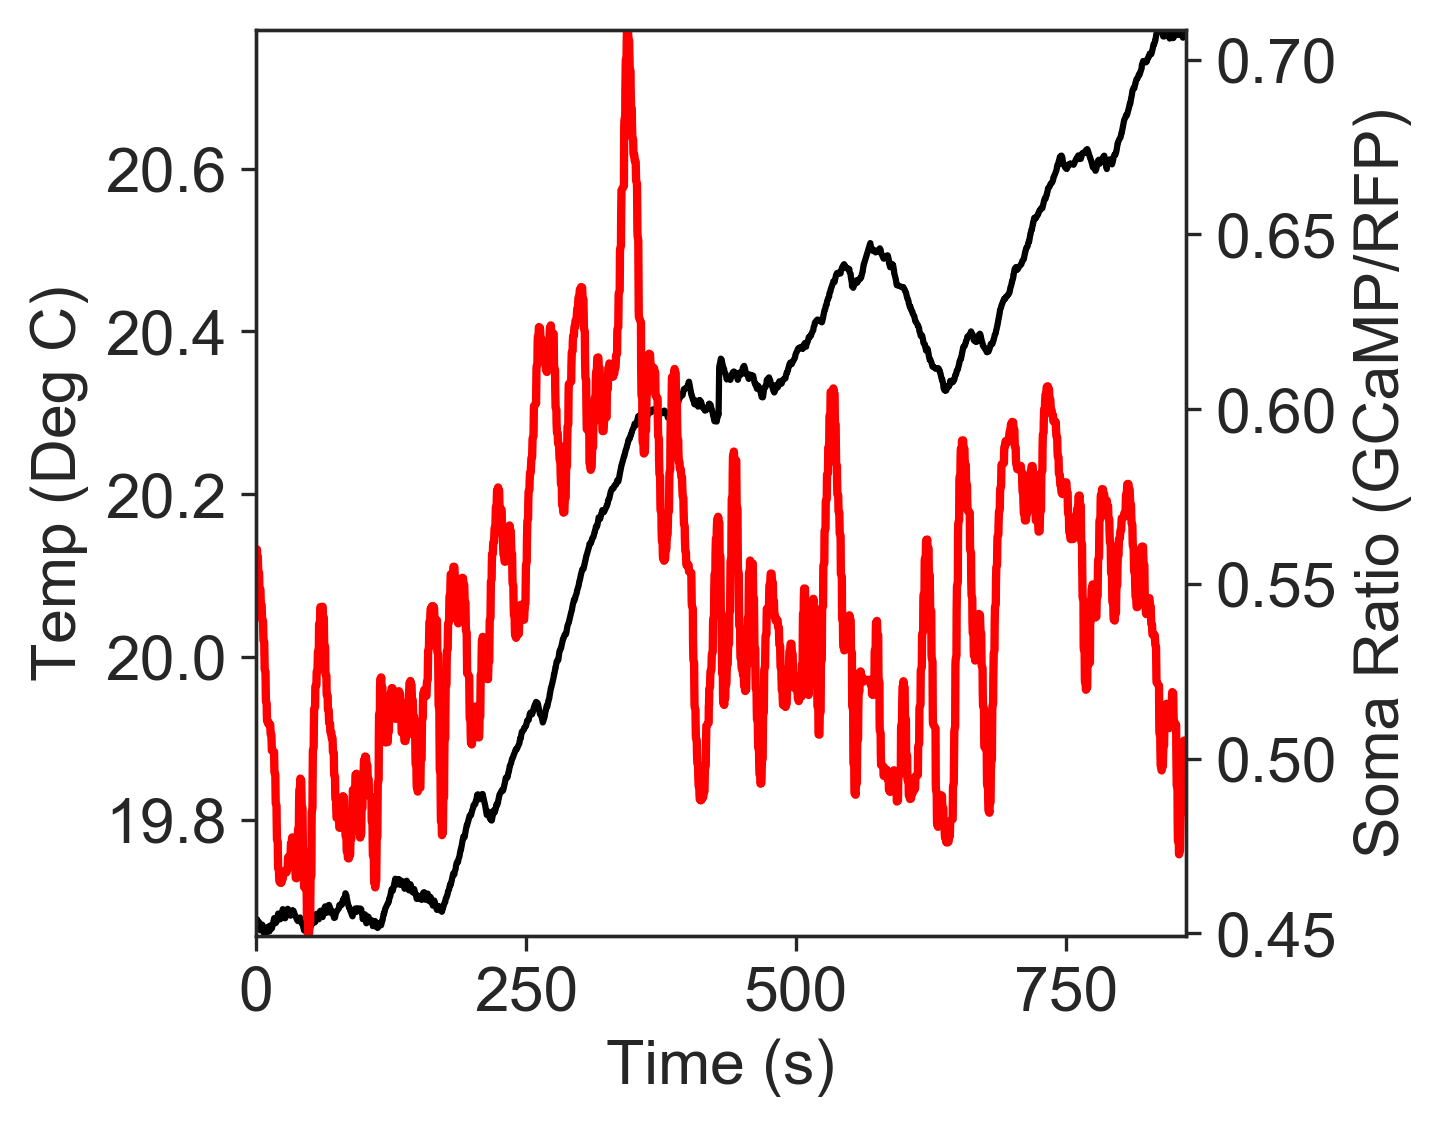

In [ ]:
directories = ["2_5_20_19to21_Tc25_1__1_1/GCY8Mix_5.5_19to21_Tc25_1_/CSVs_Multi", \
               "2_5_20_19to21_Tc25_1__1_1/GCY8Mix_5.5_19to21_Tc25_1__1/CSVs_Multi"]
prefixes = ["", "GCY8Mix_5.5_19to21_Tc25_1__1_"]

Shallow_5p5_2_5_20_1 = {}
Shallow_5p5_2_5_20_1['y'], Shallow_5p5_2_5_20_1['x'], Shallow_5p5_2_5_20_1['Temp'], Shallow_5p5_2_5_20_1['GCaMP'], \
Shallow_5p5_2_5_20_1['Ratio'], Shallow_5p5_2_5_20_1['Time'] = stitch_and_analyze_free_move(directories, prefixes, 19, float(2/7))

3_5_20_17to24_Tc25_2_3__2_4__2_5\input_2_3
Total frames 4995
Frames with no data [366, 367, 368, 458, 3527, 3528, 3529, 3530, 3531, 3532, 3533, 4735, 4840, 4842, 4843, 4845, 4921]
3_5_20_17to24_Tc25_2_3__2_4__2_5\input_2_4
Total frames 4995
Frames with no data [446, 447, 448, 834, 836, 869, 916, 1089, 1305, 1359, 1360, 1361, 1364, 1390, 1391, 1392, 1393, 1394, 1395, 1486, 2254, 2255, 2256, 2257]
3_5_20_17to24_Tc25_2_3__2_4__2_5\input_2_5
Total frames 4995
Frames with no data [4962, 4963, 4964, 4966, 4969, 4970, 4971, 4972, 4973, 4974, 4975, 4976, 4978, 4979, 4980, 4981, 4993, 4994]


<Figure size 432x288 with 0 Axes>

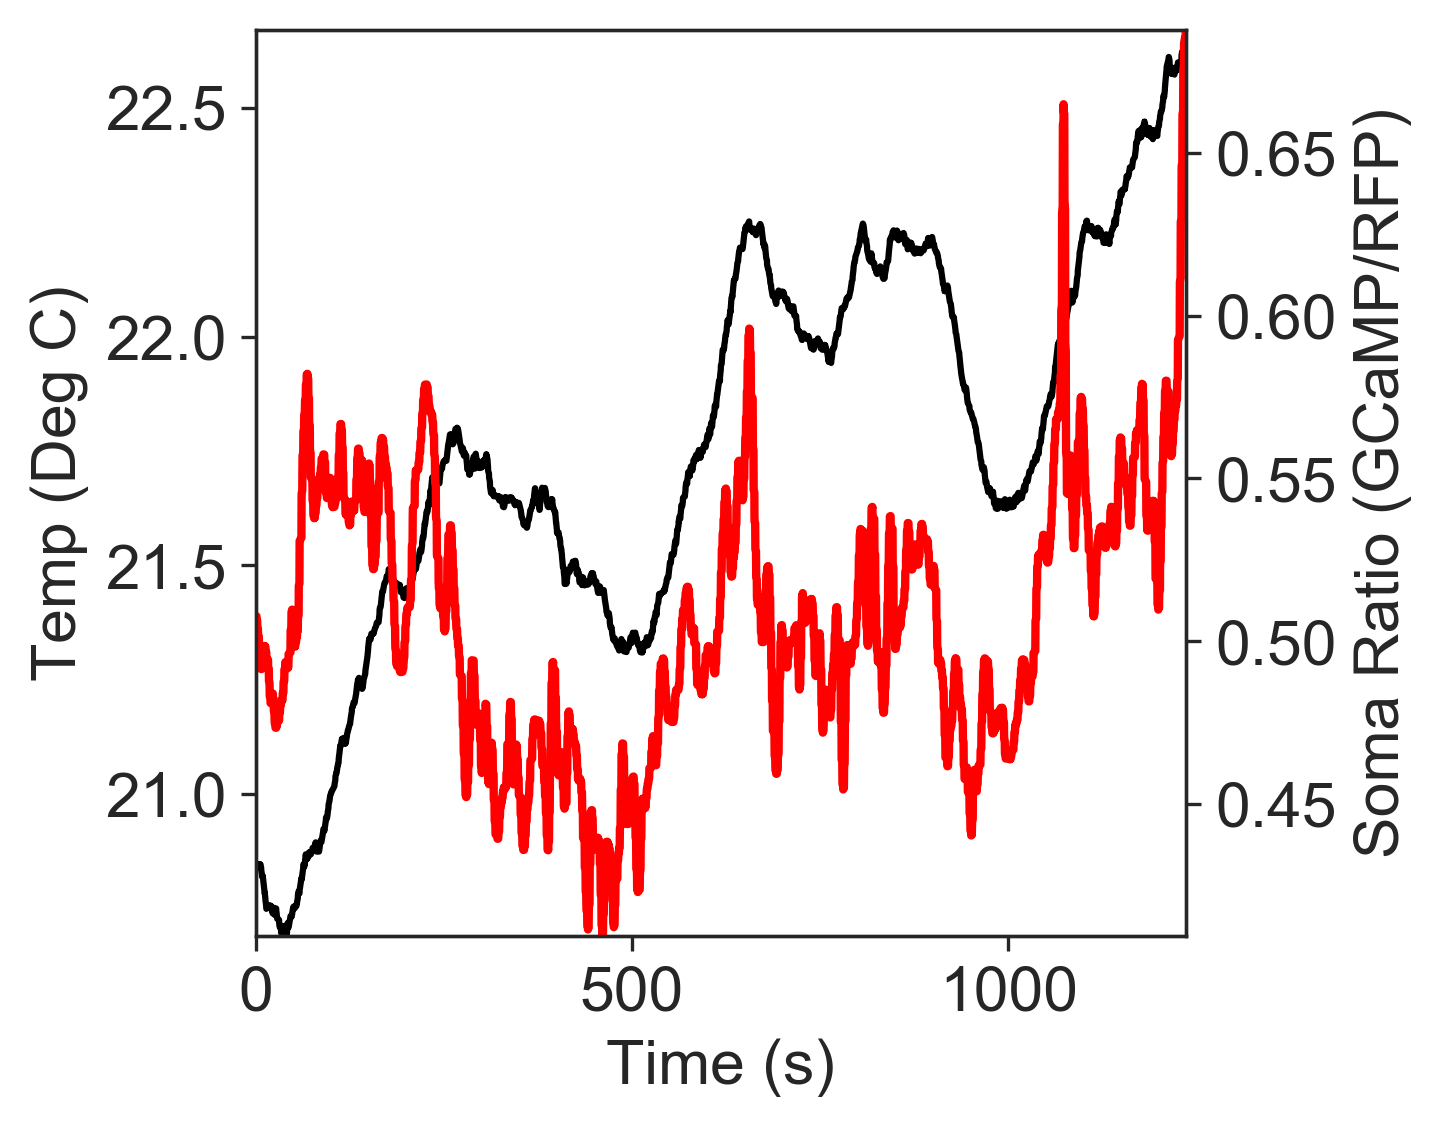

In [ ]:
directories = ["3_5_20_17to24_Tc25_2_3__2_4__2_5\input_2_3", \
               "3_5_20_17to24_Tc25_2_3__2_4__2_5\input_2_4", \
               "3_5_20_17to24_Tc25_2_3__2_4__2_5\input_2_5"]
prefixes = ["GCY8Mix_5.5_Tc25_17to24_2__3_", "GCY8Mix_5.5_Tc25_17to24_2__4_", "GCY8Mix_5.5_Tc25_17to24_2__5_"]

Steep_5p5_3_5_20_1 = {}
Steep_5p5_3_5_20_1['y'], Steep_5p5_3_5_20_1['x'], Steep_5p5_3_5_20_1['Temp'], Steep_5p5_3_5_20_1['GCaMP'], \
Steep_5p5_3_5_20_1['Ratio'], Steep_5p5_3_5_20_1['Time'] = stitch_and_analyze_free_move(directories, prefixes, 17, 1.0)

# Data Import From CSV

In [15]:
step = 10
def downsamp(TxTip, step):
    TxTip_downsamp = [TxTip[0]]
    for i in range(step+1,len(TxTip),step):
        TxTip_downsamp.append(TxTip[i])
    return TxTip_downsamp
        
def interpolate(temp_deriv_downsamp_per_sec, final_length, step):
    temp_deriv_downsamp_per_sec_interp = [temp_deriv_downsamp_per_sec[0]]
    for i in range(1,len(temp_deriv_downsamp_per_sec)):
        for j in range(step):
            temp_deriv_downsamp_per_sec_interp.append(temp_deriv_downsamp_per_sec[i-1]+((temp_deriv_downsamp_per_sec[i]-temp_deriv_downsamp_per_sec[i-1])/step)*j)
    final_temp_deriv_downsamp_per_sec = temp_deriv_downsamp_per_sec[len(temp_deriv_downsamp_per_sec)-1]
    dum = temp_deriv_downsamp_per_sec_interp[len(temp_deriv_downsamp_per_sec_interp)-1]
    add_step = (final_temp_deriv_downsamp_per_sec - dum)/(len(temp_deriv_downsamp_per_sec)-max(range(step+1,len(temp_deriv_downsamp_per_sec),step)))
    for i in range((final_length-max(range(step+1,final_length,step)))):
        dum += add_step
        temp_deriv_downsamp_per_sec_interp.append(dum)
    return temp_deriv_downsamp_per_sec_interp

def find_start_stop(i, frame_list_sorted):
    start = 0
    stop = 0
    if i[0] in frame_list_sorted and i[1] in frame_list_sorted:
        start = frame_list_sorted.index(i[0])
        stop = frame_list_sorted.index(i[1])
    elif i[0] not in frame_list_sorted:
        dum_range = 1
        check = 0
        while check == 0:
            if (i[0]-dum_range) in frame_list_sorted:
                start = frame_list_sorted.index(i[0]-dum_range)
                stop = frame_list_sorted.index(i[1])
                check = 1
            else:
                dum_range += 1
    elif i[1] not in frame_list_sorted:
        dum_range = 1
        check = 0
        while check == 0:
            if (i[1]-dum_range) in frame_list_sorted:
                start = frame_list_sorted.index(i[0])
                stop = frame_list_sorted.index(i[1]-dum_range)
                check = 1
            else:
                dum_range += 1
    else:
        print(i[0],'issue')
    
    return start,stop

def find_start_stop(i, frame_list_sorted):
    """
    Safely finds the index of the frame closest to i[0] and i[1].
    This prevents ValueErrors when exact frames are missing.
    """
    
    # Helper to find the nearest index in the list
    def get_closest_index(val, frame_list):
        # Find the value in the list with the smallest difference to 'val'
        closest_val = min(frame_list, key=lambda x: abs(x - val))
        return frame_list.index(closest_val)
    
    # Use the helper for both start and stop independently
    # This handles cases where start, stop, or both are missing
    try:
        start = frame_list_sorted.index(i[0])
    except ValueError:
        start = get_closest_index(i[0], frame_list_sorted)
        
    try:
        stop = frame_list_sorted.index(i[1])
    except ValueError:
        stop = get_closest_index(i[1], frame_list_sorted)
        
    return start, stop

# Steep

## 3_4_20 

In [16]:
reversals_steep_3_4_20 = [ (15,30), (60,105), (180,210), (225,240), (255,280), (525,555), (585,595), (765,795), (845,875), (885,900), (915,930), (960,1005), (1030,1050), (1065,1090), (1290,1305), (1350,1365), (1740,1755), (1770,1785), (1800,1855), (2130,2230), (2230,2260), (2260,2340), (2430,2455), (2490,2530), (2775,2790), (2810,2850), 
             (2910,3000), (3105,3120), (3150,3165), (3195,3210), (3225,3255), (3525,3550), (3600,3620), (3650,3680), (3885,3955), (3975,4045), (4045,4085), (4220,4240), (4325,4340), (4355,4370), (4530,4560), (4645,4665), (4680,4695), (4930,4965), (5110,5180), (5190,5235), (5480,5505), (5520,5560), (5575,5625),
             (5690,5720), (5730,5805), (5835,5850), (5865,5925), (6150,6175), (6305,6315), (6350,6370), (6555,6570), (6675,6700), (6725,6800), (6800,6825), (6900,6925), (7025,7055), (7170,7230), (7260,7280), (7560,7620), (7660,7720), (7820,7850), (7905,7935), (8160,8185), (8205,8300), (8310,8350), (8360,8380), (8400,8430),
            (8520,8550), (8645,8695), (8715,8745), (8925,8935), (8955,8970), (9150,9165), (9185,9210), (9255,9290), (9300,9320), (9345,9360), (9375,9390), (9700,9765), (9780,9800), (9810,9855)
]

omega_turns_steep_3_4_20 = [ (105,150), (280,310), (2530,2550), (3255,3310), (4085,4160), (5560,5575), (5625,5690), (5720,5730), (5805,5835), (5925,5980), (7720,7760), (7850,7905), (8380,8400), (8430,8470),
]
run_east_video_steep_3_4_20 = [
    (310,525), (595,765), (795,845), (1185,1290), (1305,1350), (1365,1560), (1625,1750), (1855,2130), (3310,3525), (3570,3600), (3680,3830), (4370,4530), (4665,4680), (4695,4930), (5040,5110), (5980,6150), (6175,6350), (6370,6555), (6570,6655), (7350,7560), (7935,8040), (8040,8160), (8805,8925), (9035,9150), (9390,9700), (9855,9990),
]
run_not_e_video_steep_3_4_20 = [
    (1,15), (150,180), (875,885), (900,915), (1090,1185), (2655,2775), (2850,2910), (3000,3105), (3120,3150), (3165,3195), (4160,4220), (5260,5480), (8040,8160)
]
pause_explore_bend_steep_3_4_20 = [
    (30,60), (210,225), (240,255), (555,585), (930,960), (1005,1030), (1050,1065), (1560,1625), (1755,1770), (1785,1800), (2340,2430), (2455,2490), (2550,2655), (2790,2810), (3210,3225), (3550,3570), (3620,3650), (3830,3885), (3955,3975), (4240,4325), (4340,4355), (4560,4625), (4625,4645), (4965,5040),
    (5180,5190), (5235,5260), (5505,5520), (5850,5865), (5850,5865), (6655,6675), (6700,6725), (6825,6900), (6925,6960), (6960,7025), (7055,7095), (7095,7170), (7230,7260), (7280,7350), (7620,7660), (7760,7820), (8185,8205), (8300,8310), (8350,8360), (8470,8520), (8550,8620), (8620,8645), (8695,8715), 
    (8745,8805),  (8935,8955),  (8970,9035),  (9165,9185),  (9210,9255),  (9290,9300),  (9320,9345), (9360,9375), (9765,9780), (9800,9810)
]

plateaus_steep_3_4_20 = [(700,850),(1500,2100), (3450,3800), (4500,4900), (6000,6500)]

In [17]:
source = "csv"
if source == "csv": 
    # Load the CSV file
    pref = "Freely_Moving_Coordinates/"
    file_path = pref + "Steep_8p1_3_4_20_1_data.csv"
    file_path2 = pref + "Steep_8p1_3_4_20_1_data_wUnsmoothed.csv"  
    df = pd.read_csv(file_path)
    df2 = pd.read_csv(file_path2)
    
    # Store each column in its own list
    Ycoord_steep_3_4_20       = df['y'].tolist()
    Xcoord_steep_3_4_20       = df['x'].tolist()
    Temp_steep_3_4_20    = df['Temp'].tolist()
    Time_steep_3_4_20    = df['Time'].tolist()
    Frames_steep_3_4_20  = df['frames'].tolist()
    DeltaR_steep_3_4_20 = df['Delta_R'].tolist()
    DeltaR_steep_3_4_20_unsmoothed = df2['Delta_R_unsmoothed'].tolist()
    Soma_Ratio_3_4_20_unsmoothed = df2['Soma_Ratio_unsmoothed'].tolist()
    Xcoord_Norm_steep_3_4_20       = df2['x_Normalized_um_unsmoothed'].tolist()
    

<Figure size 640x480 with 0 Axes>

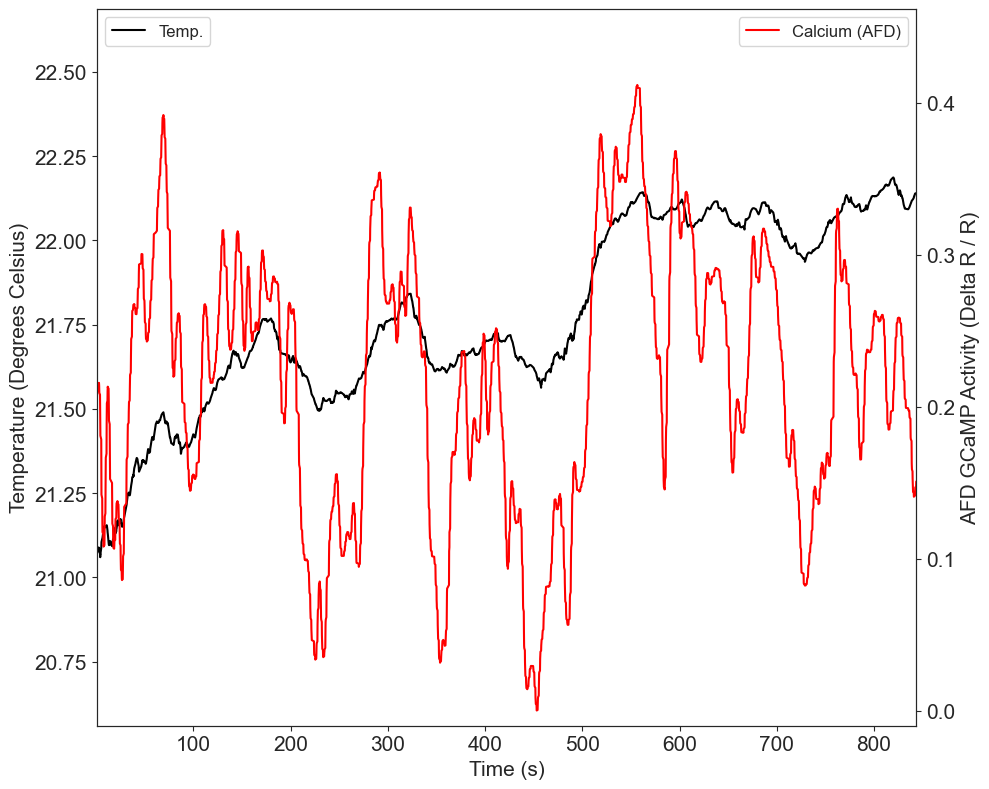

In [18]:
import matplotlib.pyplot as plt

# --- 1. Setup the Figure ---
plt.clf()
fig, ax1 = plt.subplots(figsize=(10, 8))

# --- 2. Plot Temperature on the Left (ax1) ---
ax1.plot(Time_steep_3_4_20, Temp_steep_3_4_20, color='k', label='Temp.')

ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize=15)
ax1.set_xlabel('Time (s)', fontsize=15)

# Formatting ticks and limits
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)
ax1.set_xlim(min(Time_steep_3_4_20), max(Time_steep_3_4_20))
ax1.set_ylim(min(Temp_steep_3_4_20) - 0.5, max(Temp_steep_3_4_20) + 0.5) # Auto-adjusting window

ax1.legend(loc='upper left', fontsize=12)

# --- 3. Plot Calcium Activity on the Right (ax2) ---
ax2 = ax1.twinx()
ax2.plot(Time_steep_3_4_20, DeltaR_steep_3_4_20, color='r', lw=1.5, label='Calcium (AFD)')

ax2.set_ylabel('AFD GCaMP Activity (Delta R / R)', fontsize=15)
ax2.set_ylim(min(DeltaR_steep_3_4_20) - 0.01, max(DeltaR_steep_3_4_20) + 0.05) # Auto-adjusting window

# Match template tick formatting
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2.legend(loc='upper right', fontsize=12)

# --- 4. Final Touches ---
plt.tight_layout()

# Uncomment to save
#plt.savefig('Steep_3_4_20_Calcium_vs_Temp.svg', dpi=600, bbox_inches='tight')

plt.show()

<Figure size 640x480 with 0 Axes>

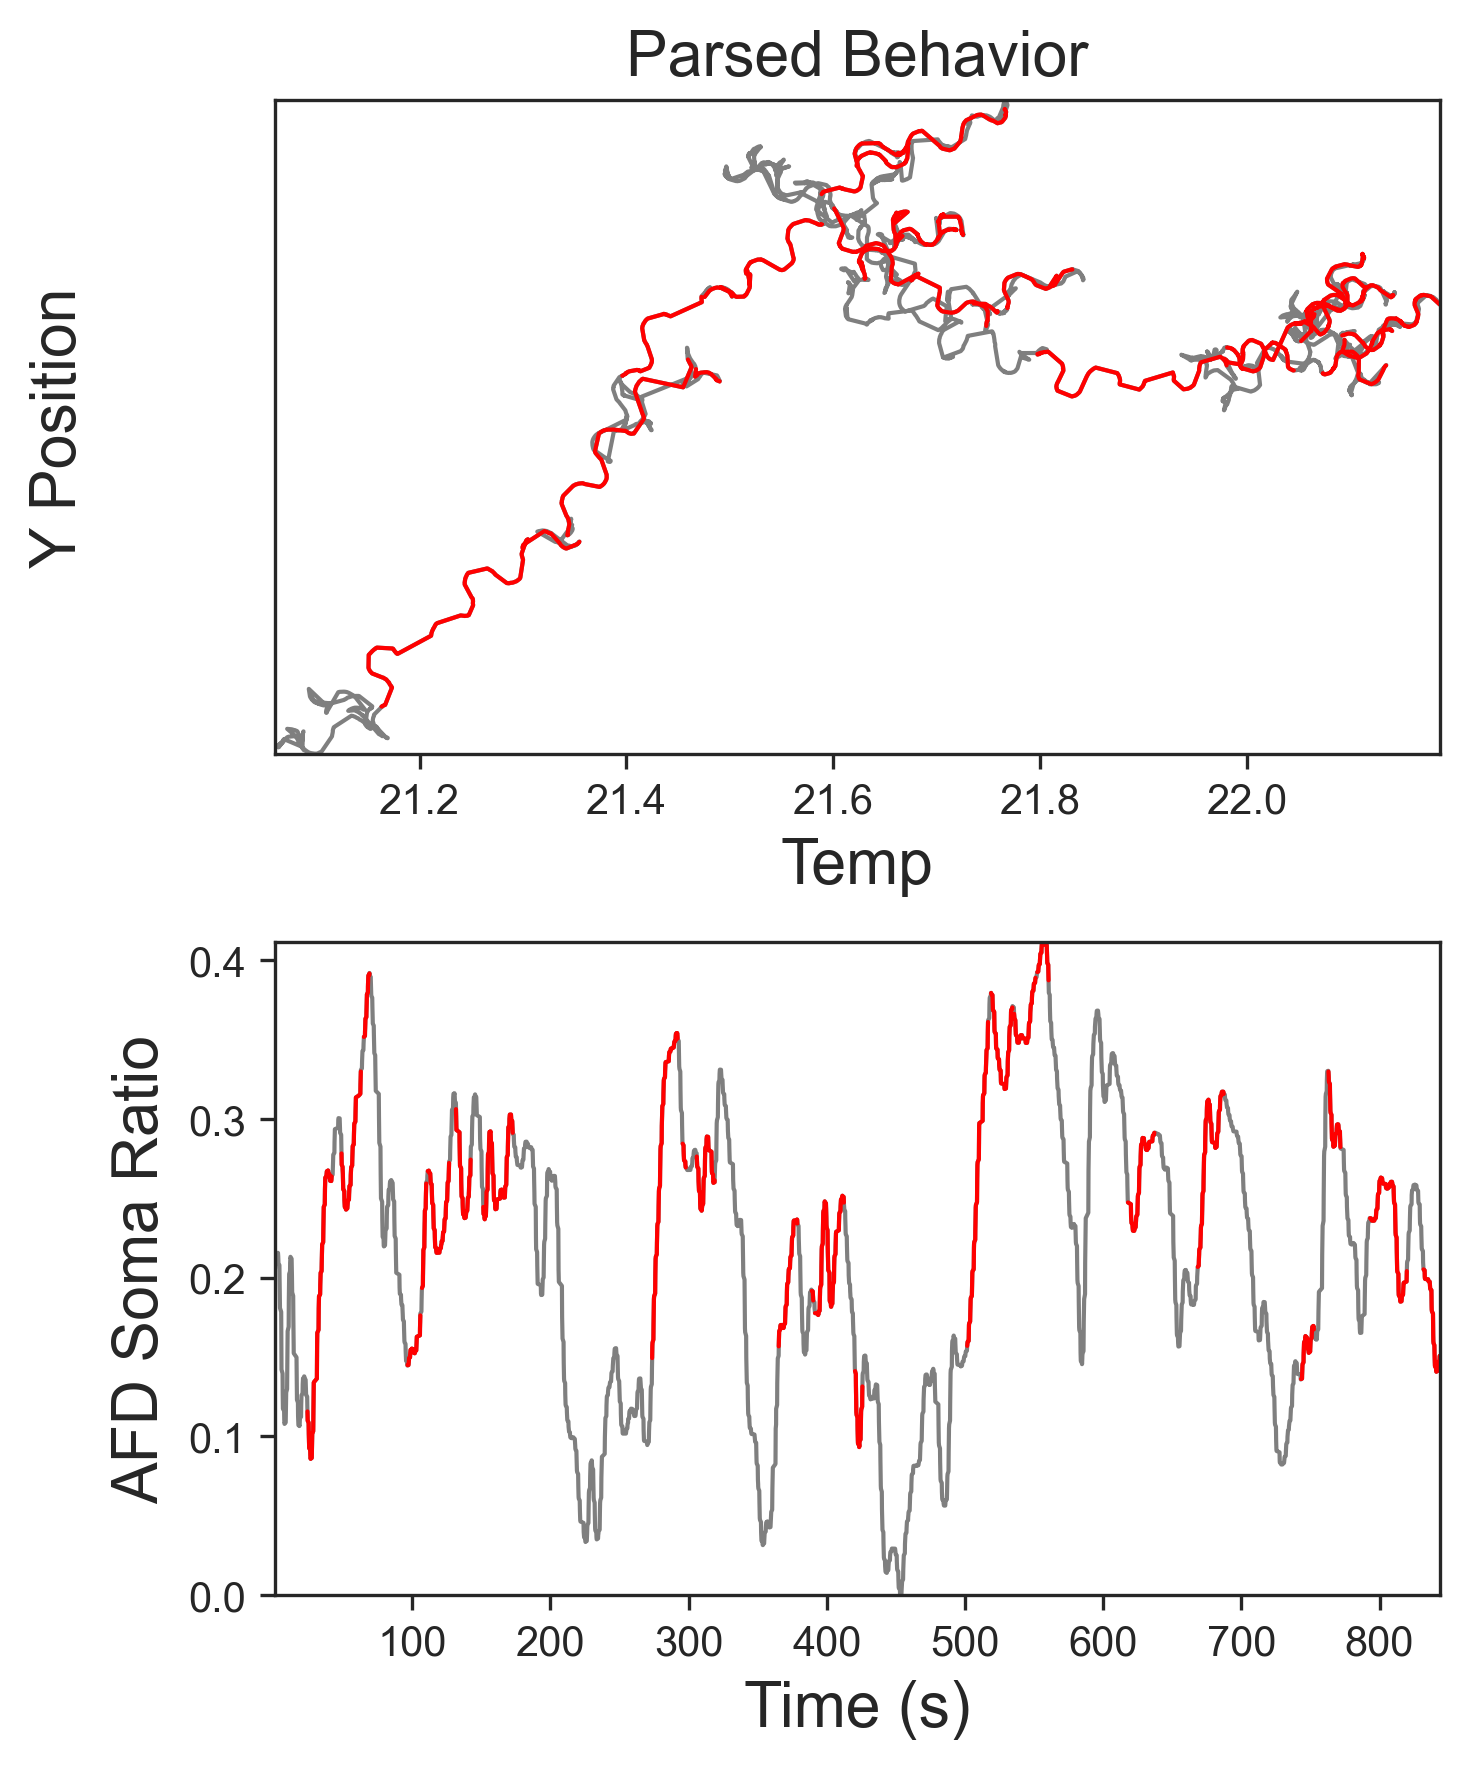

In [19]:
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6), dpi=300)
ax1 = plt.subplot(2,1,1)

plt.title('Parsed Behavior', fontsize=15)
ax2 = plt.subplot(2,1,2)

ax1.plot(Temp_steep_3_4_20, Ycoord_steep_3_4_20, c='k', lw=1, alpha=0.5)
ax2.plot(Time_steep_3_4_20, DeltaR_steep_3_4_20, c='k', lw=1, alpha=0.5)
    
for i in run_east_video_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax1.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='r', lw=1)
    ax2.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='r', lw=1)

ax1.tick_params(axis='y', colors='white')
ax1.tick_params(axis='x', labelsize=10)
ax1.set_xlim(xmin=min(Temp_steep_3_4_20),xmax=max(Temp_steep_3_4_20))
ax1.set_ylim(ymin=min(Ycoord_steep_3_4_20),ymax=max(Ycoord_steep_3_4_20))
ax1.set_ylabel('Y Position', fontsize=15)
ax1.set_xlabel('Temp', fontsize=15)
    
ax2.tick_params(axis = 'both', labelsize=10)
ax2.set_xlim(xmin=min(Time_steep_3_4_20),xmax=max(Time_steep_3_4_20))
ax2.set_ylim(ymin=min(DeltaR_steep_3_4_20),ymax=max(DeltaR_steep_3_4_20))
ax2.set_ylabel('AFD Soma Ratio', fontsize=15)
ax2.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout() 
#plt.savefig('C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/FreelyMoving_Behavior_Strats_Labeling/3_4_20_PosRuns.svg', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

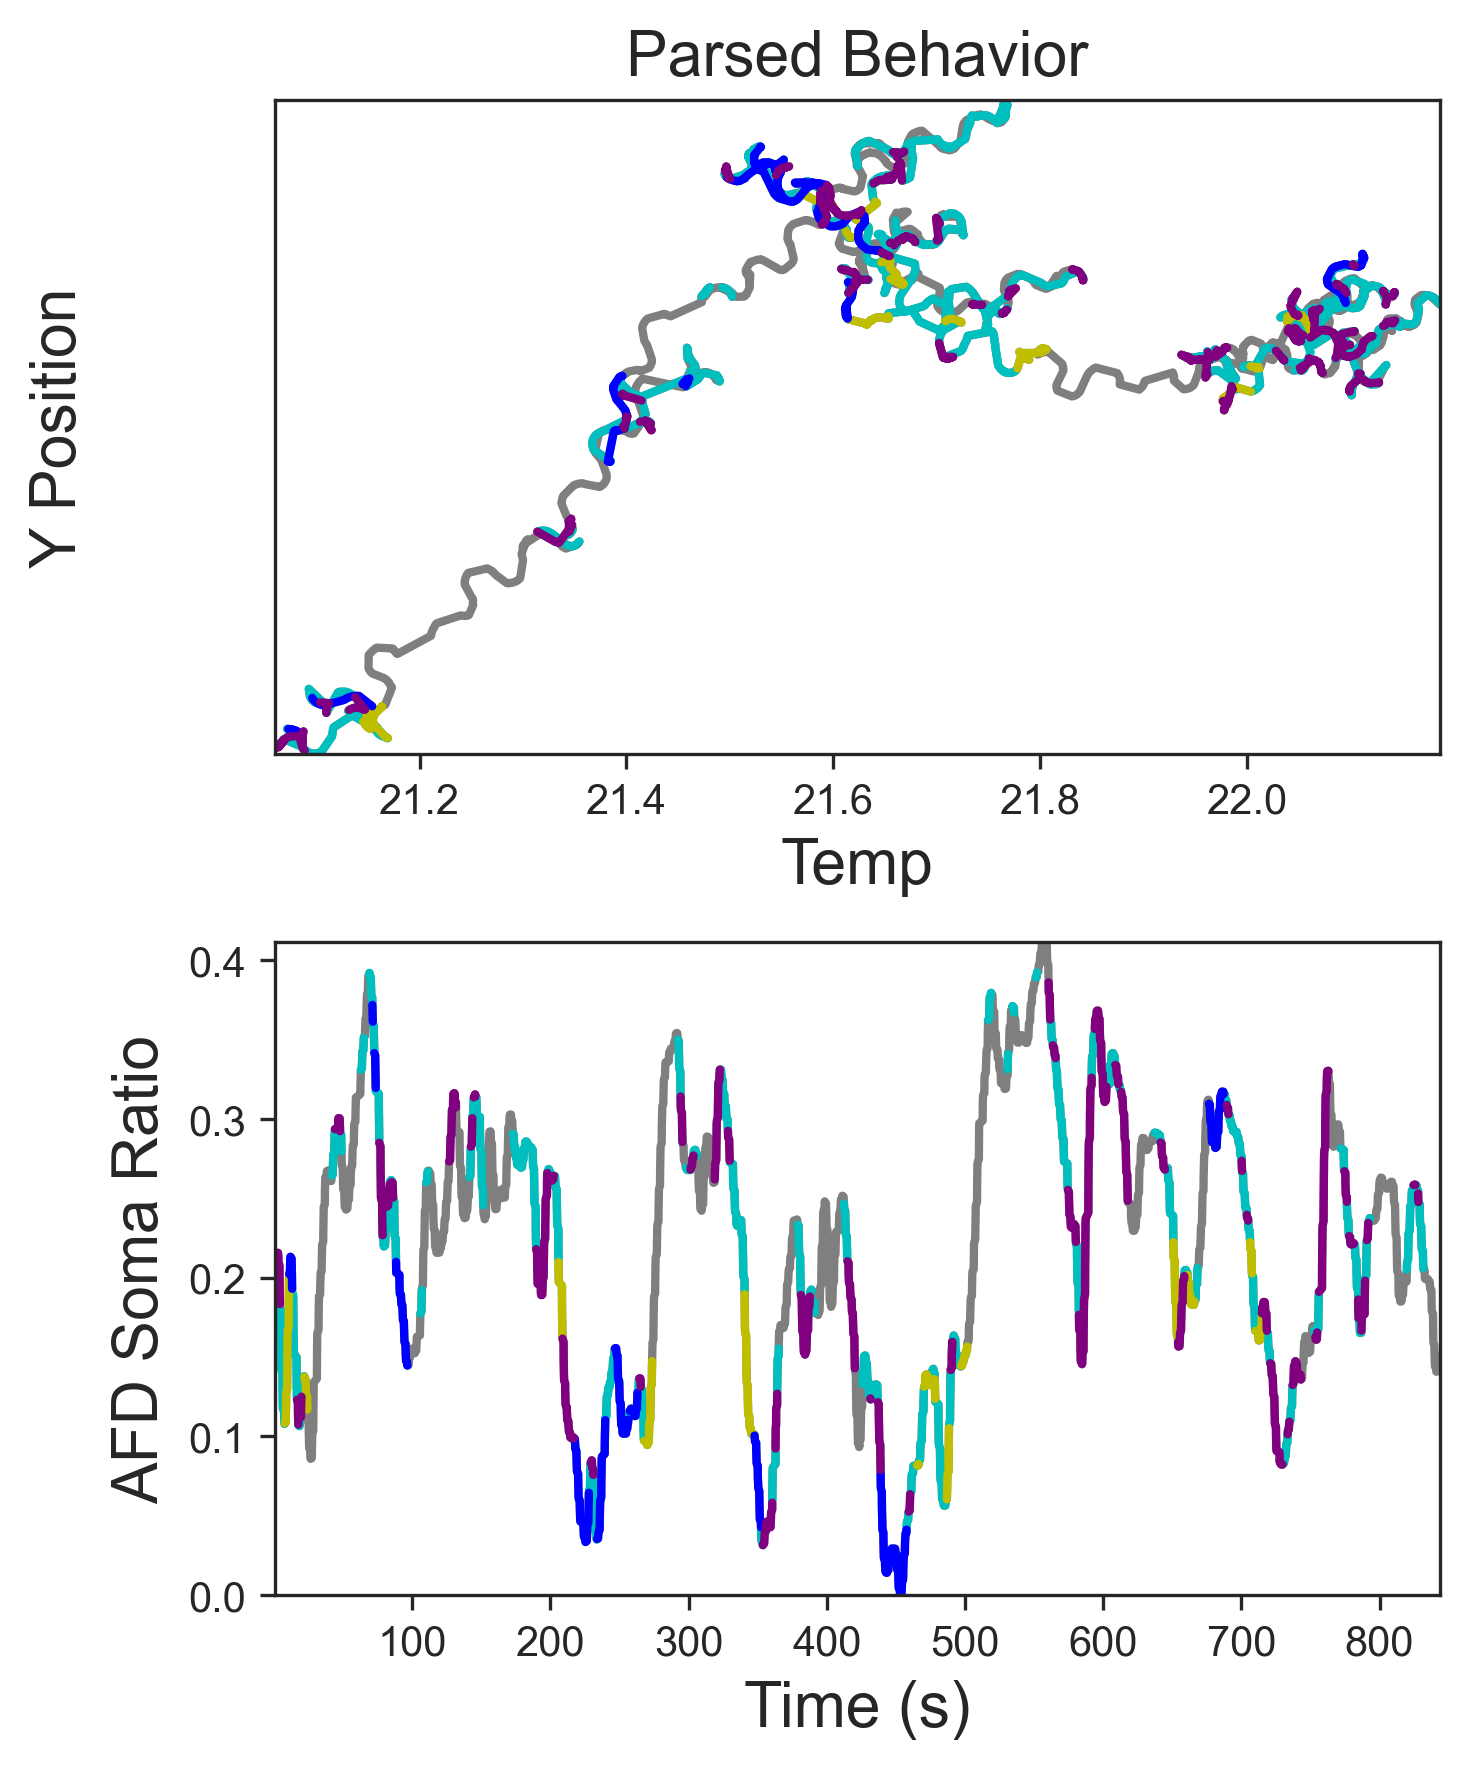

In [20]:

plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6), dpi=300)
ax1 = plt.subplot(2,1,1)

plt.title('Parsed Behavior', fontsize=15)
ax2 = plt.subplot(2,1,2)

ax1.plot(Temp_steep_3_4_20, Ycoord_steep_3_4_20, c='k', lw=2, alpha=0.5)
ax2.plot(Time_steep_3_4_20, DeltaR_steep_3_4_20, c='k', lw=2, alpha=0.5)

for i in reversals_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax1.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='c', lw=2)
    ax2.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='c', lw=2)
    
for i in omega_turns_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax1.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='y', lw=2)
    ax2.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='y', lw=2)
    
#for i in run_east_video_steep_3_4_20:
#    start, stop = find_start_stop(i, Frames_steep_3_4_20)
#    ax1.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='r', lw=2)
#    ax2.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='r', lw=2)
    
for i in run_not_e_video_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax1.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='b', lw=2)
    ax2.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='b', lw=2)
    
for i in pause_explore_bend_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax1.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='purple', lw=2)
    ax2.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='purple', lw=2)

ax1.tick_params(axis='y', colors='white')
ax1.tick_params(axis='x', labelsize=10)
ax1.set_xlim(xmin=min(Temp_steep_3_4_20),xmax=max(Temp_steep_3_4_20))
ax1.set_ylim(ymin=min(Ycoord_steep_3_4_20),ymax=max(Ycoord_steep_3_4_20))
ax1.set_ylabel('Y Position', fontsize=15)
ax1.set_xlabel('Temp', fontsize=15)
    
ax2.tick_params(axis = 'both', labelsize=10)
ax2.set_xlim(xmin=min(Time_steep_3_4_20),xmax=max(Time_steep_3_4_20))
ax2.set_ylim(ymin=min(DeltaR_steep_3_4_20),ymax=max(DeltaR_steep_3_4_20))
ax2.set_ylabel('AFD Soma Ratio', fontsize=15)
ax2.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout() 
#plt.savefig('3_4_20_NonPosRuns.svg', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

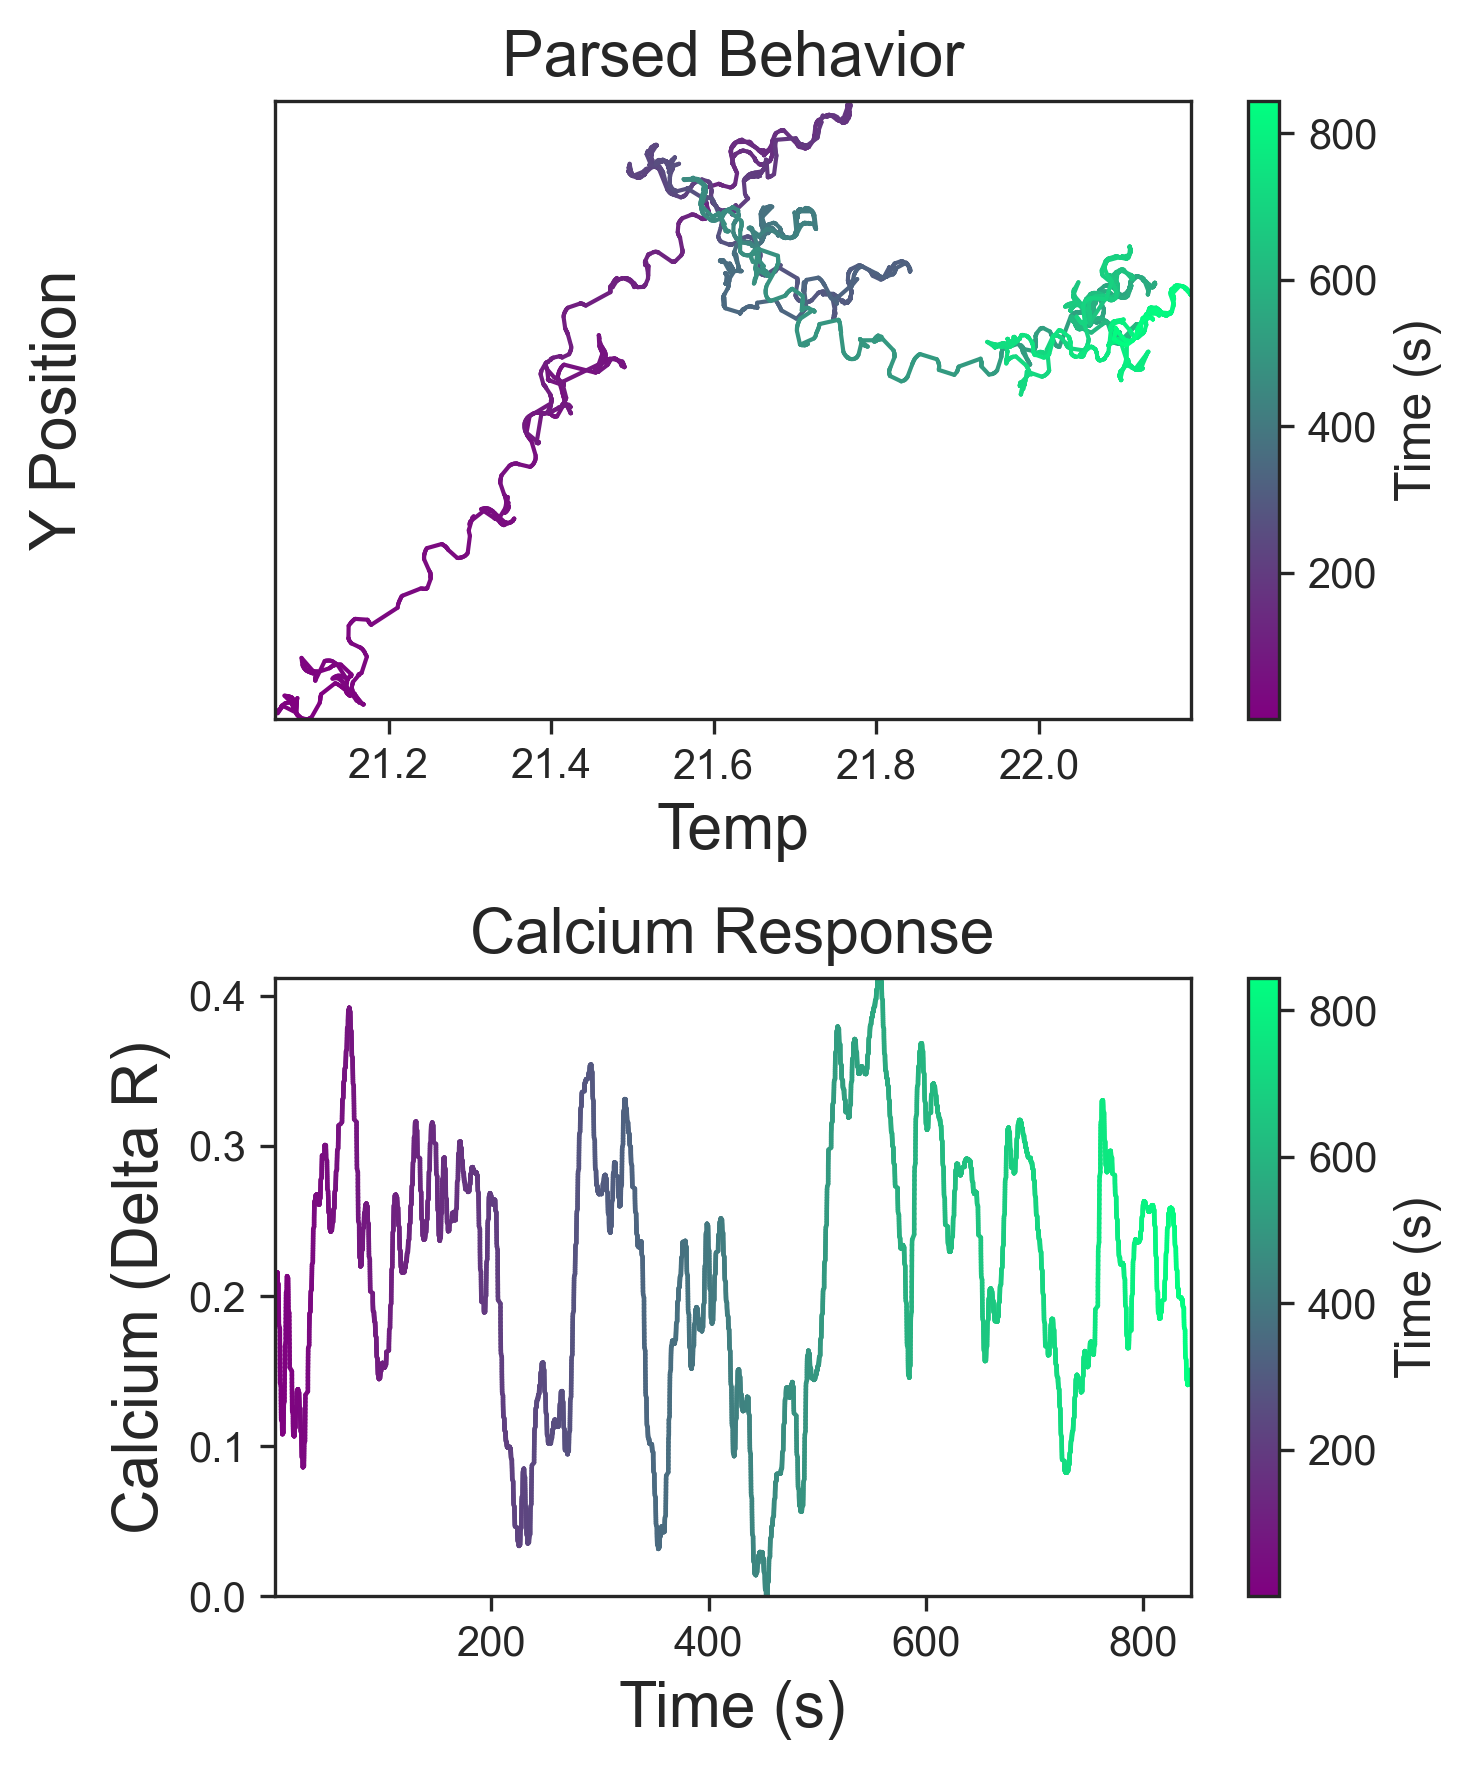

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.cm as cm

Time_sorted = np.array(Time_steep_3_4_20)
DeltaR = np.array(DeltaR_steep_3_4_20)

# Normalize time values to range [0, 1] for the color mapping
norm = Normalize(np.min(Time_sorted), np.max(Time_sorted))

# Create custom colormap
purple_to_green_cmap = LinearSegmentedColormap.from_list('PurpleToWinterGreen', ['purple', cm.get_cmap('winter')(1.0)])
plt.register_cmap(cmap=purple_to_green_cmap)
cmap = plt.get_cmap('PurpleToWinterGreen')

# --- Plotting Setup ---
# Create 2 subplots (ax1 = Top, ax2 = Bottom)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 6), dpi=300)

# ==========================================
# PLOT 1: Behavior (Temp vs Y Position)
# ==========================================
points_beh = np.array([Temp_steep_3_4_20, Ycoord_steep_3_4_20]).T.reshape(-1, 1, 2)
segments_beh = np.concatenate([points_beh[:-1], points_beh[1:]], axis=1)

# Create LineCollection
lc1 = LineCollection(segments_beh, cmap=cmap, norm=norm)
lc1.set_array(Time_sorted[:-1])
lc1.set_linewidth(1)
lc1.set_capstyle('round')
lc1.set_joinstyle('round')

ax1.add_collection(lc1)
ax1.set_title('Parsed Behavior', fontsize=15)
ax1.set_xlim(np.min(Temp_steep_3_4_20), np.max(Temp_steep_3_4_20))
ax1.set_ylim(np.min(Ycoord_steep_3_4_20), np.max(Ycoord_steep_3_4_20))
ax1.set_xlabel('Temp', fontsize=15)
ax1.set_ylabel('Y Position', fontsize=15)
ax1.tick_params(axis='y', colors='white') 

# Add colorbar to top plot
cbar1 = fig.colorbar(lc1, ax=ax1)
cbar1.set_label('Time (s)', fontsize=12)

# ==========================================
# PLOT 2: Calcium (Time vs DeltaR)
# ==========================================
points_ca = np.array([Time_sorted, DeltaR]).T.reshape(-1, 1, 2)
segments_ca = np.concatenate([points_ca[:-1], points_ca[1:]], axis=1)

# Create LineCollection (Reusing same cmap and norm)
lc2 = LineCollection(segments_ca, cmap=cmap, norm=norm)
lc2.set_array(Time_sorted[:-1])
lc2.set_linewidth(1.1)

lc2.set_capstyle('round')
lc2.set_joinstyle('round')

ax2.add_collection(lc2)
ax2.set_title('Calcium Response', fontsize=15)
ax2.set_xlim(np.min(Time_sorted), np.max(Time_sorted))
y_range = np.max(DeltaR) - np.min(DeltaR)
# optional: ax2.set_ylim(np.min(DeltaR) - 0.1*y_range, np.max(DeltaR) + 0.01*y_range)
ax2.set_ylim(ymin=min(DeltaR),ymax=max(DeltaR))
ax2.set_xlabel('Time (s)', fontsize=15)
ax2.set_ylabel('Calcium (Delta R)', fontsize=15)

# Add colorbar to bottom plot 
cbar2 = fig.colorbar(lc2, ax=ax2)
cbar2.set_label('Time (s)', fontsize=12)

plt.tight_layout()
#plt.savefig('C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/FreelyMoving_Behavior_Strats_Labeling/3_4_20_TimeHeatMap.svg', dpi=600, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

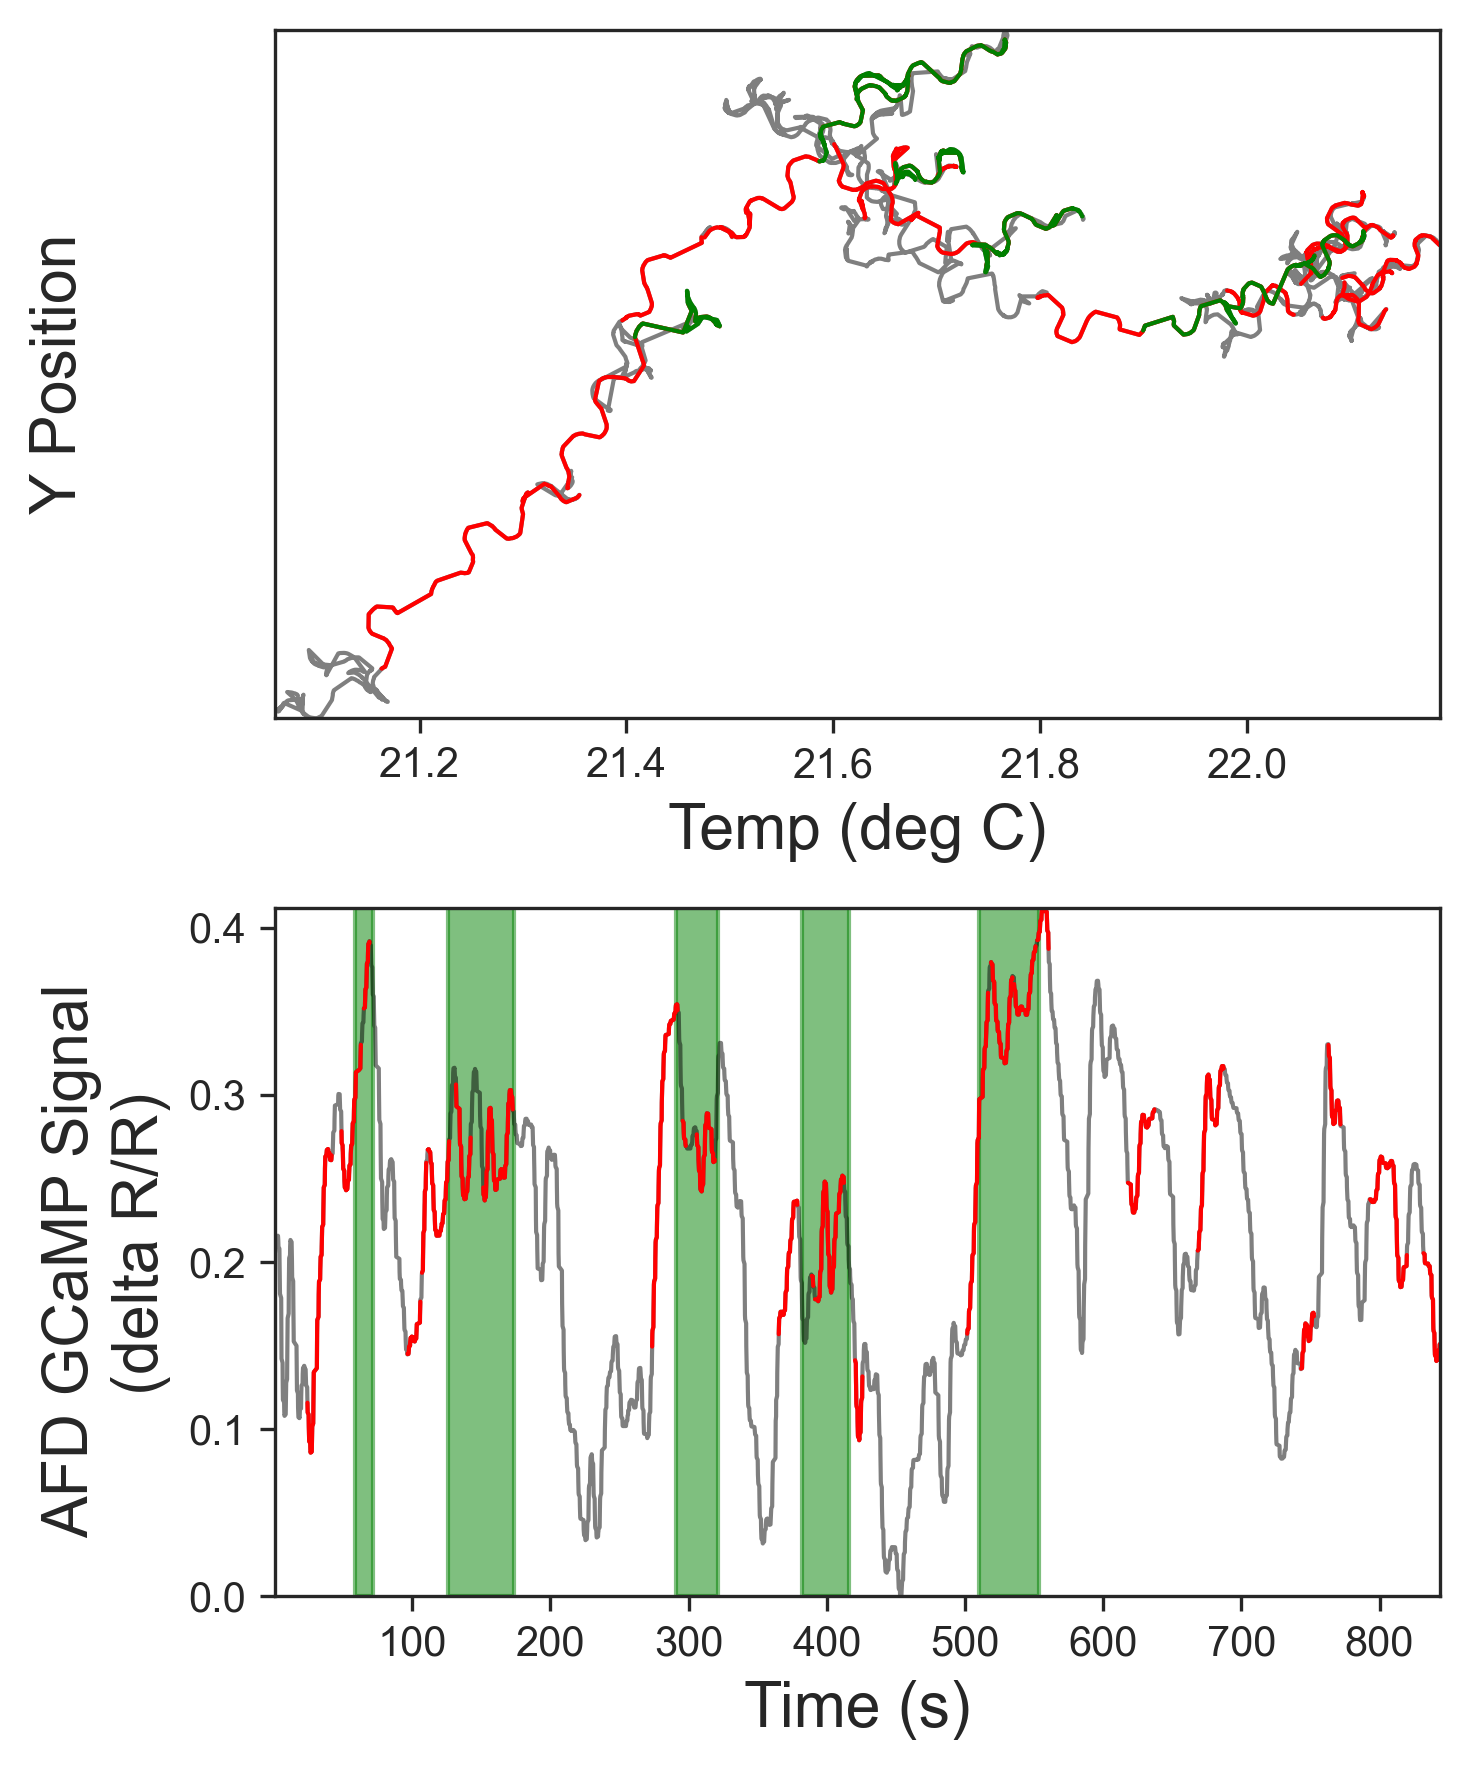

In [22]:
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6),dpi=300)
ax2 = plt.subplot(2,1,1)

ax1 = plt.subplot(2,1,2) ##
#plt.title('Visually Called Plateaus', fontsize=15)

ax2.plot(Temp_steep_3_4_20, Ycoord_steep_3_4_20, c='k', lw=1, alpha=0.5)
ax1.plot(Time_steep_3_4_20, DeltaR_steep_3_4_20, c='k', lw=1, alpha=0.5)

for i in run_east_video_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax2.plot(Temp_steep_3_4_20[start:stop], Ycoord_steep_3_4_20[start:stop], c='r', lw=1)
    ax1.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='r', lw=1)
for i in plateaus_steep_3_4_20:
    ax2.plot(Temp_steep_3_4_20[i[0]:i[1]],Ycoord_steep_3_4_20[i[0]:i[1]],c='g', lw=1)
    
ax2.tick_params(axis='y', colors='white')
ax2.tick_params(axis='x', labelsize=10)
ax2.set_xlim(xmin=min(Temp_steep_3_4_20),xmax=max(Temp_steep_3_4_20))
ax2.set_ylim(ymin=min(Ycoord_steep_3_4_20),ymax=max(Ycoord_steep_3_4_20))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp (deg C)', fontsize=15)
    
for i in plateaus_steep_3_4_20:
    ax1.axvspan(Time_steep_3_4_20[i[0]],Time_steep_3_4_20[i[1]],alpha=0.5,color='green')
    
ax1.tick_params(axis = 'both', labelsize=10)
ax1.set_xlim(xmin=min(Time_steep_3_4_20),xmax=max(Time_steep_3_4_20))
ax1.set_ylim(ymin=min(DeltaR_steep_3_4_20),ymax=max(DeltaR_steep_3_4_20))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=15)
ax1.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout()
#plt.savefig('3_4_20_PosRuns_wPlateaus.svg', dpi=600, bbox_inches='tight')
#plt.savefig('xxx.png', dpi=600, bbox_inches='tight')
#plt.savefig('xxx.svg', dpi=600, bbox_inches='tight')

plt.show()

<Figure size 640x480 with 0 Axes>

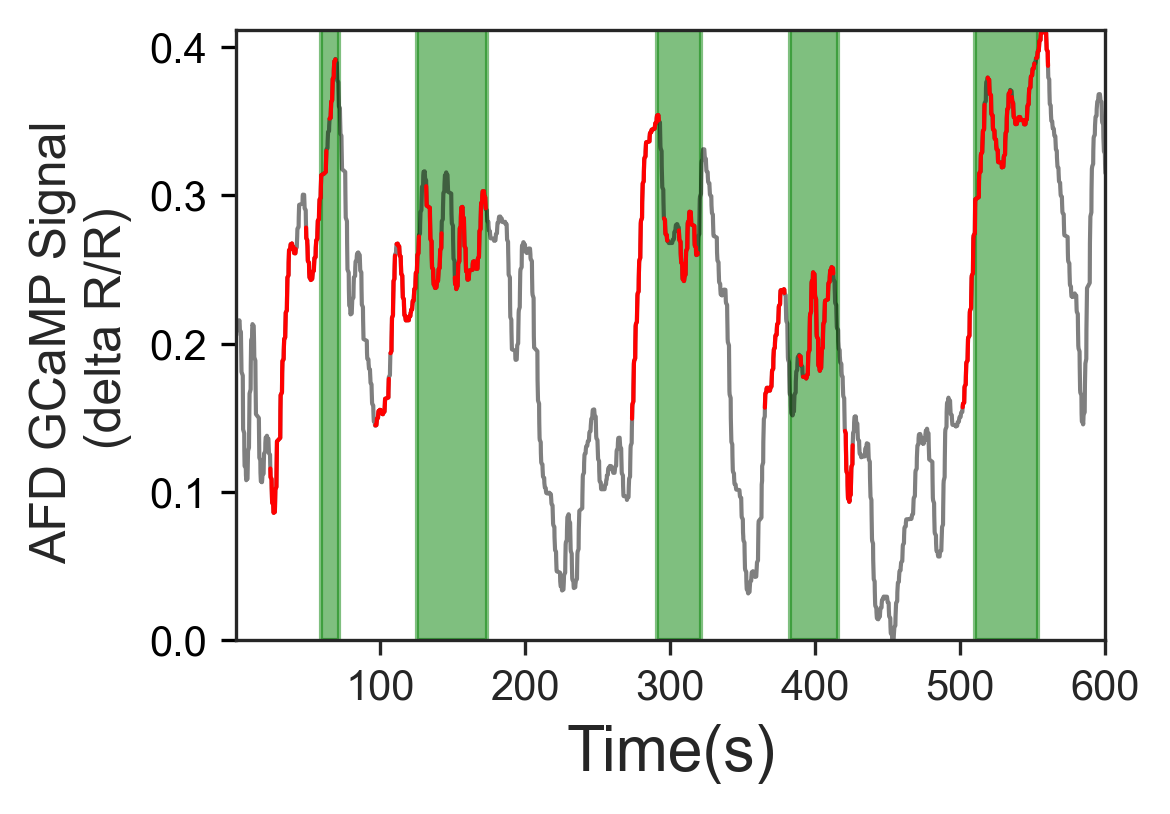

In [23]:
plt.clf()

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(4,5), dpi=300)
ax1 = plt.subplot(2,1,1)

ax1.plot(Time_steep_3_4_20, DeltaR_steep_3_4_20, c='k', lw=1, alpha=0.5)

for i in run_east_video_steep_3_4_20:
    start, stop = find_start_stop(i, Frames_steep_3_4_20)
    ax1.plot(Time_steep_3_4_20[start:stop], DeltaR_steep_3_4_20[start:stop], c='r', lw=1)

for i in plateaus_steep_3_4_20:
    ax1.axvspan(Time_steep_3_4_20[i[0]],Time_steep_3_4_20[i[1]],alpha=0.5,color='green')
    
    
ax1.set_xlim(xmin=min(Time_steep_3_4_20),xmax=max(Time_steep_3_4_20))
ax1.set_xlim(xmin=min(Time_steep_3_4_20), xmax=next((t for t in Time_steep_3_4_20 if t >= 600), None) )
ax1.set_ylim(ymin=min(DeltaR_steep_3_4_20),ymax=max(DeltaR_steep_3_4_20))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=12)
ax1.set_xlabel('Time(s)', fontsize=15)

ax1.tick_params(axis='y', colors='black', labelsize=10)
ax1.tick_params(axis='x', labelsize=10)

plt.tight_layout()
#plt.savefig('3_4_20_CaPlateaus.svg', dpi=600, bbox_inches='tight')
plt.show()

## 3_5_20

In [24]:
reversals_steep_3_5_20 = [
    (240,255),(560,575),(625,645),(835,865),(1385,1400),(1695,1760),(1905,1940),(2180,2200),(2240,2255),(2285,2295),(2835,2870),
    (2880,2900),(3085,3135),(3180,3255),(3295,3315),(3390,3435),(3630,3650),(3720,3740),(3795,3820),(4000,4050),(4110,4125),(4140,4155),
    (4215,4245),(4275,4335),(4395,4425),(4455,4500),(4520,4560),(4880,4905),(5505,5525),(5630,5640),(5700,5715),(5770,5790),(6030,6055),
    (6420,6435),(7800,7815),(7850,7870),(7905,7950),(8040,8070),(8280,8315),(8365,8390),(8975,9035),(9065,9090),(9100,9120),(9180,9195),
    (9420,9435),(9705,9780),(9910,9940),(9960,9975),(10045,10170),(10480,10490),(10605,10630),(10845,10885),(11075,11090),(13110,13140),
    (13385,13410),(13430,13465),(14280,14295),(14700,14730),(14830,14840)
]

omega_turns_steep_3_5_20 = [
    (3315,3335),(3435,3615),(4335,4355),(4425,4455),(4560,4695),(8070,8100),(9120,9150),(9780,9830),(13465,13520),
]

run_east_video_steep_3_5_20 = [
    (590,625),(645,835),(865,1275),(1295,1385),(1400,1695),(1760,1905),(1940,2100),(2120,2180),(2500,2835),(2870,2880),(2900,2990),(3050,3085),
    (3135,3180),(3615,3630),(6315,6420),(6435,6915),(7240,7800),(9225,9420),(9435,9705),(10730,10845),(12375,12890),(12915,13110),(13140,13385),
    (13800,14240),(14515,14700),(14895,14985)
]

run_not_e_video_steep_3_5_20 = [
    (1,25),(90,200),(225,240),(255,560),(2255,2285),(2295,2330), (2345,2380), (2390,2490),(3255,3295),(3335,3390),(3670,3720),(3770,3795),(3820,3905),(3925,4000),
    (4050,4110),(4170,4215),(4355,4395),(4765,4880),(5000,5235),(5370,5505),(5525,5630),(5640,5700),(5715,5770),(5790,5930),(5940,6030),(6055,6300),
    (6915,6950),(6950,7230),(7230,7240),(7870,7905),(8165,8280),(8315,8365),(8390,8780),(8800,8975),(9150,9180),(9830,9910),(9975,9990),(9990,10045),
    (10210,10480),(10490,10605),(10630,10675),(10885,11075),(11090,11075),(11090,11300),(11300,11335),(11335,11370),(11400,11440),(11460,11590),
    (11600,11775),(11775,11830),(11830,12335),(12335,12375),(13520,13770),(13770,13800),(14260,14280),(14335,14505),(14730,14830),(14840,14895)
]

pause_explore_bend_steep_3_5_20 = [
    (25,90),(200,225),(575,590),(1275,1295),(2100,2120),(2200,2240),(2330,2345),(2389,2390),(2490,2500),(2990,3050),(3650,3670),(3740,3770),
    (3905,3925),(4125,4140),(4155,4170),(4245,4275),(4500,4520),(4695,4765),(4905,5000),(5235,5275),(5275,5305),(5305,5370),(5930,5940),
    (6300,6315),(7815,7850),(7950,8040),(8100,8165),(9035,9065),(9090,9100),(9195,9225),(9940,9960),(10170,10210),(10675,10730),
    (11370,11400),(11440,11460),(11590,11600),(12890,12915),(13410,13430),(14240,14260),(14295,14335),(14505,14515)
]

plateaus_steep_3_5_20 = [(1375,2200),(7450,7810),(9500,10000),(12800,13320), (13800,14200)
                         ]

In [25]:
source = "csv"
if source == "csv":
    # Load the CSV file
    pref = "Freely_Moving_Coordinates/"
    file_path = pref + "Steep_5p5_3_5_20_1_data.csv"  
    df = pd.read_csv(file_path)

    # Store each column in its own list
    Ycoord_steep_3_5_20       = df['y'].tolist()
    Xcoord_steep_3_5_20       = df['x'].tolist()
    Temp_steep_3_5_20    = df['Temp'].tolist()
    Time_steep_3_5_20    = df['Time'].tolist()
    Frames_steep_3_5_20  = df['frames'].tolist()
    DeltaR_steep_3_5_20 = df['Delta_R'].tolist()

<Figure size 640x480 with 0 Axes>

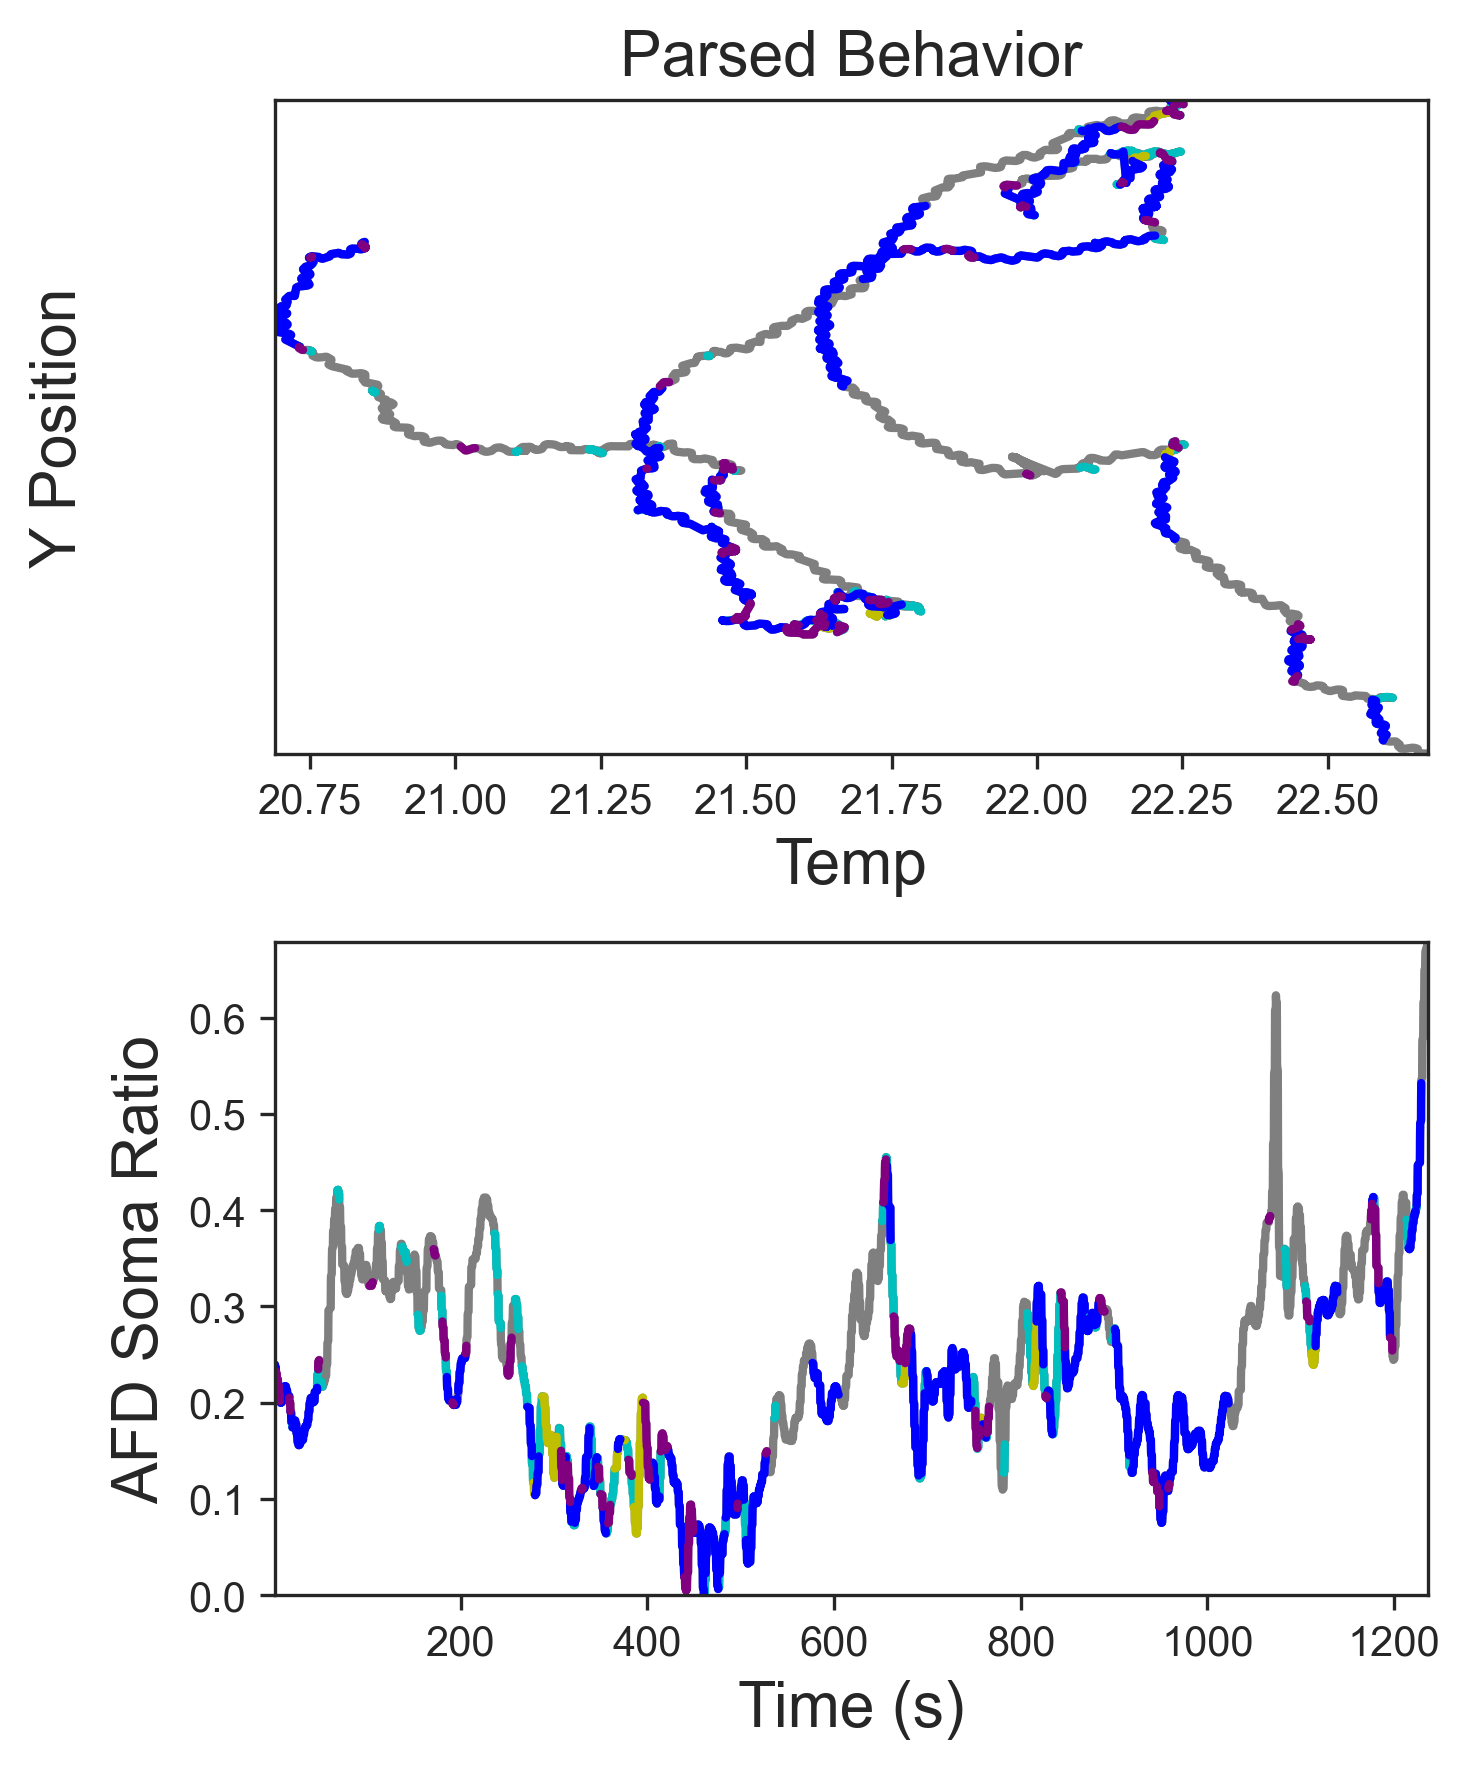

In [26]:
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6), dpi=300)
ax1 = plt.subplot(2,1,1)

plt.title('Parsed Behavior', fontsize=15)
ax2 = plt.subplot(2,1,2)

ax1.plot(Temp_steep_3_5_20, Ycoord_steep_3_5_20, c='k', lw=2, alpha=0.5)
ax2.plot(Time_steep_3_5_20, DeltaR_steep_3_5_20, c='k', lw=2, alpha=0.5)

for i in reversals_steep_3_5_20:
    start, stop = find_start_stop(i, Frames_steep_3_5_20)
    ax1.plot(Temp_steep_3_5_20[start:stop], Ycoord_steep_3_5_20[start:stop], c='c', lw=2)
    ax2.plot(Time_steep_3_5_20[start:stop], DeltaR_steep_3_5_20[start:stop], c='c', lw=2)
    
for i in omega_turns_steep_3_5_20:
    start, stop = find_start_stop(i, Frames_steep_3_5_20)
    ax1.plot(Temp_steep_3_5_20[start:stop], Ycoord_steep_3_5_20[start:stop], c='y', lw=2)
    ax2.plot(Time_steep_3_5_20[start:stop], DeltaR_steep_3_5_20[start:stop], c='y', lw=2)
    
for i in run_not_e_video_steep_3_5_20:
    start, stop = find_start_stop(i, Frames_steep_3_5_20)
    ax1.plot(Temp_steep_3_5_20[start:stop], Ycoord_steep_3_5_20[start:stop], c='b', lw=2)
    ax2.plot(Time_steep_3_5_20[start:stop], DeltaR_steep_3_5_20[start:stop], c='b', lw=2)
    
for i in pause_explore_bend_steep_3_5_20:
    start, stop = find_start_stop(i, Frames_steep_3_5_20)
    ax1.plot(Temp_steep_3_5_20[start:stop], Ycoord_steep_3_5_20[start:stop], c='purple', lw=2)
    ax2.plot(Time_steep_3_5_20[start:stop], DeltaR_steep_3_5_20[start:stop], c='purple', lw=2)

ax1.tick_params(axis='y', colors='white')
ax1.tick_params(axis='x', labelsize=10)
ax1.set_xlim(xmin=min(Temp_steep_3_5_20),xmax=max(Temp_steep_3_5_20))
ax1.set_ylim(ymin=min(Ycoord_steep_3_5_20),ymax=max(Ycoord_steep_3_5_20))
ax1.set_ylabel('Y Position', fontsize=15)
ax1.set_xlabel('Temp', fontsize=15)
    
ax2.tick_params(axis = 'both', labelsize=10)
ax2.set_xlim(xmin=min(Time_steep_3_5_20),xmax=max(Time_steep_3_5_20))
ax2.set_ylim(ymin=min(DeltaR_steep_3_5_20),ymax=max(DeltaR_steep_3_5_20))
ax2.set_ylabel('AFD Soma Ratio', fontsize=15)
ax2.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout()
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

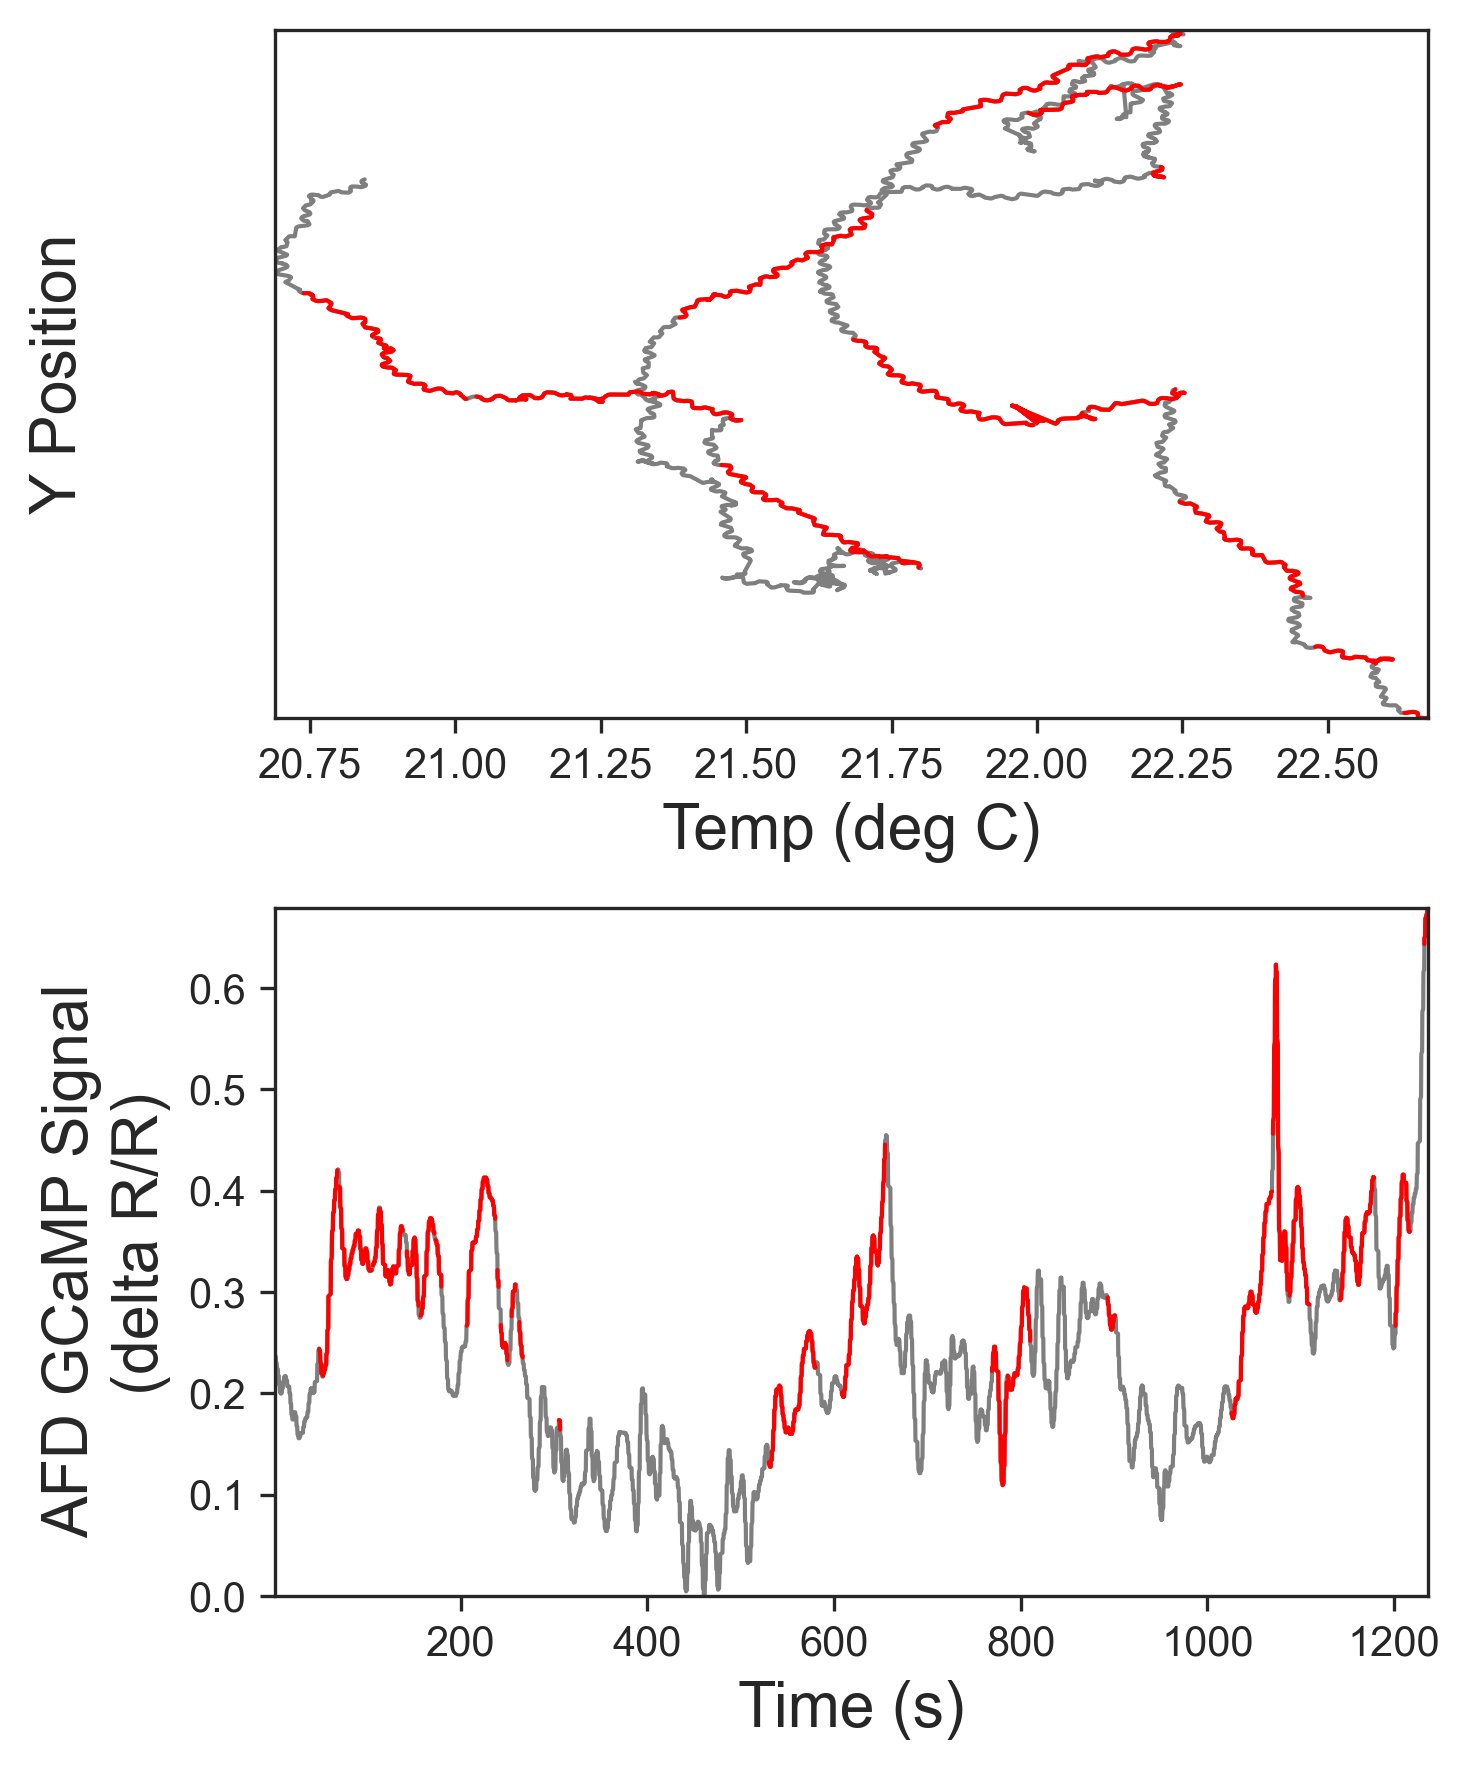

In [27]:


plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6),dpi=300)
ax2 = plt.subplot(2,1,1)

ax1 = plt.subplot(2,1,2) ##
#plt.title('Visually Called Plateaus', fontsize=15)

ax2.plot(Temp_steep_3_5_20, Ycoord_steep_3_5_20, c='k', lw=1, alpha=0.5)
ax1.plot(Time_steep_3_5_20, DeltaR_steep_3_5_20, c='k', lw=1, alpha=0.5)

for i in run_east_video_steep_3_5_20:
    start, stop = find_start_stop(i, Frames_steep_3_5_20)
    ax2.plot(Temp_steep_3_5_20[i[0]:i[1]], Ycoord_steep_3_5_20[i[0]:i[1]], c='r', lw=1)
    ax1.plot(Time_steep_3_5_20[i[0]:i[1]], DeltaR_steep_3_5_20[i[0]:i[1]], c='r', lw=1)
    
    
ax2.tick_params(axis='y', colors='white')
ax2.tick_params(axis='x', labelsize=10)
ax2.set_xlim(xmin=min(Temp_steep_3_5_20),xmax=max(Temp_steep_3_5_20))
ax2.set_ylim(ymin=min(Ycoord_steep_3_5_20),ymax=max(Ycoord_steep_3_5_20))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp (deg C)', fontsize=15)
  
    
ax1.tick_params(axis = 'both', labelsize=10)
ax1.set_xlim(xmin=min(Time_steep_3_5_20),xmax=max(Time_steep_3_5_20))
ax1.set_ylim(ymin=min(DeltaR_steep_3_5_20),ymax=max(DeltaR_steep_3_5_20))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=15)
ax1.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout()
#plt.savefig('xxx.png', dpi=600, bbox_inches='tight')
#plt.savefig('steep_3_5_20_r1_PosRuns.svg', dpi=600, bbox_inches='tight')

plt.show()


<Figure size 640x480 with 0 Axes>

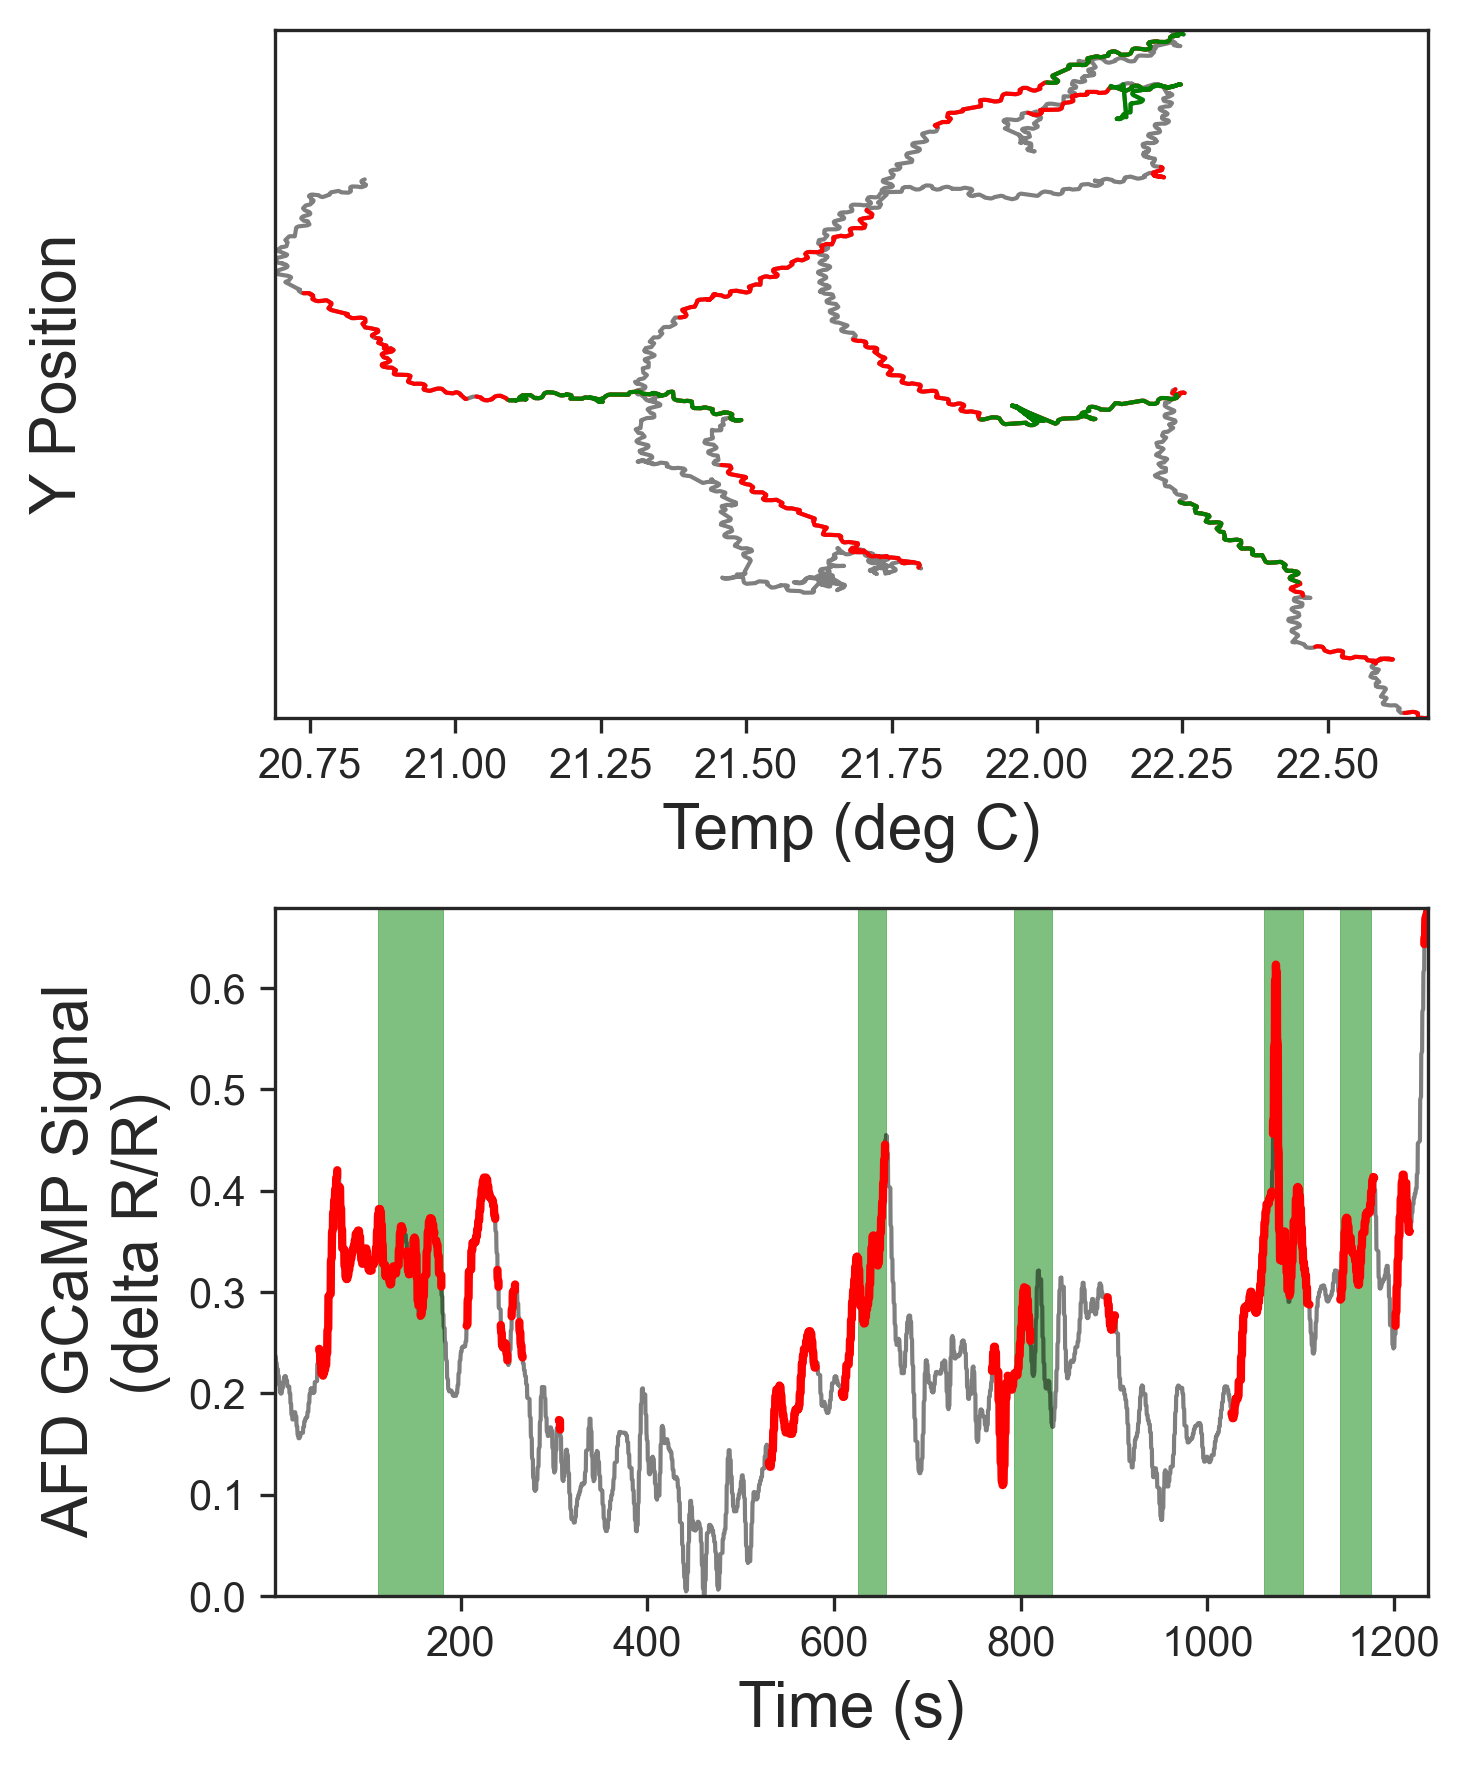

In [28]:


plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6),dpi=300)
ax2 = plt.subplot(2,1,1)

ax1 = plt.subplot(2,1,2) ##
#plt.title('Visually Called Plateaus', fontsize=15)

ax2.plot(Temp_steep_3_5_20, Ycoord_steep_3_5_20, c='k', lw=1, alpha=0.5)
ax1.plot(Time_steep_3_5_20, DeltaR_steep_3_5_20, c='k', lw=1, alpha=0.5)

for i in run_east_video_steep_3_5_20:
    start, stop = find_start_stop(i, Frames_steep_3_5_20)
    ax2.plot(Temp_steep_3_5_20[i[0]:i[1]], Ycoord_steep_3_5_20[i[0]:i[1]], c='r', lw=1)
    ax1.plot(Time_steep_3_5_20[i[0]:i[1]], DeltaR_steep_3_5_20[i[0]:i[1]], c='r', lw=2)
    
for i in plateaus_steep_3_5_20:
    ax2.plot(Temp_steep_3_5_20[i[0]:i[1]],Ycoord_steep_3_5_20[i[0]:i[1]],c='g', lw=1)
    ax1.axvspan(Time_steep_3_5_20[i[0]],Time_steep_3_5_20[i[1]],alpha=0.5,color='green', lw=0.2)
    
ax2.tick_params(axis='y', colors='white')
ax2.tick_params(axis='x', labelsize=10)
ax2.set_xlim(xmin=min(Temp_steep_3_5_20),xmax=max(Temp_steep_3_5_20))
ax2.set_ylim(ymin=min(Ycoord_steep_3_5_20),ymax=max(Ycoord_steep_3_5_20))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp (deg C)', fontsize=15)
  
    
ax1.tick_params(axis = 'both', labelsize=10)
ax1.set_xlim(xmin=min(Time_steep_3_5_20),xmax=max(Time_steep_3_5_20))
ax1.set_ylim(ymin=min(DeltaR_steep_3_5_20),ymax=max(DeltaR_steep_3_5_20))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=15)
ax1.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout()
#plt.savefig('xxx.png', dpi=600, bbox_inches='tight')
#plt.savefig('steep_3_5_20_r1_PosRuns.svg', dpi=600, bbox_inches='tight')

plt.show()


## 2_5_20_2

In [7]:
source = "csv"
if source == "csv":
    # Load the CSV file
    pref = "Freely_Moving_Coordinates/"
    file_path = pref + "Steep_8p2_2_5_20_2_data.csv"  
    df = pd.read_csv(file_path)

    # Store each column in its own list
    Ycoord_steep_2_5_20       = df['y_um_unsmoothed'].tolist()
    Xcoord_steep_2_5_20       = df['x_Normalized_um_unsmoothed'].tolist()
    Temp_steep_2_5_20    = df['Temp_DegC'].tolist()
    Time_steep_2_5_20    = df['Time_s'].tolist()
    Frames_steep_2_5_20  = df['frames'].tolist()
    DeltaR_steep_2_5_20 = df['Delta_R_25smoothed'].tolist()

<Figure size 640x480 with 0 Axes>

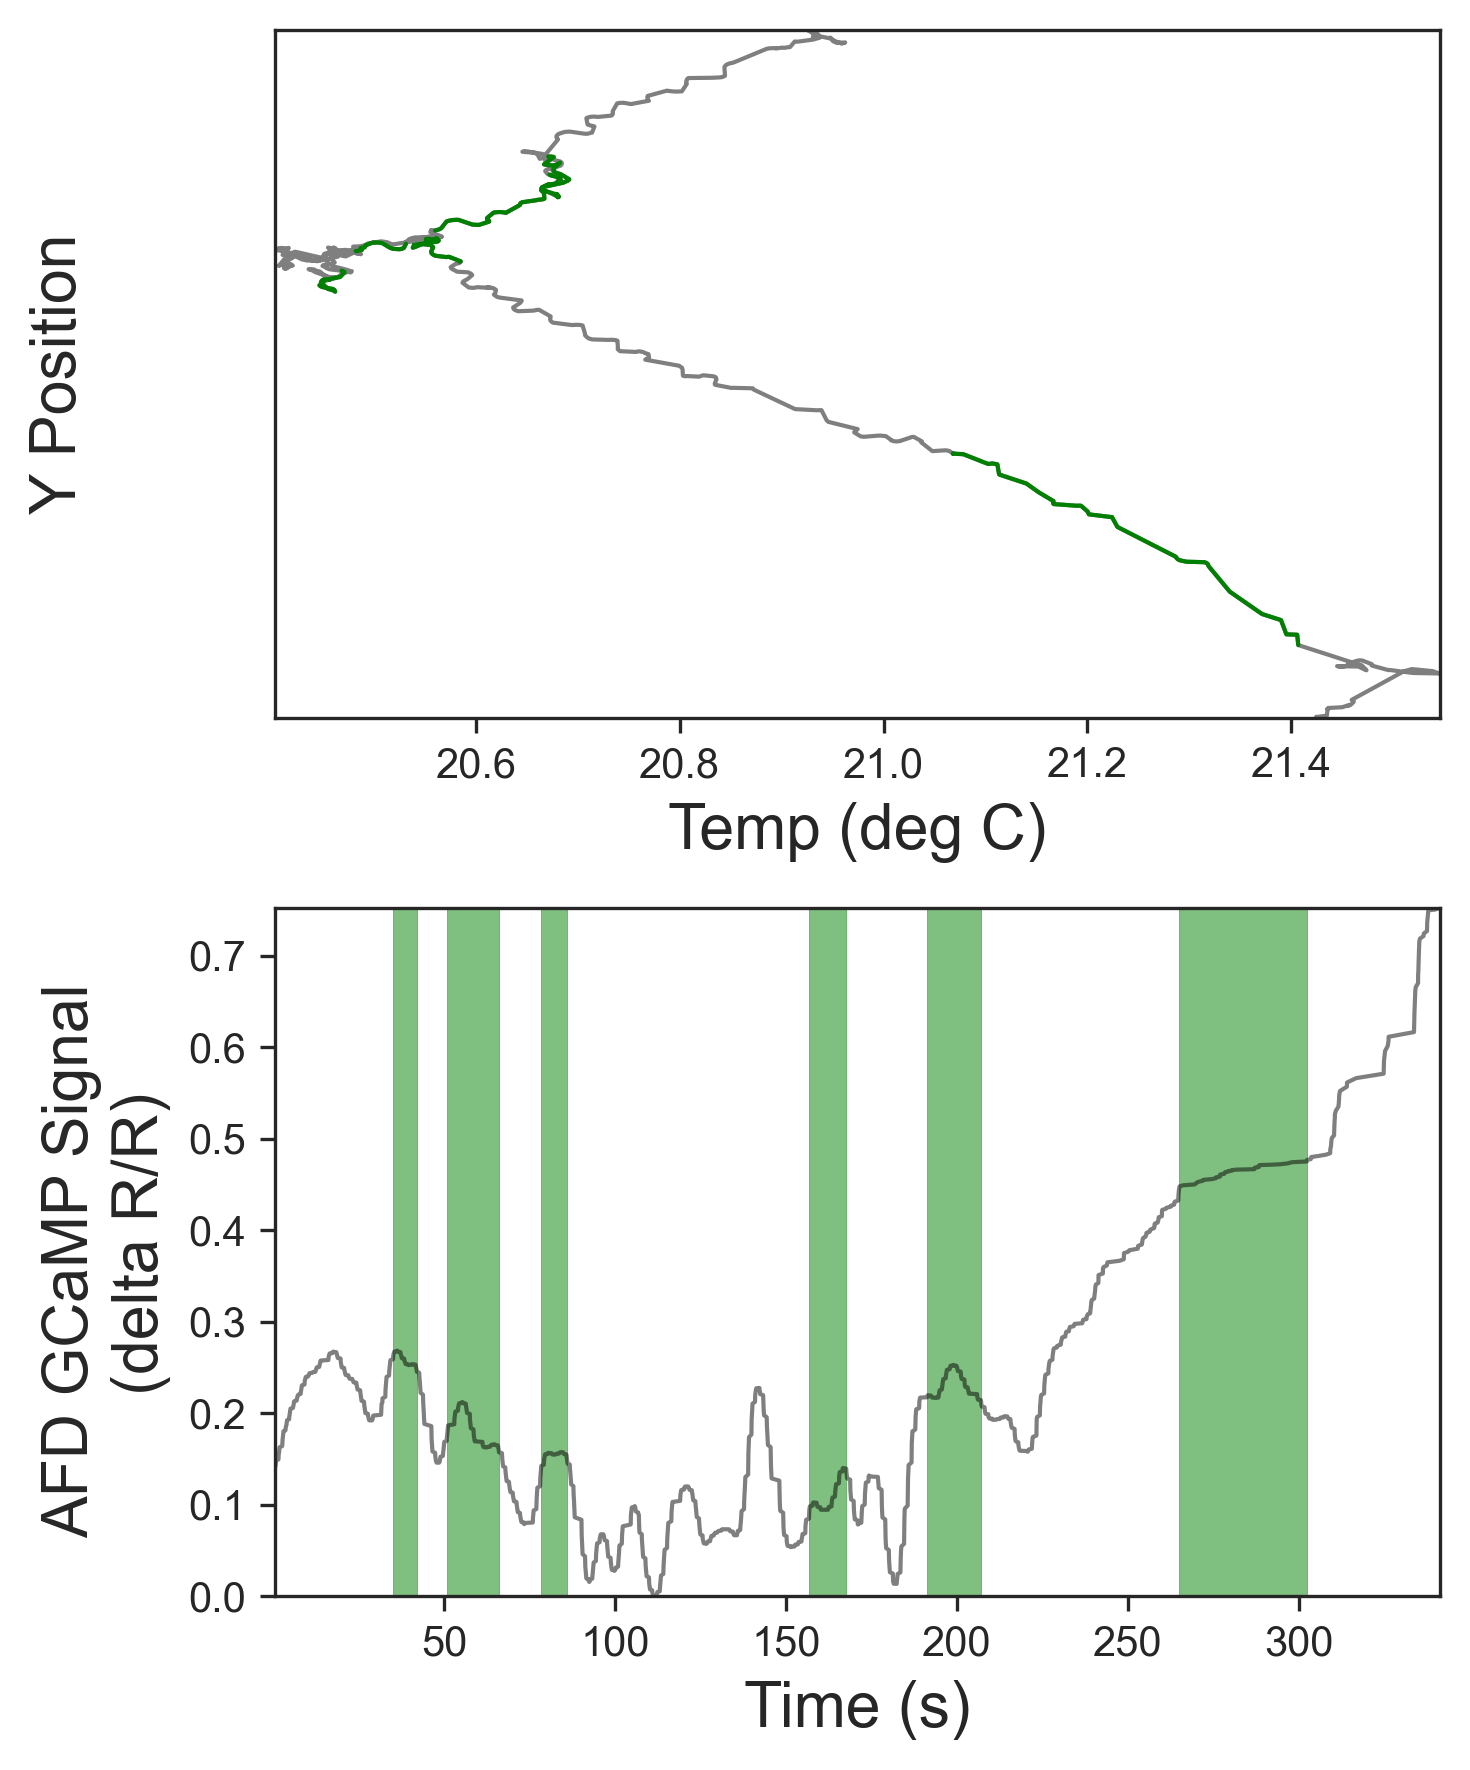

In [8]:
plateaus_steep_2_5_20_5 = [(380,480), (575,750), (900,1000), (1875,2010), (2280,2450) , (2875,2922)
                          #, (3450,3800), (4500,4900), (6000,6500)
                          ]

plateaus_steep_2_5_20 = plateaus_steep_2_5_20_5

plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6),dpi=300)
ax2 = plt.subplot(2,1,1)

ax1 = plt.subplot(2,1,2) ##
#plt.title('Visually Called Plateaus', fontsize=15)

ax2.plot(Temp_steep_2_5_20, Ycoord_steep_2_5_20, c='k', lw=1, alpha=0.5)
ax1.plot(Time_steep_2_5_20, DeltaR_steep_2_5_20, c='k', lw=1, alpha=0.5)

#for i in comp_run_east_video_steep_2_5_20:
#    start, stop = find_start_stop(i, Frames_steep_2_5_20)
#    ax2.plot(Temp_steep_2_5_20[i[0]:i[1]], Ycoord_steep_2_5_20[i[0]:i[1]], c='r', lw=1)
#    ax1.plot(Time_steep_2_5_20[i[0]:i[1]], DeltaR_steep_2_5_20[i[0]:i[1]], c='r', lw=2)
    
for i in plateaus_steep_2_5_20:
    ax2.plot(Temp_steep_2_5_20[i[0]:i[1]],Ycoord_steep_2_5_20[i[0]:i[1]],c='g', lw=1)
    ax1.axvspan(Time_steep_2_5_20[i[0]],Time_steep_2_5_20[i[1]],alpha=0.5,color='green', lw=0.2)
    
ax2.tick_params(axis='y', colors='white')
ax2.tick_params(axis='x', labelsize=10)
ax2.set_xlim(xmin=min(Temp_steep_2_5_20),xmax=max(Temp_steep_2_5_20))
ax2.set_ylim(ymin=min(Ycoord_steep_2_5_20),ymax=max(Ycoord_steep_2_5_20))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp (deg C)', fontsize=15)
  
    
ax1.tick_params(axis = 'both', labelsize=10)
ax1.set_xlim(xmin=min(Time_steep_2_5_20),xmax=max(Time_steep_2_5_20))
ax1.set_ylim(ymin=min(DeltaR_steep_2_5_20),ymax=max(DeltaR_steep_2_5_20))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=15)
ax1.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout()
#plt.savefig('xxx.png', dpi=600, bbox_inches='tight')
#plt.savefig('xxx.svg', dpi=600, bbox_inches='tight')

plt.show()

## Steep 10_04_19

In [9]:
source = "csv"
if source == "csv":
    # Load the CSV file
    pref = "Freely_Moving_Coordinates/"
    file_path = pref + "Steep_8p2_10_04_19_data.csv"  
    df = pd.read_csv(file_path)

    # Store each column in its own list
    Ycoord_steep_10_04_19       = df['y_um_unsmoothed'].tolist()
    Xcoord_steep_10_04_19       = df['x_Normalized_um_unsmoothed'].tolist()
    Temp_steep_10_04_19    = df['Temp_DegC'].tolist()
    Time_steep_10_04_19    = df['Time_s'].tolist()
    Frames_steep_10_04_19  = df['frames'].tolist()
    DeltaR_steep_10_04_19 = df['Delta_R_25smoothed'].tolist()

<Figure size 640x480 with 0 Axes>

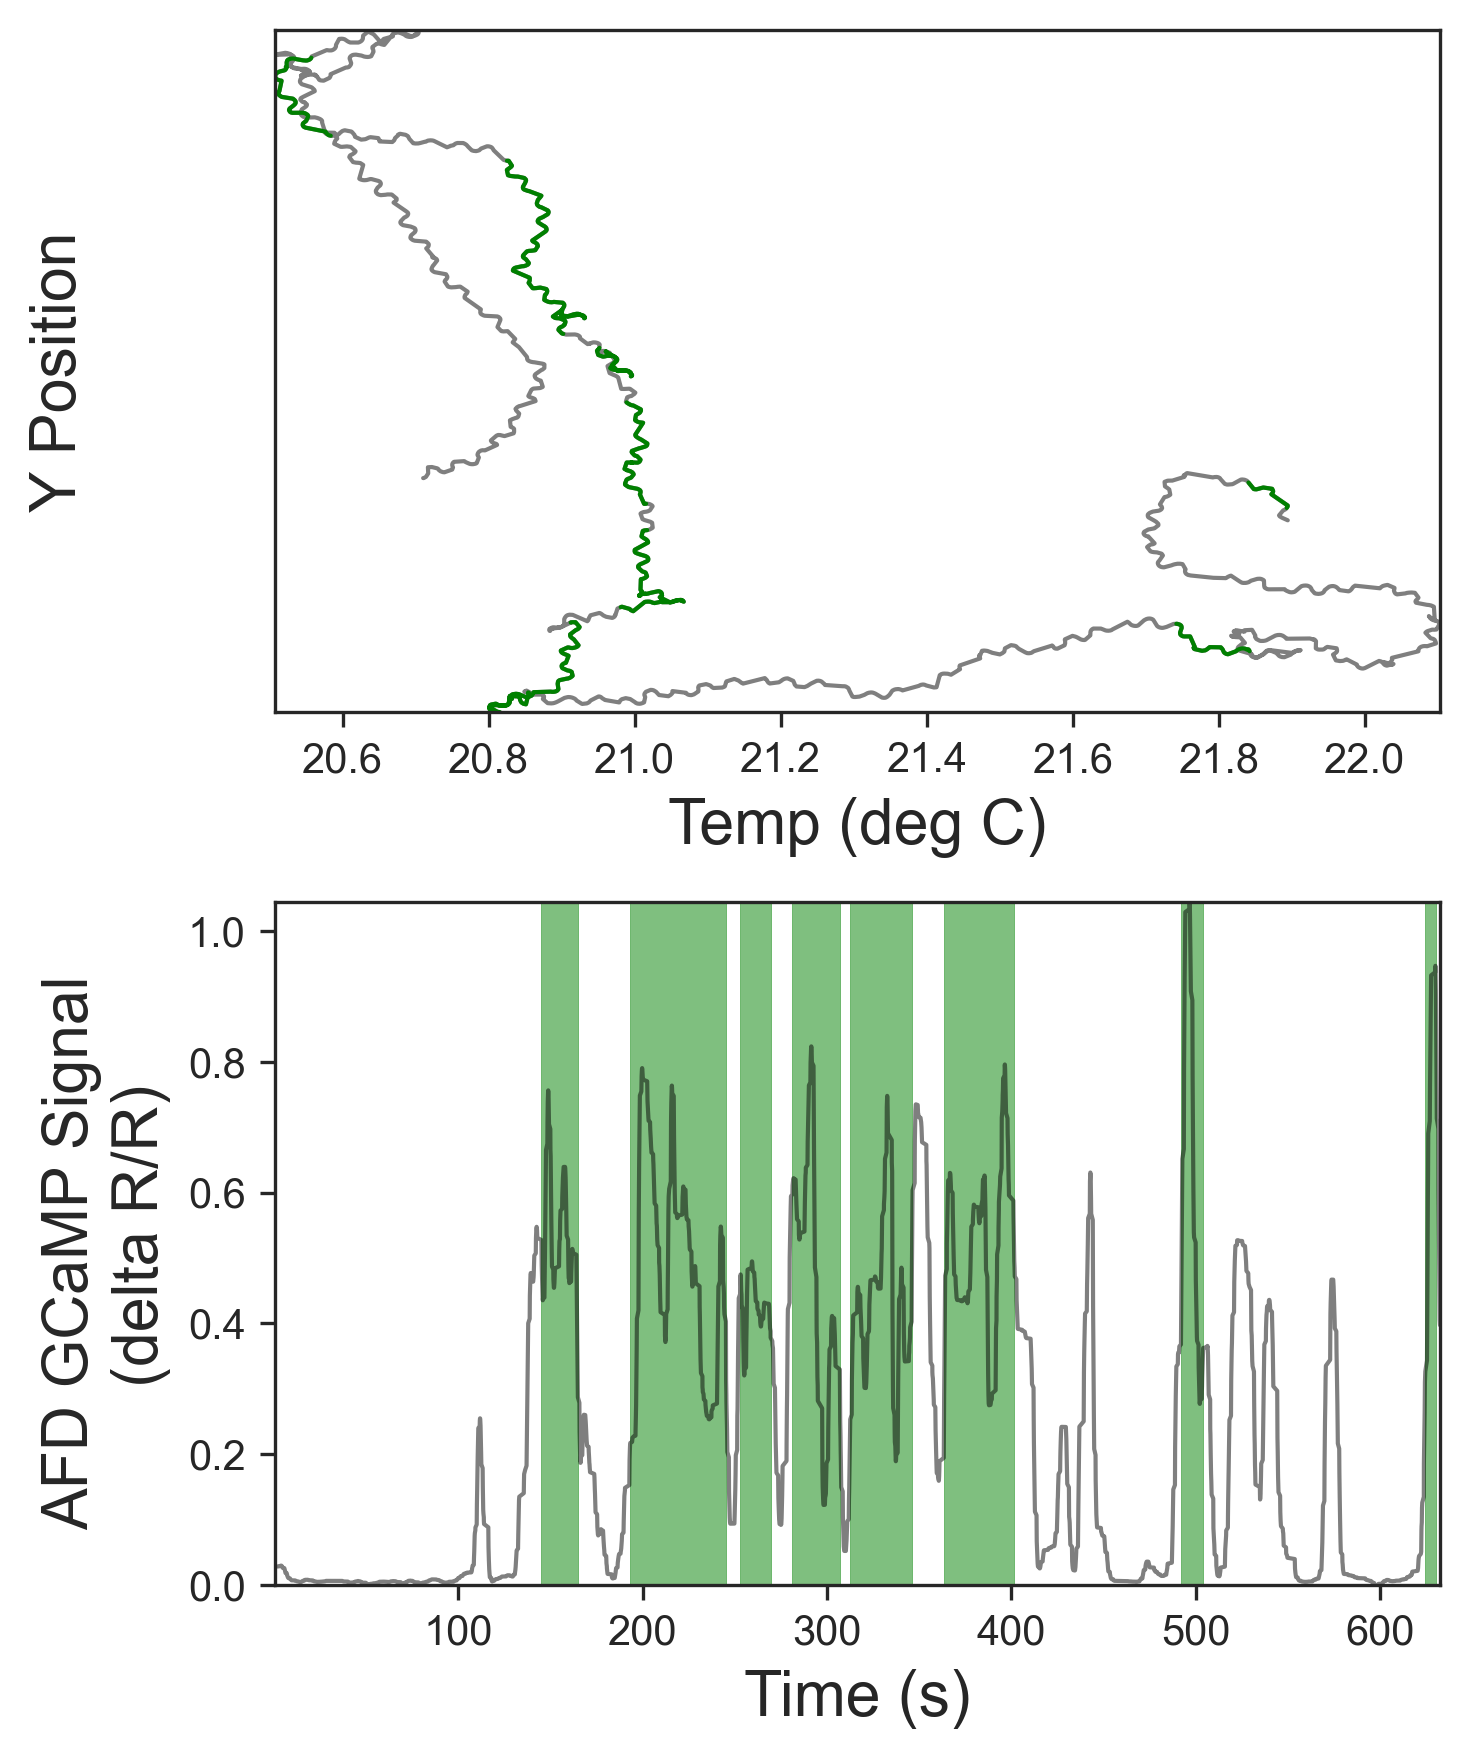

In [10]:
plateaus_steep_10_04_19_1 = [(1850,2160) ,(2550,3200), (3300,3500), (3655,4000), (4100,4520), (4730,5170), (6280,6465), (7800,7850) 
                          #, (3450,3800), (4500,4900), (6000,6500)
                          ] #5100,5200

plateaus_steep_10_04_19 = plateaus_steep_10_04_19_1
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6),dpi=300)
ax2 = plt.subplot(2,1,1)

ax1 = plt.subplot(2,1,2) ##
#plt.title('Visually Called Plateaus', fontsize=15)

ax2.plot(Temp_steep_10_04_19, Ycoord_steep_10_04_19, c='k', lw=1, alpha=0.5)
ax1.plot(Time_steep_10_04_19, DeltaR_steep_10_04_19, c='k', lw=1, alpha=0.5)

#for i in comp_run_east_video_steep_10_04_19:
#    start, stop = find_start_stop(i, Frames_steep_10_04_19)
#    ax2.plot(Temp_steep_10_04_19[i[0]:i[1]], Ycoord_steep_10_04_19[i[0]:i[1]], c='r', lw=1)
#    ax1.plot(Time_steep_10_04_19[i[0]:i[1]], DeltaR_steep_10_04_19[i[0]:i[1]], c='r', lw=2)
    
for i in plateaus_steep_10_04_19:
    ax2.plot(Temp_steep_10_04_19[i[0]:i[1]],Ycoord_steep_10_04_19[i[0]:i[1]],c='g', lw=1)
    ax1.axvspan(Time_steep_10_04_19[i[0]],Time_steep_10_04_19[i[1]],alpha=0.5,color='green', lw=0.2)
    
ax2.tick_params(axis='y', colors='white')
ax2.tick_params(axis='x', labelsize=10)
ax2.set_xlim(xmin=min(Temp_steep_10_04_19),xmax=max(Temp_steep_10_04_19))
ax2.set_ylim(ymin=min(Ycoord_steep_10_04_19),ymax=max(Ycoord_steep_10_04_19))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp (deg C)', fontsize=15)
  
    
ax1.tick_params(axis = 'both', labelsize=10)
ax1.set_xlim(xmin=min(Time_steep_10_04_19),xmax=max(Time_steep_10_04_19))
ax1.set_ylim(ymin=min(DeltaR_steep_10_04_19),ymax=max(DeltaR_steep_10_04_19))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=15)
ax1.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout()
#plt.savefig('xxx.png', dpi=600, bbox_inches='tight')
#plt.savefig('xxx.svg', dpi=600, bbox_inches='tight')

plt.show()

# Shallow

## 2_5_20

In [29]:
source = "csv"
if source == "csv":
    # Load the CSV file
    pref = "Freely_Moving_Coordinates/"
    file_path = pref + "Shallow_5p5_2_5_20_1_data.csv"  
    df = pd.read_csv(file_path)

    # Store each column in its own list
    Ycoord_shallow_2_5_20_r1       = df['y'].tolist()
    Xcoord_shallow_2_5_20_r1       = df['x'].tolist()
    Temp_shallow_2_5_20_r1    = df['Temp'].tolist()
    Time_shallow_2_5_20_r1    = df['Time'].tolist()
    Frames_shallow_2_5_20_r1  = df['frames'].tolist()
    DeltaR_shallow_2_5_20_r1 = df['Delta_R'].tolist()
    
plateaus_shallow_2_5_20_r1 = [(1325,1755),(5700,6120),(7975,8700),(9000,9520)
                         ]

## 2_29_20

In [12]:
source = "csv"
if source == "csv":
    # Load the CSV file
    pref = "Freely_Moving_Coordinates/"
    file_path = pref + "Shallow_8p2_2_29_20_data.csv"  
    df = pd.read_csv(file_path)

    # Store each column in its own list
    Ycoord_shallow_2_29_20       = df['y_um_unsmoothed'].tolist()
    Xcoord_shallow_2_29_20       = df['x_Normalized_um_unsmoothed'].tolist()
    Temp_shallow_2_29_20    = df['Temp_DegC'].tolist()
    Time_shallow_2_29_20    = df['Time_s'].tolist()
    Frames_shallow_2_29_20  = df['frames'].tolist()
    DeltaR_shallow_2_29_20 = df['Delta_R_25smoothed'].tolist()
    
    

<Figure size 640x480 with 0 Axes>

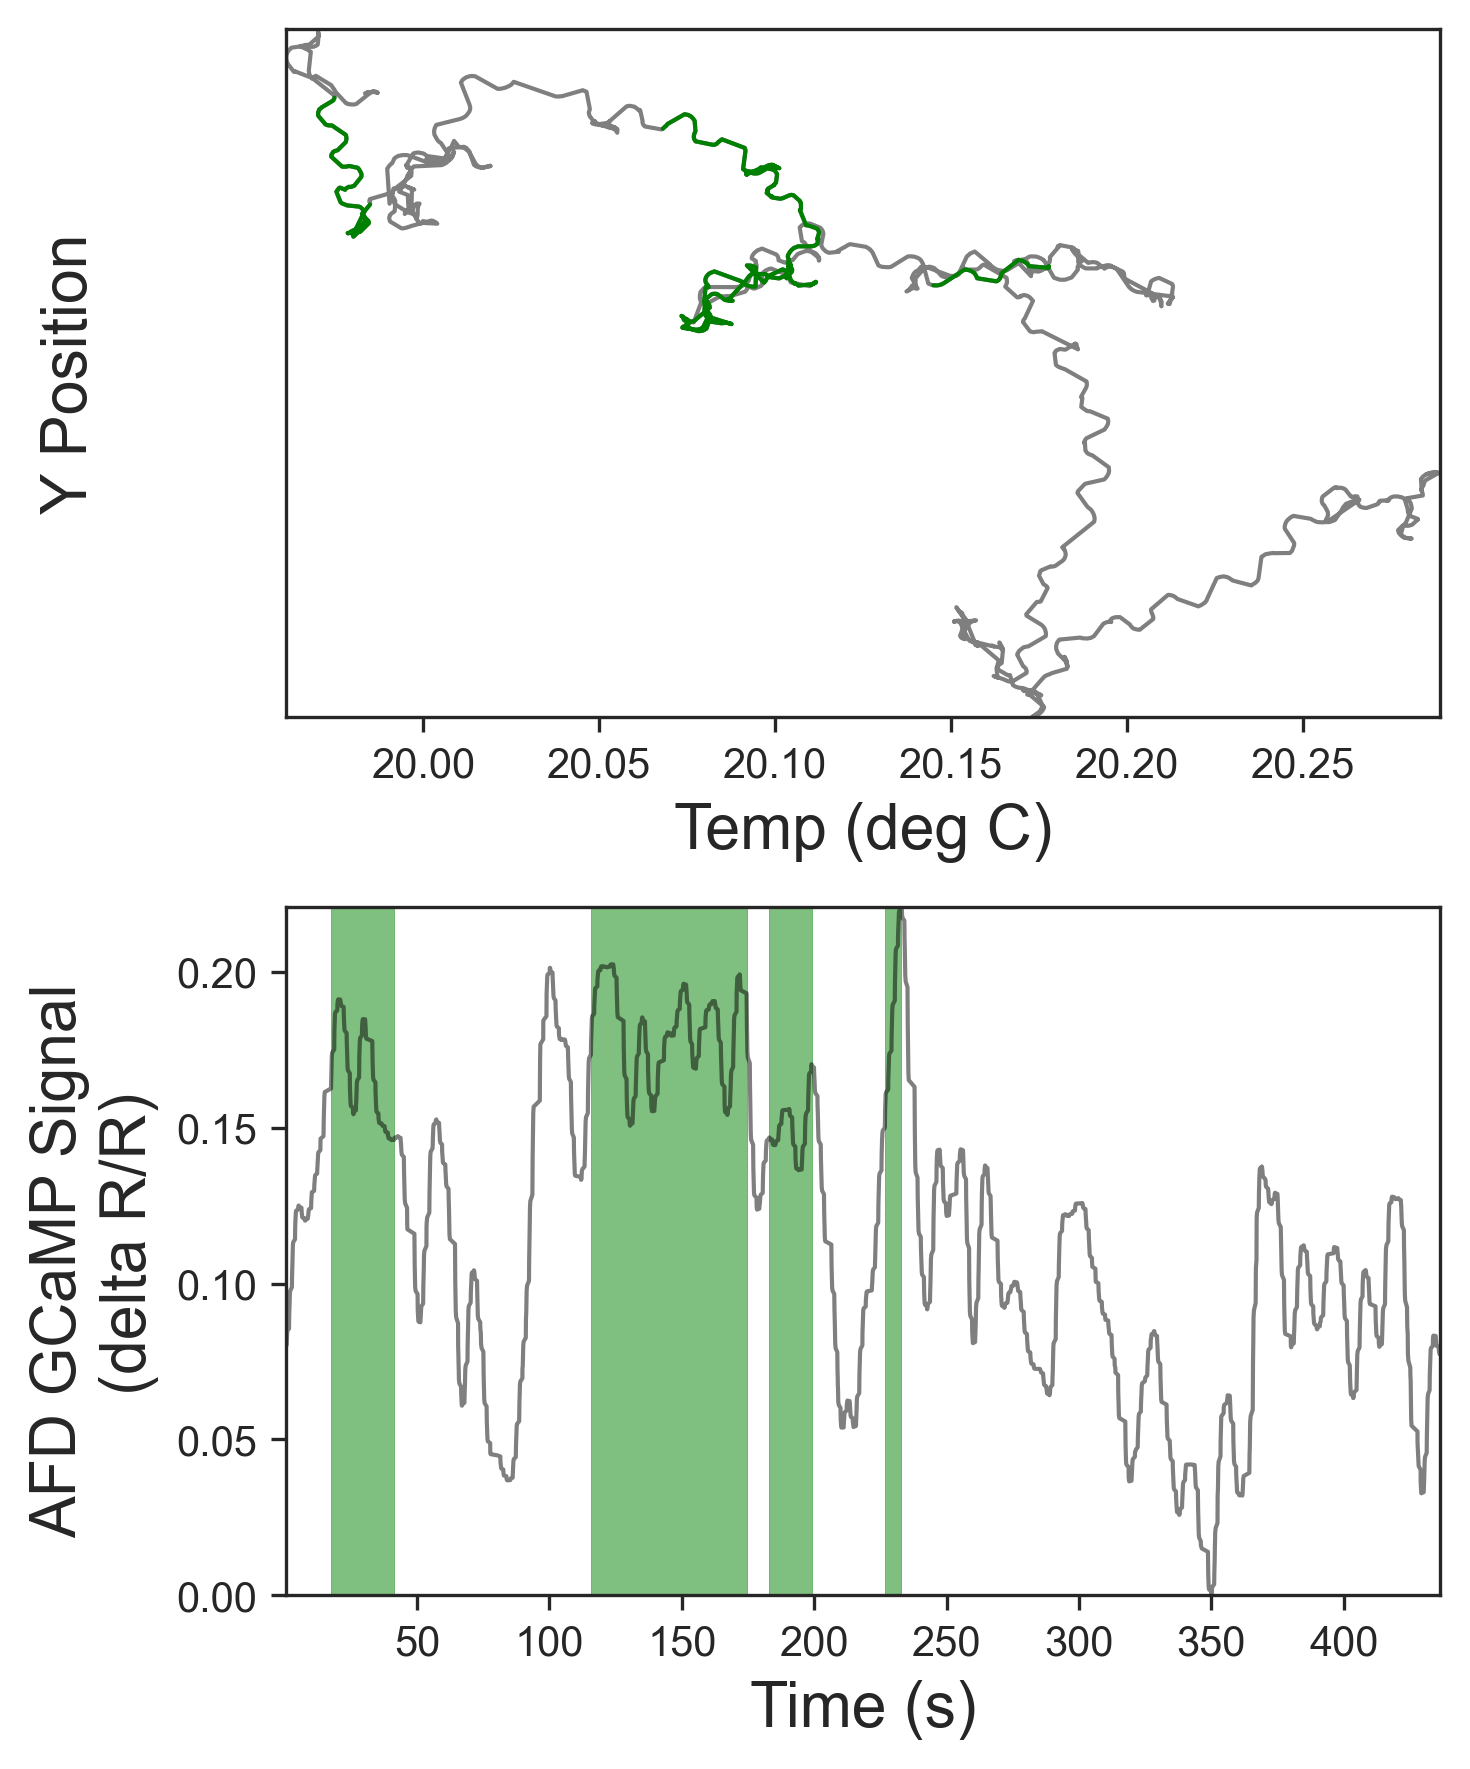

In [13]:
plateaus_shallow_2_29_20_3 = [(185,460) ,(1210,1880), (1975,2150) ,(2450,2525)
                          #, (3450,3800), (4500,4900), (6000,6500)
                          ]

plateaus_shallow_2_29_20 = plateaus_shallow_2_29_20_3
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6),dpi=300)
ax2 = plt.subplot(2,1,1)

ax1 = plt.subplot(2,1,2) ##
#plt.title('Visually Called Plateaus', fontsize=15)

ax2.plot(Temp_shallow_2_29_20, Ycoord_shallow_2_29_20, c='k', lw=1, alpha=0.5)
ax1.plot(Time_shallow_2_29_20, DeltaR_shallow_2_29_20, c='k', lw=1, alpha=0.5)

#for i in comp_run_east_video_shallow_2_29_20:
#    start, stop = find_start_stop(i, Frames_shallow_2_29_20)
#    ax2.plot(Temp_shallow_2_29_20[i[0]:i[1]], Ycoord_shallow_2_29_20[i[0]:i[1]], c='r', lw=1)
#    ax1.plot(Time_shallow_2_29_20[i[0]:i[1]], DeltaR_shallow_2_29_20[i[0]:i[1]], c='r', lw=2)
    
for i in plateaus_shallow_2_29_20:
    ax2.plot(Temp_shallow_2_29_20[i[0]:i[1]],Ycoord_shallow_2_29_20[i[0]:i[1]],c='g', lw=1)
    ax1.axvspan(Time_shallow_2_29_20[i[0]],Time_shallow_2_29_20[i[1]],alpha=0.5,color='green', lw=0.2)
    
ax2.tick_params(axis='y', colors='white')
ax2.tick_params(axis='x', labelsize=10)
ax2.set_xlim(xmin=min(Temp_shallow_2_29_20),xmax=max(Temp_shallow_2_29_20))
ax2.set_ylim(ymin=min(Ycoord_shallow_2_29_20),ymax=max(Ycoord_shallow_2_29_20))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp (deg C)', fontsize=15)
  
    
ax1.tick_params(axis = 'both', labelsize=10)
ax1.set_xlim(xmin=min(Time_shallow_2_29_20),xmax=max(Time_shallow_2_29_20))
ax1.set_ylim(ymin=min(DeltaR_shallow_2_29_20),ymax=max(DeltaR_shallow_2_29_20))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=15)
ax1.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout()
#plt.savefig('xxx.png', dpi=600, bbox_inches='tight')
#plt.savefig('xxx.svg', dpi=600, bbox_inches='tight')

plt.show()

## Shallow 12_10_19 R2

In [ ]:
source = "csv"
if source == "csv":
    # Load the CSV file
    pref = "Freely_Moving_Coordinates/"
    file_path = pref + "Shallow_12_10_19__r2_data.csv"  
    df = pd.read_csv(file_path)

    # Store each column in its own list
    Ycoord_shallow_12_10_19__r2       = df['y_um_unsmoothed'].tolist()
    Xcoord_shallow_12_10_19__r2       = df['x_Normalized_um_unsmoothed'].tolist()
    Temp_shallow_12_10_19__r2    = df['Temp_DegC'].tolist()
    Time_shallow_12_10_19__r2    = df['Time_s'].tolist()
    Frames_shallow_12_10_19__r2  = df['frames'].tolist()
    DeltaR_shallow_12_10_19__r2 = df['Delta_R_25smoothed'].tolist()
    
    

<Figure size 640x480 with 0 Axes>

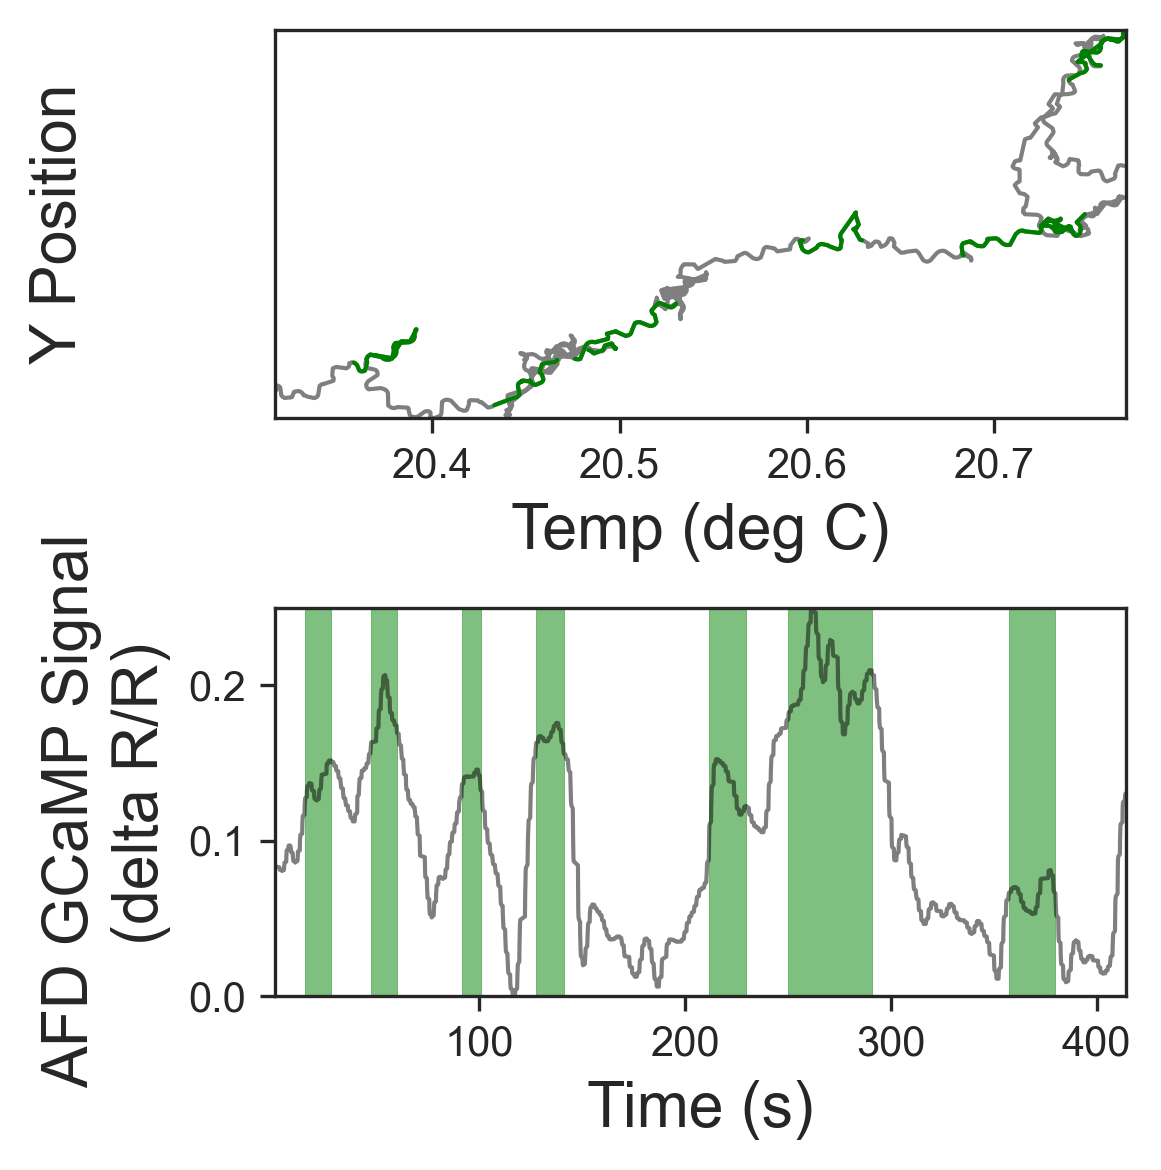

In [30]:
plateaus_shallow_12_10_19__r2_1 = [(200,350) ,(610,750), (1160,1270), (1580,1750), (2570,2780), (3020,3500), (4270,4520)
                          #, (3450,3800), (4500,4900), (6000,6500)
                          ]

plateaus_shallow_12_10_19__r2 = plateaus_shallow_12_10_19__r2_1
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(4,4),dpi=300)
ax2 = plt.subplot(2,1,1)

ax1 = plt.subplot(2,1,2) ##
#plt.title('Visually Called Plateaus', fontsize=15)

ax2.plot(Temp_shallow_12_10_19__r2, Ycoord_shallow_12_10_19__r2, c='k', lw=1, alpha=0.5)
ax1.plot(Time_shallow_12_10_19__r2, DeltaR_shallow_12_10_19__r2, c='k', lw=1, alpha=0.5)

#for i in comp_run_east_video_shallow_12_10_19__r2:
#    start, stop = find_start_stop(i, Frames_shallow_2_29_20)
#    ax2.plot(Temp_shallow_12_10_19__r2[i[0]:i[1]], Ycoord_shallow_12_10_19__r2[i[0]:i[1]], c='r', lw=1)
#    ax1.plot(Time_shallow_12_10_19__r2[i[0]:i[1]], DeltaR_shallow_12_10_19__r2[i[0]:i[1]], c='r', lw=2)
    
for i in plateaus_shallow_12_10_19__r2:
    ax2.plot(Temp_shallow_12_10_19__r2[i[0]:i[1]],Ycoord_shallow_12_10_19__r2[i[0]:i[1]],c='g', lw=1)
    ax1.axvspan(Time_shallow_12_10_19__r2[i[0]],Time_shallow_12_10_19__r2[i[1]],alpha=0.5,color='green', lw=0.2)
    
ax2.tick_params(axis='y', colors='white')
ax2.tick_params(axis='x', labelsize=10)
ax2.set_xlim(xmin=min(Temp_shallow_12_10_19__r2),xmax=max(Temp_shallow_12_10_19__r2))
ax2.set_ylim(ymin=min(Ycoord_shallow_12_10_19__r2),ymax=max(Ycoord_shallow_12_10_19__r2))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp (deg C)', fontsize=15)
  
    
ax1.tick_params(axis = 'both', labelsize=10)
ax1.set_xlim(xmin=min(Time_shallow_12_10_19__r2),xmax=max(Time_shallow_12_10_19__r2))
ax1.set_ylim(ymin=min(DeltaR_shallow_12_10_19__r2),ymax=max(DeltaR_shallow_12_10_19__r2))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=15)
ax1.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout()
#plt.savefig('xxx.png', dpi=600, bbox_inches='tight')
#plt.savefig('xxx.svg', dpi=600, bbox_inches='tight')

plt.show()

## Shallow 12_10_19 R3

In [31]:
source = "csv"
if source == "csv":
    # Load the CSV file
    pref = "Z:/Malcom/Freely_Moving_Folder_FromML_PC/AFD_Model/Candidates_extrasets_MDG/"
    file_path = pref + "Shallow_12_10_19__r3_data.csv"  
    df = pd.read_csv(file_path)

    # Store each column in its own list
    Ycoord_shallow_12_10_19__r3       = df['y_um_unsmoothed'].tolist()
    Xcoord_shallow_12_10_19__r3       = df['x_Normalized_um_unsmoothed'].tolist()
    Temp_shallow_12_10_19__r3    = df['Temp_DegC'].tolist()
    Time_shallow_12_10_19__r3    = df['Time_s'].tolist()
    Frames_shallow_12_10_19__r3  = df['frames'].tolist()
    DeltaR_shallow_12_10_19__r3 = df['Delta_R_25smoothed'].tolist()
    
    

<Figure size 640x480 with 0 Axes>

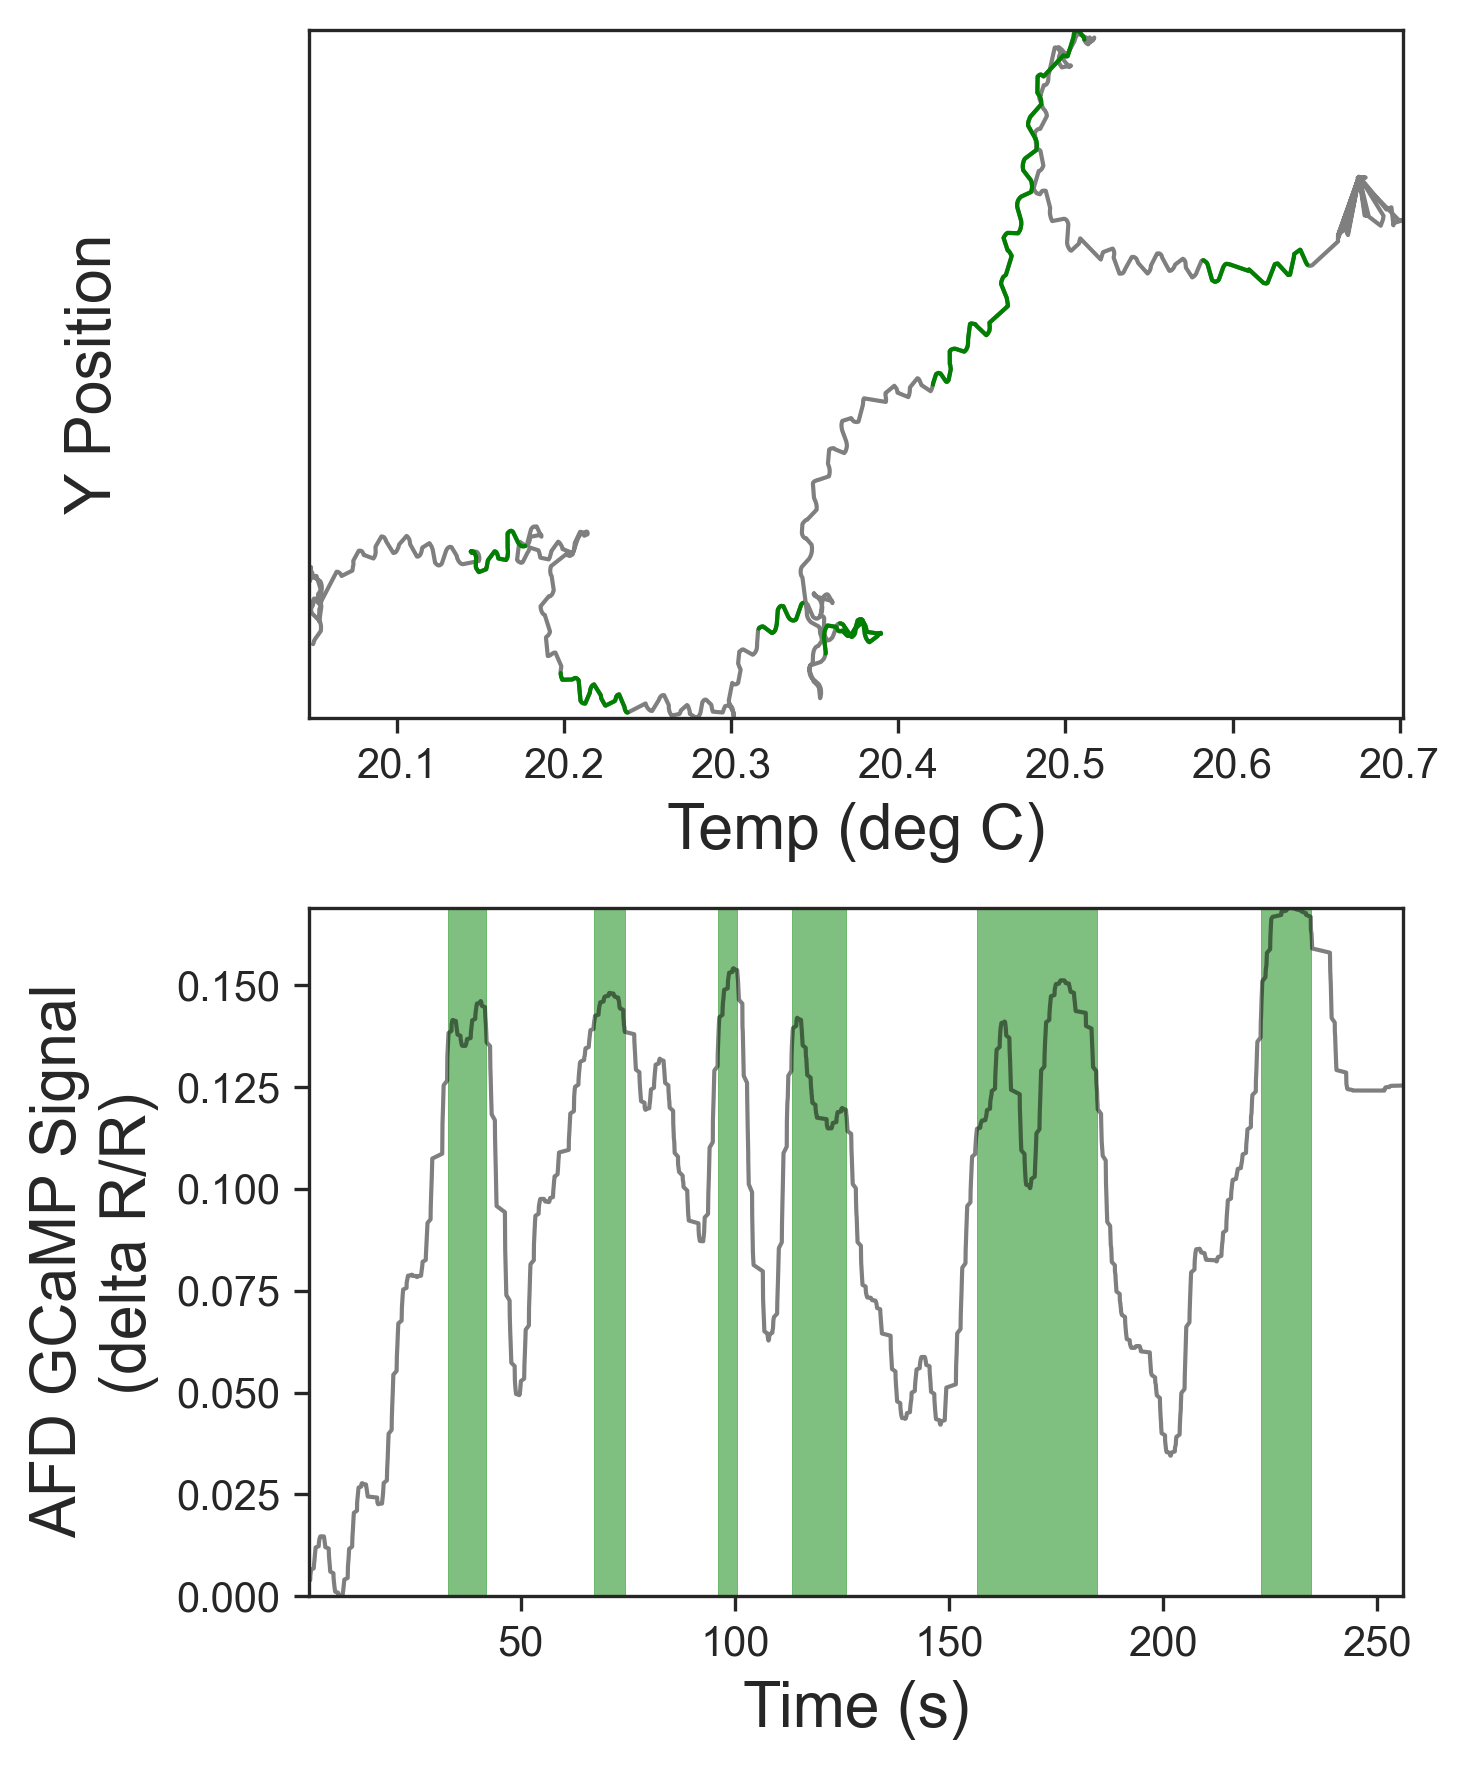

In [32]:
plateaus_shallow_12_10_19__r3_1 = [(400,520) ,(800,870), (1075,1135), (1270,1390), (1750,2050) , (2450,2500)
                          #, (3450,3800), (4500,4900), (6000,6500)
                          ]

plateaus_shallow_12_10_19__r3 = plateaus_shallow_12_10_19__r3_1
plt.clf()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize=(5,6),dpi=300)
ax2 = plt.subplot(2,1,1)

ax1 = plt.subplot(2,1,2) ##
#plt.title('Visually Called Plateaus', fontsize=15)

ax2.plot(Temp_shallow_12_10_19__r3, Ycoord_shallow_12_10_19__r3, c='k', lw=1, alpha=0.5)
ax1.plot(Time_shallow_12_10_19__r3, DeltaR_shallow_12_10_19__r3, c='k', lw=1, alpha=0.5)

#for i in comp_run_east_video_shallow_12_10_19__r3:
#    start, stop = find_start_stop(i, Frames_shallow_2_29_20)
#    ax2.plot(Temp_shallow_12_10_19__r3[i[0]:i[1]], Ycoord_shallow_12_10_19__r3[i[0]:i[1]], c='r', lw=1)
#    ax1.plot(Time_shallow_12_10_19__r3[i[0]:i[1]], DeltaR_shallow_12_10_19__r3[i[0]:i[1]], c='r', lw=2)
    
for i in plateaus_shallow_12_10_19__r3:
    ax2.plot(Temp_shallow_12_10_19__r3[i[0]:i[1]],Ycoord_shallow_12_10_19__r3[i[0]:i[1]],c='g', lw=1)
    ax1.axvspan(Time_shallow_12_10_19__r3[i[0]],Time_shallow_12_10_19__r3[i[1]],alpha=0.5,color='green', lw=0.2)
    
ax2.tick_params(axis='y', colors='white')
ax2.tick_params(axis='x', labelsize=10)
ax2.set_xlim(xmin=min(Temp_shallow_12_10_19__r3),xmax=max(Temp_shallow_12_10_19__r3))
ax2.set_ylim(ymin=min(Ycoord_shallow_12_10_19__r3),ymax=max(Ycoord_shallow_12_10_19__r3))
ax2.set_ylabel('Y Position', fontsize=15)
ax2.set_xlabel('Temp (deg C)', fontsize=15)
  
    
ax1.tick_params(axis = 'both', labelsize=10)
ax1.set_xlim(xmin=min(Time_shallow_12_10_19__r3),xmax=max(Time_shallow_12_10_19__r3))
ax1.set_ylim(ymin=min(DeltaR_shallow_12_10_19__r3),ymax=max(DeltaR_shallow_12_10_19__r3))
ax1.set_ylabel('AFD GCaMP Signal \n (delta R/R)', fontsize=15)
ax1.set_xlabel('Time (s)', fontsize=15)

plt.tight_layout()
#plt.savefig('xxx.png', dpi=600, bbox_inches='tight')
#plt.savefig('xxx.svg', dpi=600, bbox_inches='tight')

plt.show()

# Plateau Analysis

### Deriv vs Avg Signal

In [33]:
plateau_temp_rates_steep_3_4_20 = []
plateau_mean_cal_steep_3_4_20 = []

plateau_temp_rates_shallow_2_5_20_r1 = []
plateau_mean_cal_shallow_2_5_20_r1 = []

plateau_temp_rates_steep_3_5_20 = []
plateau_mean_cal_steep_3_5_20 = []

for i in plateaus_steep_3_4_20:
    plateau_temp_rates_steep_3_4_20.append(60*(Temp_steep_3_4_20[i[1]] - Temp_steep_3_4_20[i[0]])/
                                                (Time_steep_3_4_20[i[1]] - Time_steep_3_4_20[i[0]]))
    plateau_mean_cal_steep_3_4_20.append(np.mean(DeltaR_steep_3_4_20[i[0]:i[1]]))
    
for i in plateaus_shallow_2_5_20_r1:
    plateau_temp_rates_shallow_2_5_20_r1.append(60*(Temp_shallow_2_5_20_r1[i[1]] - Temp_shallow_2_5_20_r1[i[0]])/
                                                (Time_shallow_2_5_20_r1[i[1]] - Time_shallow_2_5_20_r1[i[0]]))
    plateau_mean_cal_shallow_2_5_20_r1.append(np.mean(DeltaR_shallow_2_5_20_r1[i[0]:i[1]]))
    
for i in plateaus_steep_3_5_20:
    plateau_temp_rates_steep_3_5_20.append(60*(Temp_steep_3_5_20[i[1]] - Temp_steep_3_5_20[i[0]])/
                                                (Time_steep_3_5_20[i[1]] - Time_steep_3_5_20[i[0]]))
    plateau_mean_cal_steep_3_5_20.append(np.mean(DeltaR_steep_3_5_20[i[0]:i[1]]))

In [34]:
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

def plot_plateau_fit(x_data, y_data):
    
    model = np.polyfit(x_data, y_data, 1)
    predict = np.poly1d(model)

    r2 = r2_score(y_data, predict(x_data))
    print(r2)

    slope = model[0]
    intercept = model[1]

    print(f"Line equation: y = {slope:.6f}x + {intercept:.6f}")

    x_lin_reg = np.arange(min(x_data), max(x_data), 0.001)
    y_lin_reg = predict(x_lin_reg)

    plt.clf()
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,8))
    ax1 = plt.subplot(1,1,1)

    colors = np.arange(len(x_data))

    sc = ax1.scatter(
        x_data,
        y_data,
        c=colors,
        cmap='viridis',
        s=60
    )

    plt.colorbar(sc, ax=ax1, label='Plateau Index')

    ax1.plot(
        x_lin_reg,
        y_lin_reg,
        c='g',
        label=f'Combined, r² = {r2:.3f}'
    )

    ax1.legend(fontsize=15)
    ax1.tick_params(axis='y', labelsize=15)
    ax1.tick_params(axis='x', labelsize=15)

    # ax1.set_xlim(xmin=0.05,xmax=0.65)
    # ax1.set_ylim(ymin=0.1, ymax=0.5)

    ax1.set_ylabel('Mean Plateau Cal (delta R/R)', fontsize=15)
    ax1.set_xlabel('Plateau Temp Rate (deg C per min)', fontsize=15)

    plt.show()
    plt.close()

    return model, predict, r2

0.8696201124164256
Line equation: y = 0.692723x + 0.153698


<Figure size 640x480 with 0 Axes>

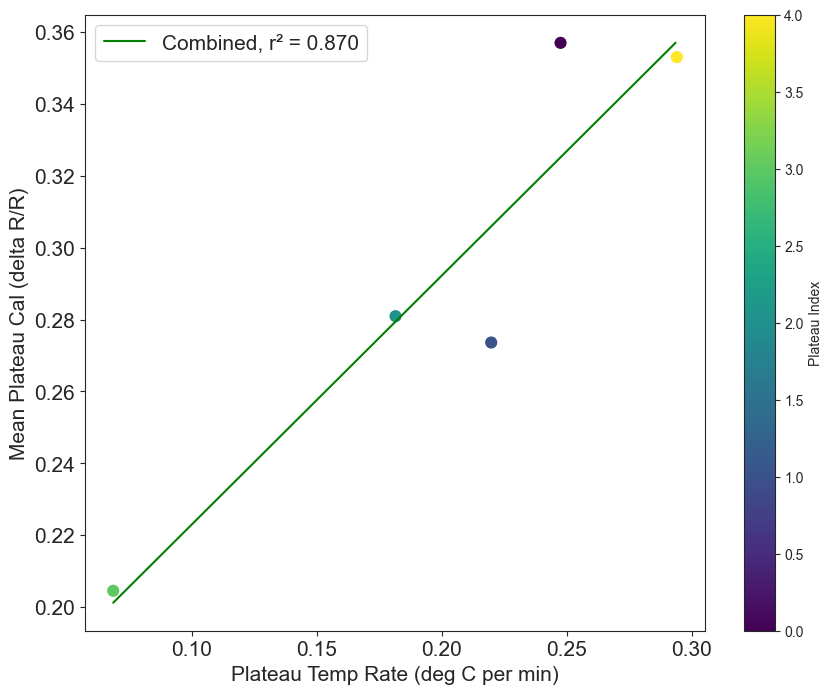

0.864906854508271
Line equation: y = 0.249006x + 0.247143


<Figure size 640x480 with 0 Axes>

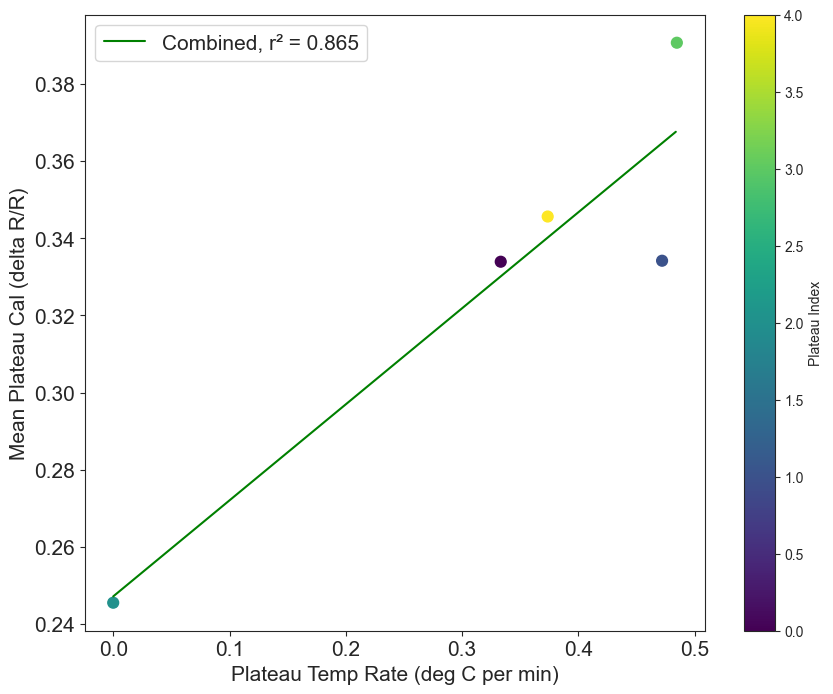

0.8091252164158104
Line equation: y = 1.412598x + 0.027167


<Figure size 640x480 with 0 Axes>

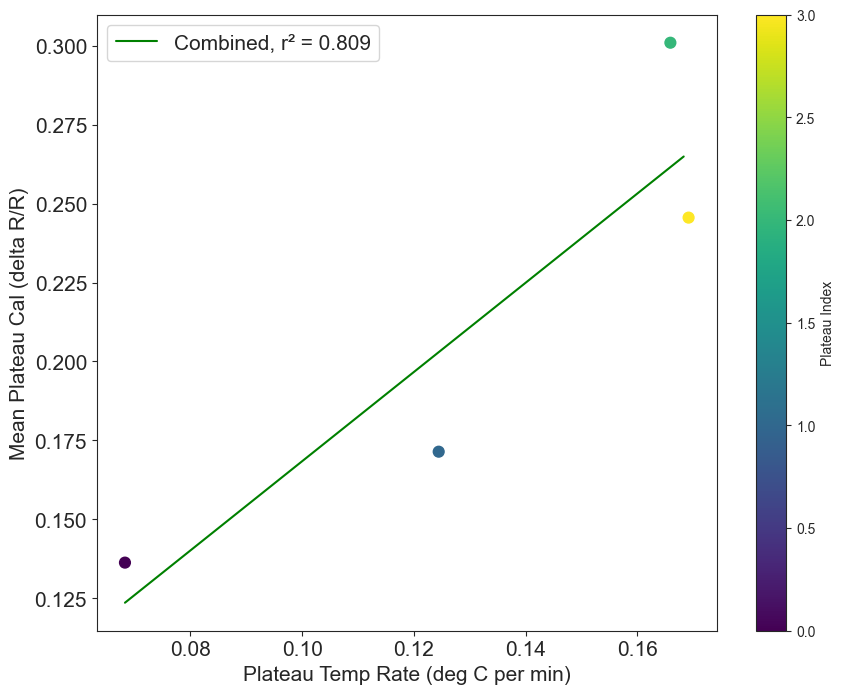

(array([1.41259827, 0.02716704]),
 poly1d([1.41259827, 0.02716704]),
 0.8091252164158104)

In [35]:
plot_plateau_fit(plateau_temp_rates_steep_3_4_20, plateau_mean_cal_steep_3_4_20)
plot_plateau_fit(plateau_temp_rates_steep_3_5_20, plateau_mean_cal_steep_3_5_20)
plot_plateau_fit(plateau_temp_rates_shallow_2_5_20_r1, plateau_mean_cal_shallow_2_5_20_r1)

0.7214544906581382


<Figure size 640x480 with 0 Axes>

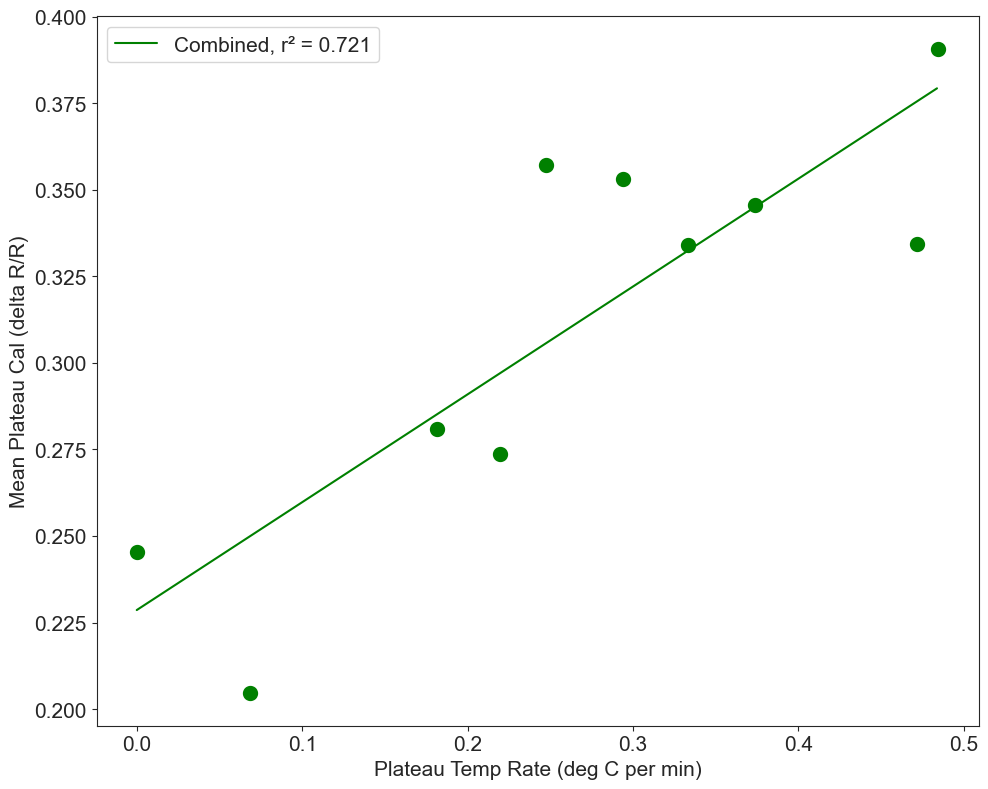

In [36]:
# Combined steep_

combined_steep_plateau_temp_rates = plateau_temp_rates_steep_3_4_20 + plateau_temp_rates_steep_3_5_20 
combined_steep_plateau_mean_cal = plateau_mean_cal_steep_3_4_20 + plateau_mean_cal_steep_3_5_20 

model = np.polyfit(combined_steep_plateau_temp_rates, combined_steep_plateau_mean_cal, 1)
predict = np.poly1d(model)
from sklearn.metrics import r2_score
r2 = r2_score(combined_steep_plateau_mean_cal, predict(combined_steep_plateau_temp_rates))
print(r2)

x_lin_reg = np.arange(min(combined_steep_plateau_temp_rates), max(combined_steep_plateau_temp_rates), 0.001)
y_lin_reg = predict(x_lin_reg)

plt.clf()
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(10,8))
ax1 = plt.subplot(1,1,1)
ax1.scatter(combined_steep_plateau_temp_rates, combined_steep_plateau_mean_cal, c='g', lw=5)
ax1.plot(x_lin_reg,y_lin_reg, c='g', label = f'Combined, r² = {r2:.3f}')
ax1.legend(fontsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.tick_params(axis='x', labelsize=15)
#ax1.set_xlim(xmin=0.05,xmax=0.65)
#ax1.set_ylim(ymin=0.1, ymax=0.5)
ax1.set_ylabel('Mean Plateau Cal (delta R/R)', fontsize=15)
ax1.set_xlabel('Plateau Temp Rate (deg C per min)', fontsize=15)
plt.tight_layout()
#plt.savefig('Z:/Malcom/Freely_Moving_Folder_FromML_PC/Plateaus_moreLabeling_AmplitudeAnalysis/Combined_steep_Plats_deriv_vs_meanCa.svg', dpi=600, bbox_inches='tight')
plt.show()
plt.close()


#### EXTRA DATASETS

0.7476471629247876


<Figure size 640x480 with 0 Axes>

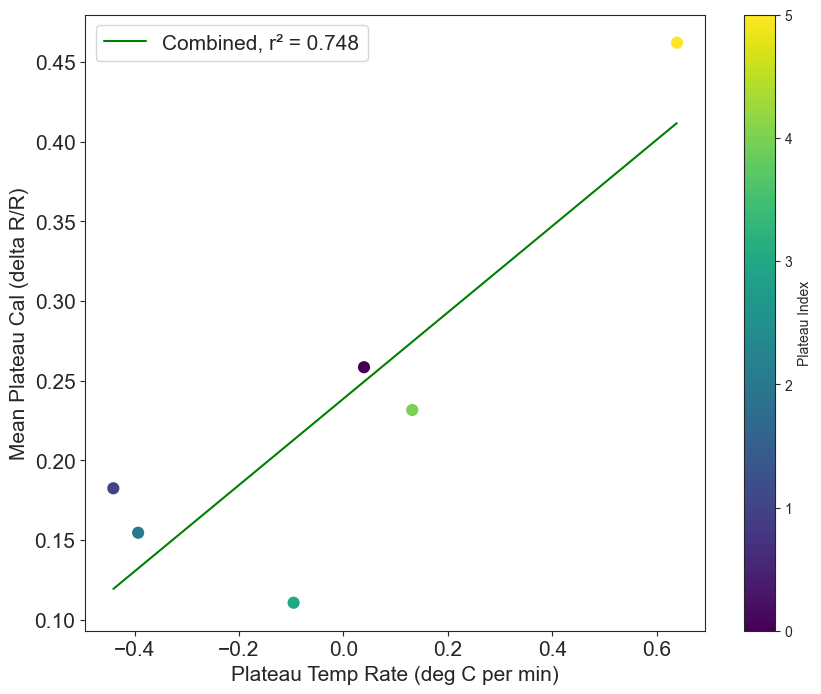

In [37]:
# STEEP 2_5_20
plateau_temp_rates_steep_2_5_20 = []
plateau_mean_cal_steep_2_5_20 = []

for i in plateaus_steep_2_5_20:
    plateau_temp_rates_steep_2_5_20.append(60*(Temp_steep_2_5_20[i[1]] - Temp_steep_2_5_20[i[0]])/
                                                (Time_steep_2_5_20[i[1]] - Time_steep_2_5_20[i[0]]))
    plateau_mean_cal_steep_2_5_20.append(np.mean(DeltaR_steep_2_5_20[i[0]:i[1]]))
    
model = np.polyfit(plateau_temp_rates_steep_2_5_20, plateau_mean_cal_steep_2_5_20, 1)
predict = np.poly1d(model)
from sklearn.metrics import r2_score
r2 = r2_score(plateau_mean_cal_steep_2_5_20, predict(plateau_temp_rates_steep_2_5_20))
print(r2)

x_lin_reg = np.arange(min(plateau_temp_rates_steep_2_5_20), max(plateau_temp_rates_steep_2_5_20), 0.001)
y_lin_reg = predict(x_lin_reg)

plt.clf()
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(10,8))
ax1 = plt.subplot(1,1,1)
colors = np.arange(len(plateau_temp_rates_steep_2_5_20))

sc = ax1.scatter(
    plateau_temp_rates_steep_2_5_20,
    plateau_mean_cal_steep_2_5_20,
    c=colors,
    cmap='viridis',
    s=60
)

plt.colorbar(sc, ax=ax1, label='Plateau Index')
ax1.plot(x_lin_reg,y_lin_reg, c='g', label = f'Combined, r² = {r2:.3f}')
ax1.legend(fontsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.tick_params(axis='x', labelsize=15)
#ax1.set_xlim(xmin=0.05,xmax=0.65)
#ax1.set_ylim(ymin=0.1, ymax=0.5)
ax1.set_ylabel('Mean Plateau Cal (delta R/R)', fontsize=15)
ax1.set_xlabel('Plateau Temp Rate (deg C per min)', fontsize=15)
plt.show()
plt.close()

0.7250095979256375
Line equation: y = 0.351061x + 0.476403
Slope = 0.351061
Intercept = 0.476403


<Figure size 640x480 with 0 Axes>

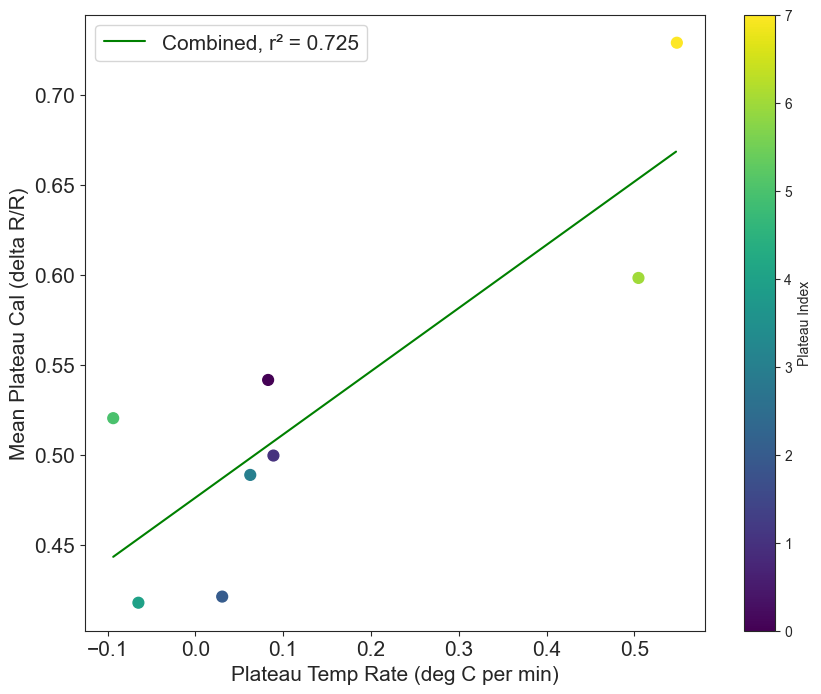

In [38]:
plateau_temp_rates_steep_10_04_19 = []
plateau_mean_cal_steep_10_04_19 = []

for i in plateaus_steep_10_04_19:
    plateau_temp_rates_steep_10_04_19.append(60*(Temp_steep_10_04_19[i[1]] - Temp_steep_10_04_19[i[0]])/
                                                (Time_steep_10_04_19[i[1]] - Time_steep_10_04_19[i[0]]))
    plateau_mean_cal_steep_10_04_19.append(np.mean(DeltaR_steep_10_04_19[i[0]:i[1]]))
    
model = np.polyfit(plateau_temp_rates_steep_10_04_19, plateau_mean_cal_steep_10_04_19, 1)
predict = np.poly1d(model)
from sklearn.metrics import r2_score
r2 = r2_score(plateau_mean_cal_steep_10_04_19, predict(plateau_temp_rates_steep_10_04_19))
print(r2)

x_lin_reg = np.arange(min(plateau_temp_rates_steep_10_04_19), max(plateau_temp_rates_steep_10_04_19), 0.001)
y_lin_reg = predict(x_lin_reg)

slope = model[0]
intercept = model[1]

print(f"Line equation: y = {slope:.6f}x + {intercept:.6f}")
print(f"Slope = {slope:.6f}")
print(f"Intercept = {intercept:.6f}")

plt.clf()
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(10,8))
ax1 = plt.subplot(1,1,1)
colors = np.arange(len(plateau_temp_rates_steep_10_04_19))

sc = ax1.scatter(
    plateau_temp_rates_steep_10_04_19,
    plateau_mean_cal_steep_10_04_19,
    c=colors,
    cmap='viridis',
    s=60
)

plt.colorbar(sc, ax=ax1, label='Plateau Index')
ax1.plot(x_lin_reg,y_lin_reg, c='g', label = f'Combined, r² = {r2:.3f}')
ax1.legend(fontsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.tick_params(axis='x', labelsize=15)
#ax1.set_xlim(xmin=0.05,xmax=0.65)
#ax1.set_ylim(ymin=0.1, ymax=0.5)
ax1.set_ylabel('Mean Plateau Cal (delta R/R)', fontsize=15)
ax1.set_xlabel('Plateau Temp Rate (deg C per min)', fontsize=15)
plt.show()
plt.close()

0.7329736351939993


<Figure size 640x480 with 0 Axes>

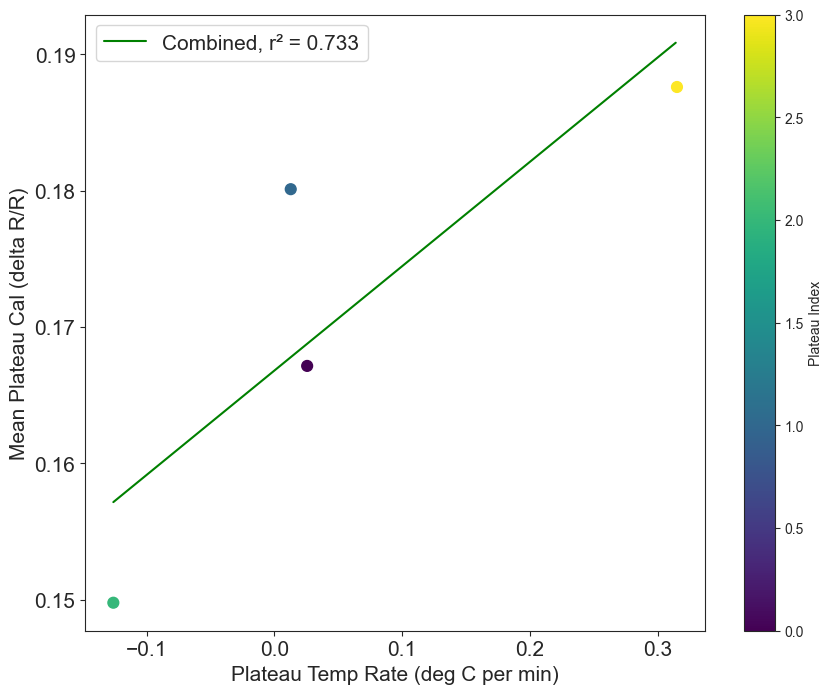

In [39]:
# SHALLOW 2_29_20 
plateau_temp_rates_shallow_2_29_20 = []
plateau_mean_cal_shallow_2_29_20 = []

for i in plateaus_shallow_2_29_20:
    plateau_temp_rates_shallow_2_29_20.append(60*(Temp_shallow_2_29_20[i[1]] - Temp_shallow_2_29_20[i[0]])/
                                                (Time_shallow_2_29_20[i[1]] - Time_shallow_2_29_20[i[0]]))
    plateau_mean_cal_shallow_2_29_20.append(np.mean(DeltaR_shallow_2_29_20[i[0]:i[1]]))
    
model = np.polyfit(plateau_temp_rates_shallow_2_29_20, plateau_mean_cal_shallow_2_29_20, 1)
predict = np.poly1d(model)
from sklearn.metrics import r2_score
r2 = r2_score(plateau_mean_cal_shallow_2_29_20, predict(plateau_temp_rates_shallow_2_29_20))
print(r2)

x_lin_reg = np.arange(min(plateau_temp_rates_shallow_2_29_20), max(plateau_temp_rates_shallow_2_29_20), 0.001)
y_lin_reg = predict(x_lin_reg)

plt.clf()
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(10,8))
ax1 = plt.subplot(1,1,1)
colors = np.arange(len(plateau_temp_rates_shallow_2_29_20))

sc = ax1.scatter(
    plateau_temp_rates_shallow_2_29_20,
    plateau_mean_cal_shallow_2_29_20,
    c=colors,
    cmap='viridis',
    s=60
)

plt.colorbar(sc, ax=ax1, label='Plateau Index')
ax1.plot(x_lin_reg,y_lin_reg, c='g', label = f'Combined, r² = {r2:.3f}')
ax1.legend(fontsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.tick_params(axis='x', labelsize=15)
#ax1.set_xlim(xmin=0.05,xmax=0.65)
#ax1.set_ylim(ymin=0.1, ymax=0.5)
ax1.set_ylabel('Mean Plateau Cal (delta R/R)', fontsize=15)
ax1.set_xlabel('Plateau Temp Rate (deg C per min)', fontsize=15)
plt.show()
plt.close()

0.5573759500915407
Line equation: y = 0.386811x + 0.110238


<Figure size 640x480 with 0 Axes>

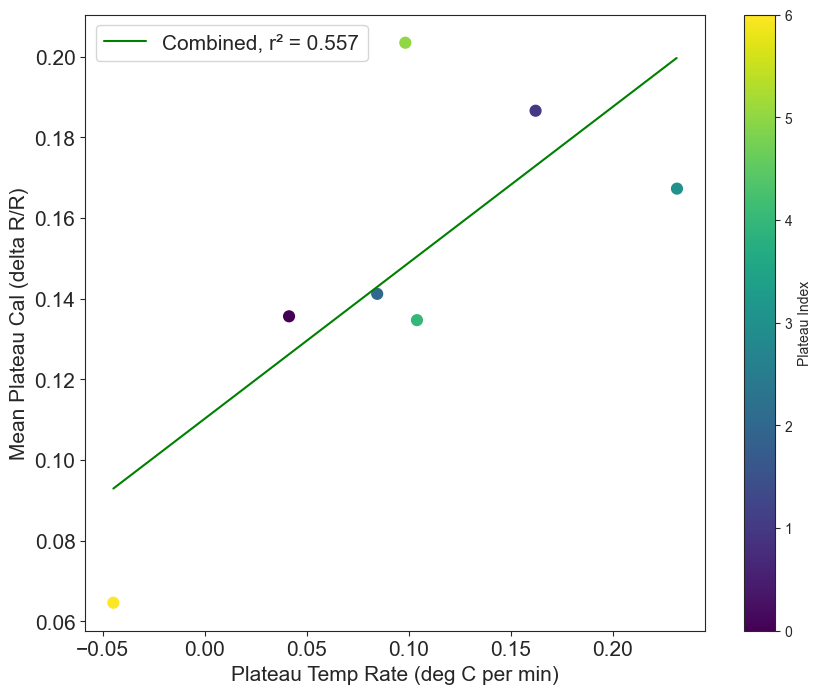

(array([0.38681095, 0.11023796]),
 poly1d([0.38681095, 0.11023796]),
 0.5573759500915407)

In [40]:
plateau_temp_rates_shallow_12_10_19__r2 = []
plateau_mean_cal_shallow_12_10_19__r2 = []

for i in plateaus_shallow_12_10_19__r2:
    plateau_temp_rates_shallow_12_10_19__r2.append(60*(Temp_shallow_12_10_19__r2[i[1]] - Temp_shallow_12_10_19__r2[i[0]])/
                                                (Time_shallow_12_10_19__r2[i[1]] - Time_shallow_12_10_19__r2[i[0]]))
    plateau_mean_cal_shallow_12_10_19__r2.append(np.mean(DeltaR_shallow_12_10_19__r2[i[0]:i[1]]))

plot_plateau_fit(plateau_temp_rates_shallow_12_10_19__r2, plateau_mean_cal_shallow_12_10_19__r2)

0.6774104194339466
Line equation: y = 0.068790x + 0.125944


<Figure size 640x480 with 0 Axes>

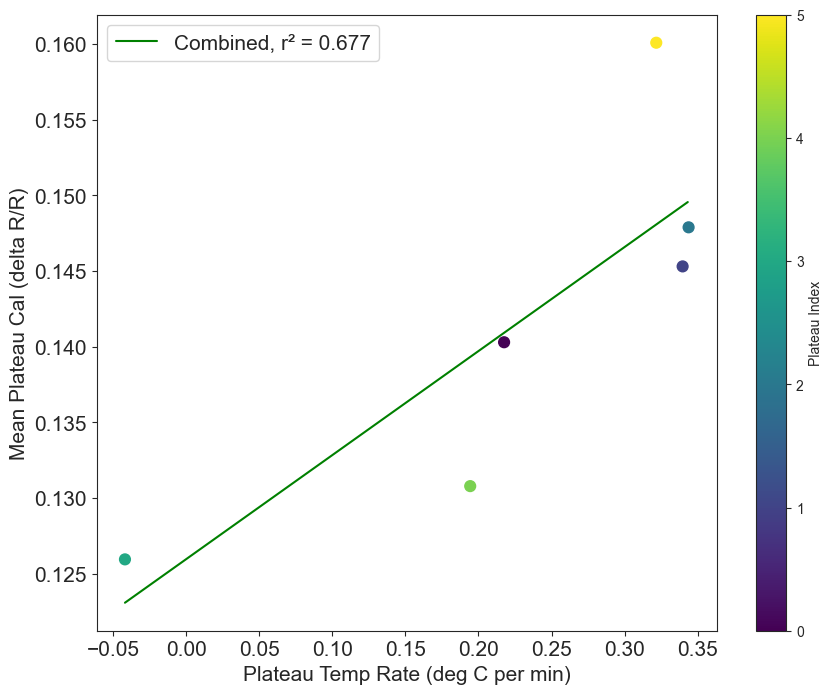

(array([0.06879033, 0.12594408]),
 poly1d([0.06879033, 0.12594408]),
 0.6774104194339466)

In [41]:
plateau_temp_rates_shallow_12_10_19__r3 = []
plateau_mean_cal_shallow_12_10_19__r3 = []

for i in plateaus_shallow_12_10_19__r3:
    plateau_temp_rates_shallow_12_10_19__r3.append(60*(Temp_shallow_12_10_19__r3[i[1]] - Temp_shallow_12_10_19__r3[i[0]])/
                                                (Time_shallow_12_10_19__r3[i[1]] - Time_shallow_12_10_19__r3[i[0]]))
    plateau_mean_cal_shallow_12_10_19__r3.append(np.mean(DeltaR_shallow_12_10_19__r3[i[0]:i[1]]))

plot_plateau_fit(plateau_temp_rates_shallow_12_10_19__r3, plateau_mean_cal_shallow_12_10_19__r3)

## Population Analysis

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score


def plot_plateau_population(worms, normalize=None):
    """
    Parameters
    ----------
    worms : dict
        Format:
        worms = {
            "worm1": {"x": [...], "y": [...]},
            "worm2": {"x": [...], "y": [...]},
            ...
        }

    normalize : None, 'slope', 'minmax', 'zscore'

    Returns
    -------
    df : pandas.DataFrame
        Contains both raw and plotted values for later statistics.
    """

    plt.clf()
    fig, ax = plt.subplots(figsize=(6,5))

    colors = plt.cm.tab10(np.linspace(0,1,len(worms)))

    rows = []

    for color, (worm, dat) in zip(colors, worms.items()):

        x = np.asarray(dat["x"], dtype=float)
        y = np.asarray(dat["y"], dtype=float)

        ##############################
        # ORIGINAL FIT (unchanged)
        ##############################

        model = np.polyfit(x, y, 1)
        predict = np.poly1d(model)

        slope = model[0]
        intercept = model[1]

        r2 = r2_score(y, predict(x))

        print(f"\n{worm}")
        print(f"y = {slope:.6f}x + {intercept:.6f}")
        print(f"R² = {r2:.4f}")

        ##############################
        # NORMALIZATION (plot only)
        ##############################

        if normalize is None:

            y_plot = y.copy()

        elif normalize == "slope":

            y_plot = y / slope

        elif normalize == "minmax":

            y_plot = (y - np.min(y)) / (np.max(y) - np.min(y))

        elif normalize == "zscore":

            y_plot = (y - np.mean(y)) / np.std(y)

        else:

            raise ValueError("normalize must be None, 'slope', 'minmax', or 'zscore'")

        ##############################
        # FIT NORMALIZED DATA FOR DISPLAY
        ##############################

        model_plot = np.polyfit(x, y_plot, 1)
        predict_plot = np.poly1d(model_plot)

        xx = np.arange(np.min(x), np.max(x), 0.001)

        ##############################
        # PLOT
        ##############################

        ax.scatter(
            x,
            y_plot,
            color=color,
            s=60,
            label=worm
        )

        ax.plot(
            xx,
            predict_plot(xx),
            color=color,
            lw=2
        )

        ##############################
        # STORE FOR MIXED MODEL
        ##############################

        for xi, yi_raw, yi_plot in zip(x, y, y_plot):

            rows.append({
                "Worm": worm,
                "TempRate": xi,
                "DeltaR_raw": yi_raw,
                "DeltaR_plot": yi_plot
            })

    ax.set_xlabel("Plateau Temp Rate (°C/min)", fontsize=15)

    if normalize is None:
        ax.set_ylabel("Mean Plateau Cal (ΔR/R)", fontsize=15)
    else:
        ax.set_ylabel(f"Mean Plateau Cal ({normalize} normalized)", fontsize=15)

    ax.legend(fontsize=12)

    plt.tight_layout()
    plt.savefig('Combined_steep_Plats_deriv_vs_meanCa.svg', dpi=600, bbox_inches='tight')
    plt.show()

    return pd.DataFrame(rows)

In [43]:
import statsmodels.formula.api as smf

def run_mixed_effects(df, predictor, response, random_slope=True):
    """
    Parameters
    ----------
    df : pandas.DataFrame

    predictor : str
        Name of predictor column.

    response : str
        Name of response column.

    random_slope : bool
        True  -> (1 + predictor | Worm)
        False -> (1 | Worm)

    Returns
    -------
    result : MixedLMResults
    """

    formula = f"{response} ~ {predictor}"

    if random_slope:

        model = smf.mixedlm(
            formula,
            data=df,
            groups=df["Worm"],
            re_formula=f"~{predictor}"
        )

    else:

        model = smf.mixedlm(
            formula,
            data=df,
            groups=df["Worm"]
        )

    result = model.fit()

    print(result.summary())

    print("\nFixed effects:")
    print(result.fe_params)

    print("\nP-values:")
    print(result.pvalues)

    print("\nRandom effects covariance:")
    print(result.cov_re)

    return result


3_4_20
y = 0.692723x + 0.153698
R² = 0.8696

3_5_20
y = 0.249006x + 0.247143
R² = 0.8649

steep_2_5_20
y = 0.270683x + 0.238753
R² = 0.7476

10_04_19
y = 0.351061x + 0.476403
R² = 0.7250

shallow_2_5_20_r1
y = 1.412598x + 0.027167
R² = 0.8091

2_29_20
y = 0.076559x + 0.166814
R² = 0.7330

12_10_19_r2
y = 0.386811x + 0.110238
R² = 0.5574

12_10_19_r3
y = 0.068790x + 0.125944
R² = 0.6774


<Figure size 640x480 with 0 Axes>

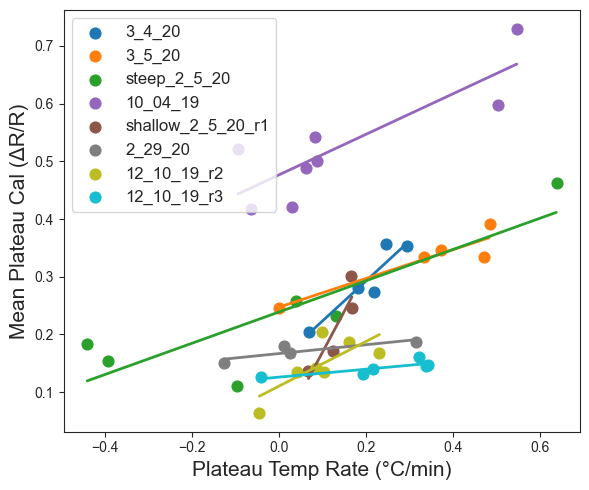

In [44]:
worms = {
    "3_4_20": {
        "x": plateau_temp_rates_steep_3_4_20,
        "y": plateau_mean_cal_steep_3_4_20
    },
    "3_5_20": {
        "x": plateau_temp_rates_steep_3_5_20,
        "y": plateau_mean_cal_steep_3_5_20
    },
    "steep_2_5_20": {
        "x": plateau_temp_rates_steep_2_5_20,
        "y": plateau_mean_cal_steep_2_5_20
    },
    "10_04_19": {
        "x": plateau_temp_rates_steep_10_04_19,
        "y": plateau_mean_cal_steep_10_04_19
    },
    "shallow_2_5_20_r1": {
        "x": plateau_temp_rates_shallow_2_5_20_r1,
        "y": plateau_mean_cal_shallow_2_5_20_r1
    },
    "2_29_20": {
        "x": plateau_temp_rates_shallow_2_29_20,
        "y": plateau_mean_cal_shallow_2_29_20
    },
    "12_10_19_r2": {
        "x": plateau_temp_rates_shallow_12_10_19__r2,
        "y": plateau_mean_cal_shallow_12_10_19__r2
    },
    "12_10_19_r3": {
        "x": plateau_temp_rates_shallow_12_10_19__r3,
        "y": plateau_mean_cal_shallow_12_10_19__r3
    }
}

df = plot_plateau_population(worms, normalize=None)

In [45]:
#df = plot_plateau_population(worms, normalize=None)

result = run_mixed_effects(
    df,
    predictor="TempRate",
    response="DeltaR_raw",
    random_slope=False
)

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: DeltaR_raw
No. Observations: 45      Method:             REML      
No. Groups:       8       Scale:              0.0021    
Min. group size:  4       Log-Likelihood:     56.1063   
Max. group size:  8       Converged:          Yes       
Mean group size:  5.6                                   
---------------------------------------------------------
            Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept   0.217     0.045  4.860  0.000   0.129   0.304
TempRate    0.279     0.036  7.779  0.000   0.209   0.349
Group Var   0.015     0.196                              


Fixed effects:
Intercept    0.216630
TempRate     0.278956
dtype: float64

P-values:
Intercept    1.172683e-06
TempRate     7.318397e-15
Group Var    9.273261e-02
dtype: float64

Random effects covariance:
          Group
Group  0.015271


## Plateau Amplitude Analysis

In [46]:
# amp function with detrend
import numpy as np

def get_plateau_duration_amplitude(plateaus, Time, DeltaR, amplitude_method="range", detrend=False):
    """
    Calculate plateau durations and amplitudes.

    Parameters
    ----------
    plateaus : list
        List of [start_idx, end_idx] pairs.
    Time : array-like
        Time vector.
    DeltaR : array-like
        ΔR/R trace.
    amplitude_method : str
        "range"      -> (max - min)/2
        "percentile" -> (95th - 5th percentile)/2
    detrend : bool
        If True, removes the linear trend from the segment before 
        calculating amplitude.

    Returns
    -------
    plateau_durations : list
    plateau_amplitudes : list
    """

    plateau_durations = []
    plateau_amplitudes = []

    for p in plateaus:
        start, end = p

        # Calculate duration
        delta_t = Time[end] - Time[start]
        plateau_durations.append(delta_t)

        segment = np.asarray(DeltaR[start:end], dtype=float)

        # Detrend the segment if requested
        if detrend and len(segment) > 1:
            x = np.asarray(Time[start:end], dtype=float)
            x = x - x[0]
            # Fit linear trend (degree 1)
            coeffs = np.polyfit(x, segment, 1)
            trend = np.polyval(coeffs, x)
            segment = segment - trend

        # Calculate Amplitude
        if amplitude_method == "range":
            amp = (np.max(segment) - np.min(segment)) / 2

        elif amplitude_method == "percentile":
            amp = (np.percentile(segment, 95) - 
                   np.percentile(segment, 5)) / 2

        else:
            raise ValueError(
                "amplitude_method must be 'range' or 'percentile'."
            )

        plateau_amplitudes.append(amp)

    return plateau_durations, plateau_amplitudes

In [47]:
plateau_durations_steep_3_4_20, plateau_amplitude_steep_3_4_20 = \
    get_plateau_duration_amplitude(
        plateaus_steep_3_4_20,
        Time_steep_3_4_20,
        DeltaR_steep_3_4_20,
        amplitude_method="range", detrend=True
    )

plateau_durations_steep_3_5_20, plateau_amplitude_steep_3_5_20 = \
    get_plateau_duration_amplitude(
        plateaus_steep_3_5_20,
        Time_steep_3_5_20,
        DeltaR_steep_3_5_20,
        amplitude_method="range", detrend=True
    )

plateau_durations_steep_2_5_20, plateau_amplitude_steep_2_5_20 = \
    get_plateau_duration_amplitude(
        plateaus_steep_2_5_20,
        Time_steep_2_5_20,
        DeltaR_steep_2_5_20,
        amplitude_method="range", detrend=True
    )

plateau_durations_steep_10_04_19, plateau_amplitude_steep_10_04_19 = \
    get_plateau_duration_amplitude(
        plateaus_steep_10_04_19,
        Time_steep_10_04_19,
        DeltaR_steep_10_04_19,
        amplitude_method="range", detrend=True
    )

plateau_durations_shallow_2_5_20_r1, plateau_amplitude_shallow_2_5_20_r1 = \
    get_plateau_duration_amplitude(
        plateaus_shallow_2_5_20_r1,
        Time_shallow_2_5_20_r1,
        DeltaR_shallow_2_5_20_r1,
        amplitude_method="range", detrend=True
    )

plateau_durations_shallow_2_29_20, plateau_amplitude_shallow_2_29_20 = \
    get_plateau_duration_amplitude(
        plateaus_shallow_2_29_20,
        Time_shallow_2_29_20,
        DeltaR_shallow_2_29_20,
        amplitude_method="range", detrend=True
    )

plateau_durations_shallow_12_10_19__r2, plateau_amplitude_shallow_12_10_19__r2 = \
    get_plateau_duration_amplitude(
        plateaus_shallow_12_10_19__r2,
        Time_shallow_12_10_19__r2,
        DeltaR_shallow_12_10_19__r2,
        amplitude_method="range", detrend=True
    )

plateau_durations_shallow_12_10_19__r3, plateau_amplitude_shallow_12_10_19__r3 = \
    get_plateau_duration_amplitude(
        plateaus_shallow_12_10_19__r3,
        Time_shallow_12_10_19__r3,
        DeltaR_shallow_12_10_19__r3,
        amplitude_method="range", detrend=True
    )

In [48]:

def plot_amplitude_population(datasets):
    """
    Parameters
    ----------
    datasets : dict

    Format:
    datasets = {
        "Animal1": {
            "mean": plateau_mean_cal_...,
            "amp": plateau_amplitude_...
        },
        ...
    }

    Returns
    -------
    df : pandas.DataFrame
        Columns:
            Worm
            MeanPlateau
            Amplitude
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.metrics import r2_score

    rows = []

    plt.clf()
    fig, ax = plt.subplots(figsize=(6,5))

    colors = plt.cm.tab10(np.linspace(0,1,len(datasets)))

    for color, (animal, dat) in zip(colors, datasets.items()):

        x = np.asarray(dat["mean"])
        y = np.asarray(dat["amp"])

        # Store for mixed-effects model
        for xi, yi in zip(x, y):

            rows.append({
                "Worm": animal,
                "MeanPlateau": xi,
                "Amplitude": yi
            })

        # Scatter
        ax.scatter(
            x,
            y,
            color=color,
            s=60,
            label=animal
        )

        # Need at least two points to fit
        if len(x) >= 2:

            model = np.polyfit(x, y, 1)
            predict = np.poly1d(model)

            r2 = r2_score(y, predict(x))

            print(f"\n{animal}")
            print(f"  Slope     = {model[0]:.4f}")
            print(f"  Intercept = {model[1]:.4f}")
            print(f"  R²        = {r2:.4f}")

            x_fit = np.linspace(np.min(x), np.max(x), 100)

            ax.plot(
                x_fit,
                predict(x_fit),
                color=color,
                lw=2
            )

    ax.legend(fontsize=12)
    ax.tick_params(axis='both', labelsize=15)

    ax.set_ylabel(
        'Plateau Cal Amplitude (ΔR/R)',
        fontsize=15
    )

    ax.set_xlabel(
        'Mean Plateau Cal (ΔR/R)',
        fontsize=15
    )

    plt.tight_layout()
    plt.savefig('Combined_All_Plats_Amps_vs_AvgCa.svg', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

    df = pd.DataFrame(rows)

    return df


3_4_20
  Slope     = -0.0574
  Intercept = 0.0549
  R²        = 0.2746

3_5_20
  Slope     = 0.3864
  Intercept = -0.0544
  R²        = 0.2091

steep_2_5_20
  Slope     = -0.0344
  Intercept = 0.0213
  R²        = 0.2052

10_04_19
  Slope     = 0.0959
  Intercept = 0.1998
  R²        = 0.0089

shallow_2_5_20_r1
  Slope     = -0.0771
  Intercept = 0.0687
  R²        = 0.5500

2_29_20
  Slope     = -0.0799
  Intercept = 0.0309
  R²        = 0.0242

12_10_19_r2
  Slope     = 0.1269
  Intercept = -0.0007
  R²        = 0.2386

12_10_19_r3
  Slope     = -0.2015
  Intercept = 0.0380
  R²        = 0.1107


<Figure size 640x480 with 0 Axes>

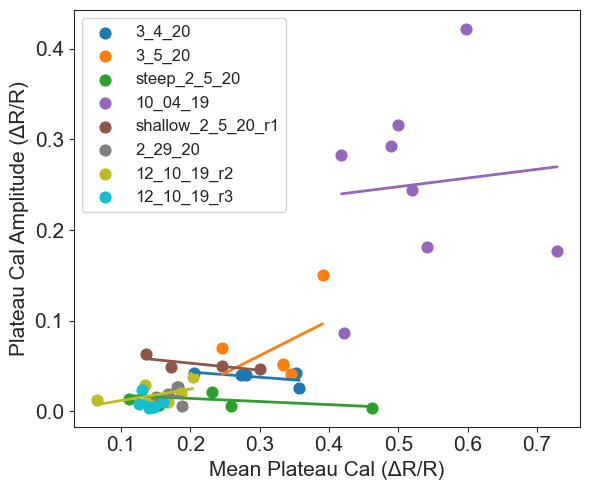

In [49]:
datasets = {
    "3_4_20": {
        "mean": plateau_mean_cal_steep_3_4_20,
        "amp": plateau_amplitude_steep_3_4_20
    },
    "3_5_20": {
        "mean": plateau_mean_cal_steep_3_5_20,
        "amp": plateau_amplitude_steep_3_5_20
    },
    "steep_2_5_20": {
        "mean": plateau_mean_cal_steep_2_5_20,
        "amp": plateau_amplitude_steep_2_5_20
    },
    "10_04_19": {
        "mean": plateau_mean_cal_steep_10_04_19,
        "amp": plateau_amplitude_steep_10_04_19
    },
    "shallow_2_5_20_r1": {
        "mean": plateau_mean_cal_shallow_2_5_20_r1,
        "amp": plateau_amplitude_shallow_2_5_20_r1
    },
    "2_29_20": {
        "mean": plateau_mean_cal_shallow_2_29_20,
        "amp": plateau_amplitude_shallow_2_29_20
    },
    "12_10_19_r2": {
        "mean": plateau_mean_cal_shallow_12_10_19__r2,
        "amp": plateau_amplitude_shallow_12_10_19__r2
    },
    "12_10_19_r3": {
        "mean": plateau_mean_cal_shallow_12_10_19__r3,
        "amp": plateau_amplitude_shallow_12_10_19__r3
    }
}

df = plot_amplitude_population(datasets)

In [50]:
run_mixed_effects(
    df,
    predictor="MeanPlateau",
    response="Amplitude",
    random_slope=False
)

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Amplitude
No. Observations: 45      Method:             REML     
No. Groups:       8       Scale:              0.0024   
Min. group size:  4       Log-Likelihood:     59.7247  
Max. group size:  8       Converged:          Yes      
Mean group size:  5.6                                  
-------------------------------------------------------
               Coef. Std.Err.   z   P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept      0.013    0.039 0.343 0.732 -0.063  0.089
MeanPlateau    0.180    0.124 1.453 0.146 -0.063  0.423
Group Var      0.003    0.060                          


Fixed effects:
Intercept      0.013277
MeanPlateau    0.180142
dtype: float64

P-values:
Intercept      0.731515
MeanPlateau    0.146213
Group Var      0.236880
dtype: float64

Random effects covariance:
          Group
Group  0.003482


In [51]:
# Combine all animals

combined_plateau_mean_cal = (
    plateau_mean_cal_steep_3_4_20 +
    plateau_mean_cal_steep_3_5_20 +
    plateau_mean_cal_steep_2_5_20 +
    plateau_mean_cal_steep_10_04_19 +
    plateau_mean_cal_shallow_2_5_20_r1 +
    plateau_mean_cal_shallow_2_29_20 +
    plateau_mean_cal_shallow_12_10_19__r2 +
    plateau_mean_cal_shallow_12_10_19__r3
) 

combined_plateau_amplitude_cal = (
    plateau_amplitude_steep_3_4_20 +
    plateau_amplitude_steep_3_5_20 +
    plateau_amplitude_steep_2_5_20 +
    plateau_amplitude_steep_10_04_19 +
    plateau_amplitude_shallow_2_5_20_r1 +
    plateau_amplitude_shallow_2_29_20 +
    plateau_amplitude_shallow_12_10_19__r2 +
    plateau_amplitude_shallow_12_10_19__r3
)

combined_plateau_temp_rates = (
    plateau_temp_rates_steep_3_4_20 +
    plateau_temp_rates_steep_3_5_20 +
    plateau_temp_rates_steep_2_5_20 +
    plateau_temp_rates_steep_10_04_19 +
    plateau_temp_rates_shallow_2_5_20_r1 +
    plateau_temp_rates_shallow_2_29_20 +
    plateau_temp_rates_shallow_12_10_19__r2 +
    plateau_temp_rates_shallow_12_10_19__r3
)

import numpy as np

thresh_deriv_based = np.median(combined_plateau_temp_rates)
thresh_mean_based = np.median(combined_plateau_mean_cal)

amps = np.array(combined_plateau_amplitude_cal)
derivs = np.array(combined_plateau_temp_rates)
means = np.array(combined_plateau_mean_cal)

intermediate_mask_deriv_based = derivs <= thresh_deriv_based
high_mask_deriv_based = derivs > thresh_deriv_based

intermediate_mask_mean_based = means <= thresh_mean_based
high_mask_mean_based = means > thresh_mean_based

intermediate_amplitudes_deriv_based = amps[intermediate_mask_deriv_based].tolist()
high_amplitudes_deriv_based = amps[high_mask_deriv_based].tolist()

intermediate_amplitudes_mean_based = amps[intermediate_mask_mean_based].tolist()
high_amplitudes_mean_based = amps[high_mask_mean_based].tolist()

print("Deriv Threshold =", thresh_deriv_based)
print("Intermediate-derivative amplitudes:", intermediate_amplitudes_deriv_based)
print("High-derivative amplitudes:", high_amplitudes_deriv_based)

Deriv Threshold = 0.12444012479591393
Intermediate-derivative amplitudes: [0.042025159400485124, 0.07009531914145715, 0.0056437098135692365, 0.027156634397849114, 0.007065935799286868, 0.014156934068450144, 0.1810606940493796, 0.3160251428225628, 0.0861591289792116, 0.29313185322619506, 0.28316903496648205, 0.24456836888117947, 0.06359007427136648, 0.048516944463243755, 0.019759758435598435, 0.026872194804562585, 0.015607112861644873, 0.0090449469318577, 0.006696493903274023, 0.02925824292378803, 0.03789354929130094, 0.012538972733667223, 0.008426255956305653]
High-derivative amplitudes: [0.025830334932990584, 0.03972233389218223, 0.040203585189601876, 0.04255521749893246, 0.05157033980577602, 0.05192987001908153, 0.15063113640411116, 0.04142117314571589, 0.02143760016290254, 0.004061708725788871, 0.42170907529094437, 0.17734843180114035, 0.04694832307113883, 0.04966981639219613, 0.006486151014467881, 0.02082414062363938, 0.010272589807172633, 0.0042629981081948876, 0.00440855116327670

In [52]:
# All COMBINED - Amplitude VS Deriv

combined_plateau_temp_rates = (
    plateau_temp_rates_steep_3_4_20 +
    plateau_temp_rates_steep_3_5_20 +
    plateau_temp_rates_steep_2_5_20 +
    plateau_temp_rates_steep_10_04_19 +
    plateau_temp_rates_shallow_2_5_20_r1 +
    plateau_temp_rates_shallow_2_29_20 +
    plateau_temp_rates_shallow_12_10_19__r2 +
    plateau_temp_rates_shallow_12_10_19__r3
)

combined_plateau_amplitude_cal = (
    plateau_amplitude_steep_3_4_20 +
    plateau_amplitude_steep_3_5_20 +
    plateau_amplitude_steep_2_5_20 +
    plateau_amplitude_steep_10_04_19 +
    plateau_amplitude_shallow_2_5_20_r1 +
    plateau_amplitude_shallow_2_29_20 +
    plateau_amplitude_shallow_12_10_19__r2 +
    plateau_amplitude_shallow_12_10_19__r3
)

combined_plateau_durations = (
    plateau_durations_steep_3_4_20 +
    plateau_durations_steep_3_5_20 +
    plateau_durations_steep_2_5_20 +
    plateau_durations_steep_10_04_19 +
    plateau_durations_shallow_2_5_20_r1 +
    plateau_durations_shallow_2_29_20 +
    plateau_durations_shallow_12_10_19__r2 +
    plateau_durations_shallow_12_10_19__r3
)

# These printed values are plugged into Prism for final graphing,
# see the file "Plateau Duration"

print("These are the plateau time durations (s):", combined_plateau_durations)

These are the plateau time durations (s): [12.616, 48.260000000000005, 30.44199999999995, 33.58499999999998, 43.212000000000046, 69.284, 29.805999999999926, 40.8069999999999, 41.62799999999993, 32.86000000000013, 6.913999999999994, 15.240000000000002, 7.5120000000000005, 10.914999999999992, 15.659999999999997, 37.40300000000002, 19.62700000000001, 52.10300000000001, 16.549000000000007, 25.751000000000033, 33.73000000000002, 37.625, 11.925999999999988, 5.708000000000084, 36.02799999999999, 35.096000000000004, 64.9029999999999, 46.88300000000004, 23.741000000000003, 59.06899999999999, 16.171999999999997, 6.170999999999992, 12.956999999999999, 12.387, 9.256, 13.763000000000005, 18.224999999999994, 40.381, 22.801999999999964, 8.893, 7.150999999999996, 4.626999999999995, 12.668999999999997, 28.06099999999998, 11.695999999999998]


# Calc AVG Resp Function & Fitting Exponential 

In [30]:
def calc_temp_deriv(experiment_Time, experiment_Temp):
    step = 10

    Temp_downsamp = [experiment_Temp[0]]
    Time_downsamp = [experiment_Time[0]]
    for i in range(step+1,len(experiment_Temp),step):
        Temp_downsamp.append(experiment_Temp[i])
        Time_downsamp.append(experiment_Time[i])

    temp_deriv_downsamp = np.append([0], np.diff(Temp_downsamp))
    temp_deriv_downsamp_per_sec = [0]
    for i in range(1, len(temp_deriv_downsamp)):
        temp_deriv_downsamp_per_sec.append(temp_deriv_downsamp[i]/(Time_downsamp[i]-Time_downsamp[i-1]))

    temp_deriv_downsamp_per_sec_interp = [temp_deriv_downsamp_per_sec[0]]
    for i in range(1,len(temp_deriv_downsamp_per_sec)):
        for j in range(step):
            temp_deriv_downsamp_per_sec_interp.append(temp_deriv_downsamp_per_sec[i-1]+((temp_deriv_downsamp_per_sec[i]-temp_deriv_downsamp_per_sec[i-1])/step)*j)
    final_temp_deriv_downsamp_per_sec = temp_deriv_downsamp_per_sec[len(temp_deriv_downsamp_per_sec)-1]
    dum = temp_deriv_downsamp_per_sec_interp[len(temp_deriv_downsamp_per_sec_interp)-1]
    add_step = (final_temp_deriv_downsamp_per_sec - dum)/(len(temp_deriv_downsamp_per_sec)-max(range(step+1,len(temp_deriv_downsamp_per_sec),step)))
    for i in range((len(experiment_Temp)-max(range(step+1,len(experiment_Temp),step)))):
        dum += add_step
        temp_deriv_downsamp_per_sec_interp.append(dum)
        
    return temp_deriv_downsamp_per_sec_interp

In [31]:
# GLM function replacing the matlab calls with numpy commands

def calc_plot_GLM_tempDeriv_nonzero(experiment_DeltaR, experiment_Time, experiment_Temp, experiment_Temp_Deriv, model_plot, rep_name, stim_window , plt_resp, step = 10 ):
    try:
        #stim_window = 1000 #tenths of seconds
        #step = 1 #interval of modeled data
        responses = []
        stimuli = []
        times = []
        times_b4Resp = []
        
        for i in range(stim_window,len(experiment_DeltaR)):
            responses.append(float(experiment_DeltaR[i]))
            dum = []
            dum_times = []
            dum_times_b4Resp = [] #read as "time bofore th current response"
            
            for j in range((i-stim_window),i,step):
                if float(experiment_Temp_Deriv[j]) > 0.0000001:
                    dum.append(float(experiment_Temp_Deriv[j]))
                else:
                    dum.append(0.0)
                dum_times.append(float(experiment_Time[j])-float(experiment_Time[(i-stim_window)]))
                dum_times_b4Resp.append( float(experiment_Time[i]) - float(experiment_Time[j]) )
            stimuli.append(dum)
            times.append(dum_times)
            times_b4Resp.append(dum_times_b4Resp)

        np_stim = np.array(stimuli)
        np_resp = np.array(responses).reshape(-1, 1)

        solution_vector = np.linalg.lstsq(np_stim, np_resp, rcond=None)[0]
        resp_function = solution_vector.flatten().tolist()

        resp_function_reverse = []
        resp_function_forward = []
        resp_function_seconds = []
        resp_function_seconds_b4Resp = []
        
        for i in range( len(resp_function) ):
            resp_function_reverse.append( float(resp_function[ ( len(resp_function)-i-1 ) ] ) )
            resp_function_forward.append( float(resp_function[i]) )
            
            dum_times = []
            dum_times_b4Resp = []
            for j in range(len(times)):
                dum_times.append(times[j][i])
                dum_times_b4Resp.append(times_b4Resp[j][i])
            resp_function_seconds.append(np.mean(dum_times))
            resp_function_seconds_b4Resp.append(np.mean(dum_times_b4Resp))
            
        resp_function_seconds_rev = []
        resp_function_seconds_b4Resp_rev = []
        for i in range(len(resp_function_seconds)):
            resp_function_seconds_rev.append(float(resp_function_seconds[(len(resp_function_seconds) - i - 1)]))
            resp_function_seconds_b4Resp_rev.append(float(resp_function_seconds_b4Resp[(len(resp_function_seconds_b4Resp) - i - 1)]))
            
            
        resp_function_reverse = np.array(resp_function_reverse).reshape(-1,1)
        resp_function_forward = np.array(resp_function_forward).reshape(-1,1)
        if plt_resp == True:
            
            plt.clf()
            plt.figure(figsize=(3,3), dpi=300)
            plt.plot(resp_function_seconds_b4Resp_rev,resp_function_reverse)
            plt.xlabel('Time Before Response (s)')
            plt.ylabel('Arbitrary Units')
            plt.title(rep_name)
            plt.tight_layout()
            plt.show()
            plt.close()
        
        try:
            modeled_afd_response = []
            for i in range(stim_window,len(experiment_DeltaR)):
                dum = []
                for j in range((i-stim_window),i,step):
                    if float(experiment_Temp_Deriv[j]) > 0.0000001:
                        dum.append(float(experiment_Temp_Deriv[j]))
                    else:
                        dum.append(0.0)
                dum_array = np.array(dum)
                modeled_afd_response.append(float(np.matmul(dum_array,resp_function_forward)))
        except Exception as e:
            print(f"Couldn't model responses where stim_window={stim_window}: ", e)
            
        if model_plot == True:    
            plt.clf()
            plt.figure(figsize=(5,4),dpi=300)#plt.ylim(0,1)
            ax1 = plt.subplot(1,1,1)
            ax1.plot(experiment_Time, experiment_Temp, 'k', lw=2)
            ax1.legend(labels=['Temp.'], fontsize=12, frameon=False)
            ax1.set_ylabel('Temperature (deg C)', fontsize=15)
            ax1.set_xlabel('Time (s)', fontsize=15)
            ax1.set_ylim(min(experiment_Temp),max(experiment_Temp))
            ax1.set_xlim(0, max(experiment_Time))
            ax1.tick_params(axis = 'both', labelsize=15)
            ax2 = ax1.twinx()
            ax2.plot(experiment_Time[stim_window:],experiment_DeltaR[stim_window:], 'r', lw=2)
            ax2.plot(experiment_Time[stim_window:],modeled_afd_response, 'b', lw=2)
            ax2.legend(labels=['Real AFD Activity', 'Model Prediction'], fontsize=12, loc='upper center', frameon=False)
            ax2.set_ylabel('AFD GCaMP Signal (delta R/R)', fontsize=15)
            ax2.set_xlabel('Time (s)', fontsize=15)
            ax2.set_ylim(0,0.6)
            ax2.set_xlim(0, max(experiment_Time))
            ax2.tick_params(axis = 'both', labelsize=15)
            plt.show()
            plt.close()

        #print(modeled_afd_response)
        #print('Pearson R', pearsonr(experiment_DeltaR[stim_window:],modeled_afd_response)[0])    
        #print('MSE', mean_squared_error(experiment_DeltaR[stim_window:],modeled_afd_response))
    except Exception as e:
        print(f"GLM Function failed with stim window: {stim_window}:", e)
    return(modeled_afd_response, resp_function_forward, resp_function_seconds_b4Resp, pearsonr(experiment_DeltaR[stim_window:],modeled_afd_response)[0], mean_squared_error(experiment_DeltaR[stim_window:],modeled_afd_response))

In [32]:
temp_deriv_steep_3_4_20 = calc_temp_deriv(Time_steep_3_4_20, Temp_steep_3_4_20 )
temp_deriv_steep_3_5_20 = calc_temp_deriv(Time_steep_3_5_20, Temp_steep_3_5_20 )
temp_deriv_shallow_2_5_20_r1 = calc_temp_deriv(Time_shallow_2_5_20_r1, Temp_shallow_2_5_20_r1 )
window=1250
model_plot = False
Steep_3_4_20_GLM_Model, Steep_3_4_20_GLM_Resp_Fun, Steep_3_4_20_RespFunct_timeb4resp, Steep_3_4_20_GLM_Model_Corr, Steep_3_4_20_GLM_Model_MSE = calc_plot_GLM_tempDeriv_nonzero(DeltaR_steep_3_4_20, Time_steep_3_4_20, Temp_steep_3_4_20, temp_deriv_steep_3_4_20, model_plot, rep_name = 'Steep 3_4_20', stim_window = window, plt_resp = False)
Steep_3_5_20_GLM_Model, Steep_3_5_20_GLM_Resp_Fun, Steep_3_5_20_RespFunct_timeb4resp, Steep_3_5_20_GLM_Model_Corr, Steep_3_5_20_GLM_Model_MSE = calc_plot_GLM_tempDeriv_nonzero(DeltaR_steep_3_5_20, Time_steep_3_5_20, Temp_steep_3_5_20, temp_deriv_steep_3_5_20, model_plot, rep_name = 'Steep 3_5_20', stim_window = window, plt_resp = False)
Shallow_2_5_20_r1_GLM_Model, Shallow_2_5_20_r1_GLM_Resp_Fun, Shallow_2_5_20_r1_RespFunct_timeb4resp, Shallow_2_5_20_r1_GLM_Model_Corr, Shallow_2_5_20_r1_GLM_Model_MSE = calc_plot_GLM_tempDeriv_nonzero(DeltaR_shallow_2_5_20_r1, Time_shallow_2_5_20_r1, Temp_shallow_2_5_20_r1, temp_deriv_shallow_2_5_20_r1, model_plot, rep_name = 'Shallow 2_5_20_r1', stim_window = window, plt_resp = False)


<Figure size 640x480 with 0 Axes>

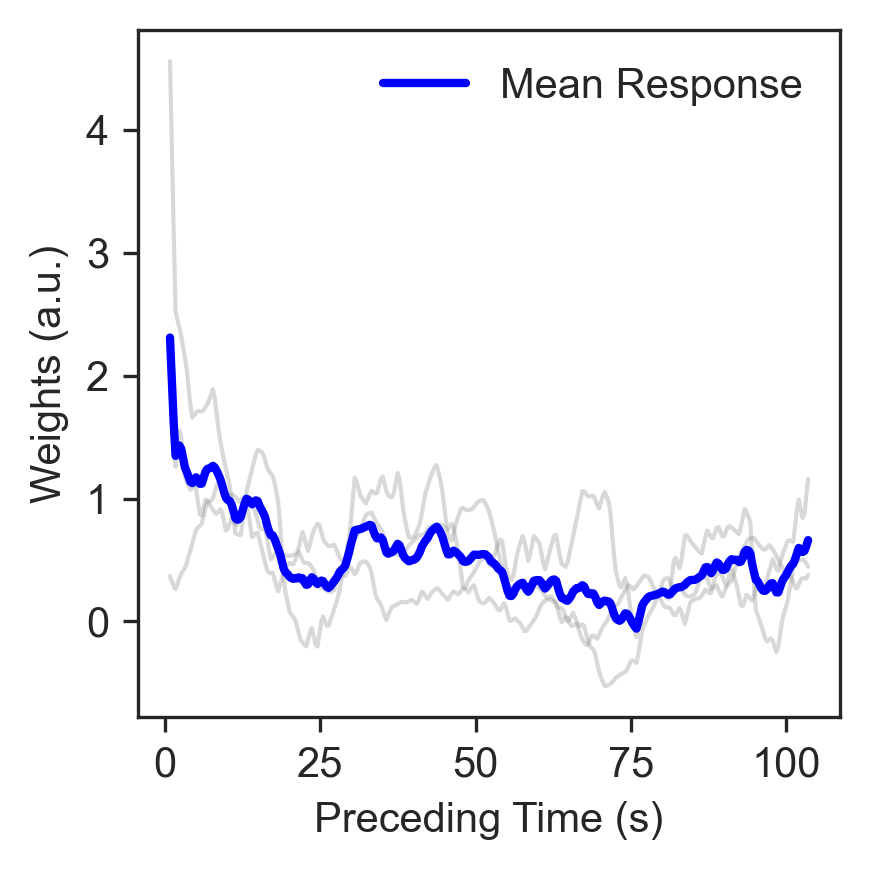

In [33]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Unpack results from your calc_plot_GLM_tempDeriv_nonzero calls
# Each gives: Model, Resp_Fun, RespFunct_timeb4resp, Corr, MSE
experiments = [
    (np.ravel( Steep_3_4_20_GLM_Resp_Fun ), Steep_3_4_20_RespFunct_timeb4resp),
    (np.ravel( Steep_3_5_20_GLM_Resp_Fun ), Steep_3_5_20_RespFunct_timeb4resp),
    (np.ravel( Shallow_2_5_20_r1_GLM_Resp_Fun ), Shallow_2_5_20_r1_RespFunct_timeb4resp)
]

# 1. Define a common time grid (seconds before response)
#    Use the min/max of your time arrays to avoid extrapolation too far
t_min = max([min(t) for _, t in experiments])   # safest common lower bound
t_max = min([max(t) for _, t in experiments])   # safest common upper bound
common_time = np.arange(t_min, t_max, 0.3)      # 0.3 s resolution

# 2. Interpolate each response function onto the common grid
interp_weights = []
for weights, times in experiments:
    f = interp1d(times, weights, kind='linear', bounds_error=False, fill_value="extrapolate")
    interp_weights.append( f(common_time) )

# 3. Average across experiments
average_resp_fun = np.mean(interp_weights, axis=0)

# 4. Plot all individual interpolated curves and the average
plt.clf()
plt.figure(figsize=(3,3), dpi=300)
for curve in interp_weights:
    plt.plot(common_time, curve, color='gray', alpha=0.3, linewidth=1)

plt.plot(common_time, average_resp_fun, color='blue', lw=2, label='Mean Response')

plt.xlabel('Preceding Time (s)')
plt.ylabel('Weights (a.u.)')
plt.legend(frameon=False)
plt.tight_layout()
#plt.savefig('Response_funct_all_expts.svg', dpi=600, bbox_inches='tight') 
plt.show()
plt.close()



In [34]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def expDecayFit_notForced(x, y):
    # --- model: single exponential, no offset ---
    def exp_decay(x, A, B):
        return A * np.exp(-B * x)

    # --- robust initial guesses ---
    # amplitude guess: use first point, or max if that seems safer
    if y.size == 0:
        raise ValueError("y is empty")
    A0 = float(y[0]) if np.isfinite(y[0]) else float(np.nanmax(y))
    # if A0 is negative (rare for weights), use max absolute value
    if A0 <= 0:
        # try using max positive value
        pos = y[y > 0]
        if pos.size:
            A0 = float(np.max(pos))
        else:
            # absolute fallback
            A0 = float(np.abs(np.min(y)) + 1e-6)

    # decay-rate guess B0: fit a line to log(y) on positive points if possible
    B0 = 0.1  # fallback
    mask_pos = (y > 0) & np.isfinite(y) & np.isfinite(x)
    if mask_pos.sum() >= 2:
        try:
            # linear fit to ln(y) vs x -> slope ~ -B
            m, c = np.polyfit(x[mask_pos], np.log(y[mask_pos]), 1)
            B0_candidate = -m
            if B0_candidate > 0:
                B0 = float(B0_candidate)
        except Exception:
            pass
    else:
        # as fallback, estimate from first drop if possible
        if np.isfinite(x[-1]) and (x[-1] - x[0]) > 0 and y[0] > 0:
            # crude estimate: assume y_end ~ y0 * exp(-B * T) -> B ~ -ln(y_end/y0)/T
            if y[-1] > 0 and y[-1] < y[0]:
                B0_try = -np.log(y[-1] / y[0]) / (x[-1] - x[0])
                if B0_try > 0:
                    B0 = float(B0_try)

    p0 = [A0, B0]

    # --- bounds: require non-negative amplitude and decay (you can relax B lower bound to small positive) ---
    lower_bounds = [0.0, 0.0]
    upper_bounds = [np.inf, np.inf]

    # --- fit with bounds (TRF solver used if bounds provided) ---
    try:
        popt, pcov = curve_fit(exp_decay, x, y, p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=1000000)
    except Exception as e:
        # fallback: try unconstrained fit (LM) with p0
        try:
            popt, pcov = curve_fit(exp_decay, x, y, p0=p0, maxfev=1000000)
        except Exception as e2:
            raise RuntimeError("Exponential fit failed (both bounded and unconstrained)."
                            f" Last error: {e2}") from e2

    A_fit, B_fit = popt
    # covariance might be infinite or returned as inf if fit is poor
    with np.errstate(invalid='ignore'):
        perr = np.sqrt(np.diag(pcov)) if (pcov is not None and np.all(np.isfinite(np.diag(pcov)))) else np.array([np.nan, np.nan])

    # --- goodness-of-fit ---
    y_fit = exp_decay(x, *popt)
    
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # --- Plot ---
    plt.clf()
    plt.figure(figsize=(5,3), dpi=150)
    plt.plot(x, y, '-', color='C0', lw=2, label='Reversed avg response')
    plt.plot(x, y_fit, '--', color='C1', lw=2, label=f'Fit: A·exp(-B x)\nA={A_fit:.4g}±{perr[0]:.4g}, B={B_fit:.4g}±{perr[1]:.4g}\nR²={r2:.3f}')
    plt.xlabel('Lag (s)')
    plt.ylabel('Weights (a.u.)')
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    # --- print results ---
    print(f"A = {A_fit:.6g} ± {perr[0]:.6g}")
    print(f"B = {B_fit:.6g} ± {perr[1]:.6g}")
    print(f"tau = {1/B_fit:.6g} s ± {perr[1]/(B_fit**2):.6g} s")
    print(f"R^2 = {r2:.6g}")
    return y_fit

<Figure size 640x480 with 0 Axes>

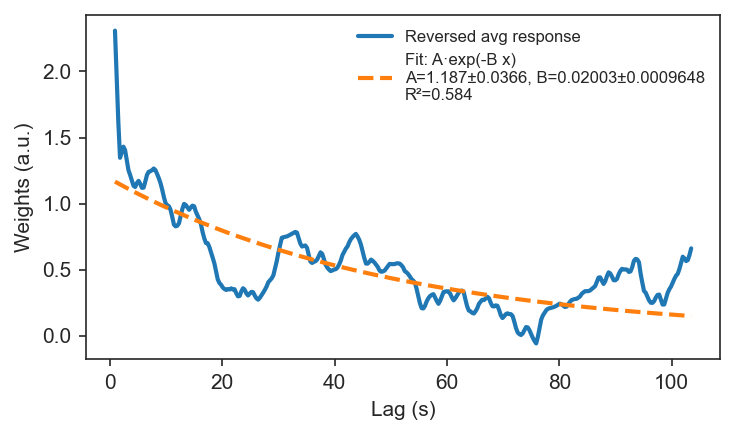

A = 1.187 ± 0.0366
B = 0.0200321 ± 0.000964825
tau = 49.9198 s ± 2.40433 s
R^2 = 0.584337


In [35]:
#AVG Resp Funct Fit
# --- Inputs (replace with your data) ---
# y: 1-D iterable (average response function reversed)
y = np.asarray(list(average_resp_fun), dtype=float)
x = np.asarray(common_time, dtype=float)
avg_fit = expDecayFit_notForced(x, y)


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def expDecayFit_double(x, y):

    # -----------------------------------------------------
    # Double exponential model
    # -----------------------------------------------------
    def exp_decay2(x, A1, B1, A2, B2):
        return A1*np.exp(-B1*x) + A2*np.exp(-B2*x)

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if y.size == 0:
        raise ValueError("y is empty")

    # -----------------------------------------------------
    # Initial guesses
    # -----------------------------------------------------
    A0 = np.max(y)

    p0 = [
        0.7*A0, 0.10,     # fast component
        0.3*A0, 0.01      # slow component
    ]

    lower = [0,0,0,0]
    upper = [np.inf,np.inf,np.inf,np.inf]

    try:
        popt, pcov = curve_fit(
            exp_decay2,
            x,
            y,
            p0=p0,
            bounds=(lower,upper),
            maxfev=100000
        )
    except Exception:
        popt, pcov = curve_fit(
            exp_decay2,
            x,
            y,
            p0=p0,
            maxfev=100000
        )

    A1,B1,A2,B2 = popt

    with np.errstate(invalid='ignore'):
        perr = np.sqrt(np.diag(pcov))

    # -----------------------------------------------------
    # Goodness of fit
    # -----------------------------------------------------
    y_fit = exp_decay2(x,*popt)

    ss_res = np.sum((y-y_fit)**2)
    ss_tot = np.sum((y-np.mean(y))**2)

    r2 = 1 - ss_res/ss_tot

    # -----------------------------------------------------
    # Information criteria
    # -----------------------------------------------------
    n = len(y)
    k = 4

    rss = ss_res

    AIC = n*np.log(rss/n) + 2*k
    BIC = n*np.log(rss/n) + k*np.log(n)

    # -----------------------------------------------------
    # Plot
    # -----------------------------------------------------
    plt.figure(figsize=(5,3),dpi=150)

    plt.plot(x,y,color='C0',lw=2,label='Data')
    plt.plot(
        x,
        y_fit,
        '--',
        color='C1',
        lw=2,
        label=f'Double exponential\nR²={r2:.3f}'
    )

    plt.xlabel("Lag (s)")
    plt.ylabel("Weights (a.u.)")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Print results
    # -----------------------------------------------------

    print("\nFast component")
    print(f"A1   = {A1:.6g} ± {perr[0]:.6g}")
    print(f"B1   = {B1:.6g} ± {perr[1]:.6g}")
    print(f"tau1 = {1/B1:.6g} s")

    print("\nSlow component")
    print(f"A2   = {A2:.6g} ± {perr[2]:.6g}")
    print(f"B2   = {B2:.6g} ± {perr[3]:.6g}")
    print(f"tau2 = {1/B2:.6g} s")

    print("\nGoodness of fit")
    print(f"R²  = {r2:.6f}")
    print(f"AIC = {AIC:.3f}")
    print(f"BIC = {BIC:.3f}")

    return y_fit

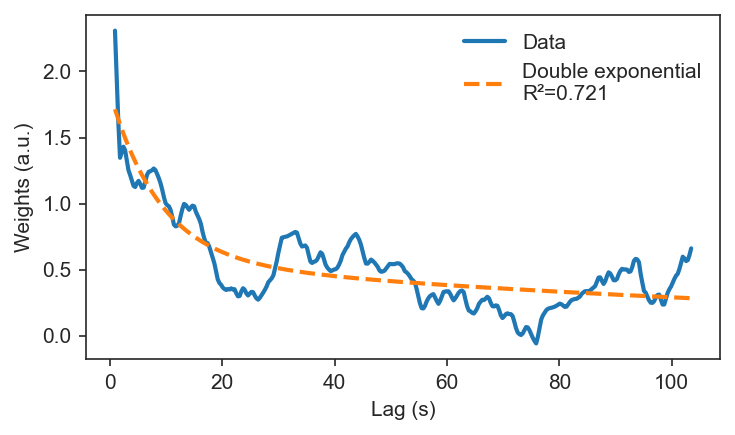


Fast component
A1   = 1.2624 ± 0.0835057
B1   = 0.113174 ± 0.0160872
tau1 = 8.83599 s

Slow component
A2   = 0.574771 ± 0.0652014
B2   = 0.00680685 ± 0.00167426
tau2 = 146.911 s

Goodness of fit
R²  = 0.720744
AIC = -1183.001
BIC = -1167.650


In [37]:
#AVG Resp Funct Fit
# --- Inputs (replace with your data) ---
# y: 1-D iterable (average response function reversed)
y = np.asarray(average_resp_fun, dtype=float)
x = np.asarray(common_time, dtype=float)

double_fit = expDecayFit_double(x, y)



========== SINGLE EXPONENTIAL ==========
A = 1.187 ± 0.0366
B = 0.0200321 ± 0.000964825
tau = 49.9198 s ± 2.40433 s
R² = 0.584337

========== DOUBLE EXPONENTIAL ==========

Fast component
A1   = 1.2624 ± 0.0835057
B1   = 0.113174 ± 0.0160872
tau1 = 8.83599 s

Slow component
A2   = 0.574771 ± 0.0652014
B2   = 0.00680685 ± 0.00167426
tau2 = 146.911 s

Goodness of fit
R²  = 0.720744
AIC = -1183.001
BIC = -1167.650


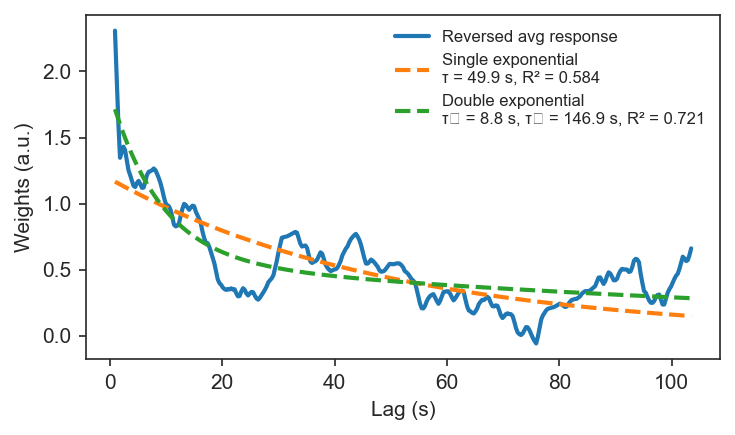

In [38]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ============================================================
# SINGLE EXPONENTIAL FIT
# Exact fitting procedure from expDecayFit_notForced
# ============================================================

def exp_decay_single(x, A, B):
    return A * np.exp(-B * x)


# --- robust initial guesses ---
if y.size == 0:
    raise ValueError("y is empty")

A0 = float(y[0]) if np.isfinite(y[0]) else float(np.nanmax(y))

if A0 <= 0:
    pos = y[y > 0]
    if pos.size:
        A0 = float(np.max(pos))
    else:
        A0 = float(np.abs(np.min(y)) + 1e-6)

B0 = 0.1

mask_pos = (y > 0) & np.isfinite(y) & np.isfinite(x)

if mask_pos.sum() >= 2:
    try:
        m, c = np.polyfit(x[mask_pos], np.log(y[mask_pos]), 1)
        B0_candidate = -m
        if B0_candidate > 0:
            B0 = float(B0_candidate)
    except Exception:
        pass
else:
    if np.isfinite(x[-1]) and (x[-1] - x[0]) > 0 and y[0] > 0:
        if y[-1] > 0 and y[-1] < y[0]:
            B0_try = -np.log(y[-1] / y[0]) / (x[-1] - x[0])
            if B0_try > 0:
                B0 = float(B0_try)

p0_single = [A0, B0]

lower_bounds = [0.0, 0.0]
upper_bounds = [np.inf, np.inf]

try:
    popt_single, pcov_single = curve_fit(
        exp_decay_single,
        x,
        y,
        p0=p0_single,
        bounds=(lower_bounds, upper_bounds),
        maxfev=1000000
    )
except Exception as e:
    try:
        popt_single, pcov_single = curve_fit(
            exp_decay_single,
            x,
            y,
            p0=p0_single,
            maxfev=1000000
        )
    except Exception as e2:
        raise RuntimeError(
            "Exponential fit failed (both bounded and unconstrained)."
            f" Last error: {e2}"
        ) from e2


A_single, B_single = popt_single

with np.errstate(invalid='ignore'):
    perr_single = (
        np.sqrt(np.diag(pcov_single))
        if (
            pcov_single is not None
            and np.all(np.isfinite(np.diag(pcov_single)))
        )
        else np.array([np.nan, np.nan])
    )

y_fit_single = exp_decay_single(x, *popt_single)

ss_res_single = np.sum((y - y_fit_single) ** 2)
ss_tot_single = np.sum((y - np.mean(y)) ** 2)

r2_single = (
    1 - ss_res_single / ss_tot_single
    if ss_tot_single > 0
    else np.nan
)

tau_single = 1 / B_single


# ============================================================
# DOUBLE EXPONENTIAL FIT
# Exact fitting procedure from expDecayFit_double
# ============================================================

def exp_decay_double(x, A1, B1, A2, B2):
    return A1*np.exp(-B1*x) + A2*np.exp(-B2*x)


x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float)

if y.size == 0:
    raise ValueError("y is empty")


# -----------------------------------------------------
# Initial guesses
# -----------------------------------------------------

A0 = np.max(y)

p0_double = [
    0.7*A0, 0.10,     # fast component
    0.3*A0, 0.01      # slow component
]

lower = [0, 0, 0, 0]
upper = [np.inf, np.inf, np.inf, np.inf]

try:
    popt_double, pcov_double = curve_fit(
        exp_decay_double,
        x,
        y,
        p0=p0_double,
        bounds=(lower, upper),
        maxfev=100000
    )
except Exception:
    popt_double, pcov_double = curve_fit(
        exp_decay_double,
        x,
        y,
        p0=p0_double,
        maxfev=100000
    )


A1, B1, A2, B2 = popt_double

with np.errstate(invalid='ignore'):
    perr_double = np.sqrt(np.diag(pcov_double))


# -----------------------------------------------------
# Goodness of fit
# -----------------------------------------------------

y_fit_double = exp_decay_double(x, *popt_double)

ss_res_double = np.sum((y - y_fit_double)**2)
ss_tot_double = np.sum((y - np.mean(y))**2)

r2_double = 1 - ss_res_double/ss_tot_double


# -----------------------------------------------------
# Information criteria
# -----------------------------------------------------

n = len(y)
k = 4

rss = ss_res_double

AIC = n*np.log(rss/n) + 2*k
BIC = n*np.log(rss/n) + k*np.log(n)


# ============================================================
# PRINT FIT RESULTS
# ============================================================

print("\n========== SINGLE EXPONENTIAL ==========")
print(f"A = {A_single:.6g} ± {perr_single[0]:.6g}")
print(f"B = {B_single:.6g} ± {perr_single[1]:.6g}")
print(
    f"tau = {1/B_single:.6g} s ± "
    f"{perr_single[1]/(B_single**2):.6g} s"
)
print(f"R² = {r2_single:.6g}")


print("\n========== DOUBLE EXPONENTIAL ==========")

print("\nFast component")
print(f"A1   = {A1:.6g} ± {perr_double[0]:.6g}")
print(f"B1   = {B1:.6g} ± {perr_double[1]:.6g}")
print(f"tau1 = {1/B1:.6g} s")

print("\nSlow component")
print(f"A2   = {A2:.6g} ± {perr_double[2]:.6g}")
print(f"B2   = {B2:.6g} ± {perr_double[3]:.6g}")
print(f"tau2 = {1/B2:.6g} s")

print("\nGoodness of fit")
print(f"R²  = {r2_double:.6f}")
print(f"AIC = {AIC:.3f}")
print(f"BIC = {BIC:.3f}")


# ============================================================
# OVERLAY PLOT
# ============================================================

plt.figure(figsize=(5, 3), dpi=150)

plt.plot(
    x,
    y,
    '-',
    lw=2,
    label='Reversed avg response'
)

plt.plot(
    x,
    y_fit_single,
    '--',
    lw=2,
    label=(
        f'Single exponential\n'
        f'τ = {tau_single:.1f} s, R² = {r2_single:.3f}'
    )
)

plt.plot(
    x,
    y_fit_double,
    '--',
    lw=2,
    label=(
        f'Double exponential\n'
        f'τ₁ = {1/B1:.1f} s, τ₂ = {1/B2:.1f} s, '
        f'R² = {r2_double:.3f}'
    )
)

plt.xlabel('Lag (s)')
plt.ylabel('Weights (a.u.)')
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# 3_4_20 Plateau Analysis

In [ ]:
def calc_delta_diff(Soma_Ratio_smoothed):
    """
    Returns a list where:
      - output[0] == Soma_Ratio_smoothed[0]
      - for t>0, output[t] = Soma_Ratio_smoothed[t] - Soma_Ratio_smoothed[t-1]
    """
    if len(Soma_Ratio_smoothed) == 0:
        return []

    #Delta = [Soma_Ratio_smoothed[0]]
    Delta = [0]
    for prev, curr in zip(Soma_Ratio_smoothed, Soma_Ratio_smoothed[1:]):
        Delta.append(curr - prev)
    return Delta

def calc_Delta(Soma_Ratio_smoothed):
    Delta_Soma_Ratio_smoothed = []
    rat_min = min(Soma_Ratio_smoothed)
    for i in Soma_Ratio_smoothed:
        Delta_Soma_Ratio_smoothed.append((i-rat_min)/rat_min)
    
    return(Delta_Soma_Ratio_smoothed)

Delta_Soma_Ratio = calc_Delta(Soma_Ratio_3_4_20_unsmoothed)
Soma_Ratio_smoothed = gaussian_filter1d(Soma_Ratio_3_4_20_unsmoothed, sigma=17)
Delta_Soma_Ratio_smoothed = calc_Delta(Soma_Ratio_smoothed)

inst_diff_Ratio = calc_delta_diff(Soma_Ratio_3_4_20_unsmoothed)
inst_diff_Ratio_smoothed = calc_delta_diff(Soma_Ratio_smoothed)
inst_diff_DeltaRatio = calc_delta_diff(Delta_Soma_Ratio)
inst_diff_DeltaRatio_smoothed = calc_delta_diff(Delta_Soma_Ratio_smoothed)

In [ ]:
# Includes representative instantaneous temp deriv value
import numpy as np
from scipy.stats import shapiro
Delta_Soma_Ratio_smoothed = Delta_Soma_Ratio

# — 1) Build plateau_metrics —
plateau_metrics = {}
for idx, (s_i, e_i) in enumerate(plateaus_steep_3_4_20, start=1):
    derivs = [
        dT / dt for dT, dt in zip(
            np.diff(Temp_steep_3_4_20[s_i:e_i]),
            np.diff(Time_steep_3_4_20[s_i:e_i])
        )
    ]
    # normality test
    stat, p_val = shapiro(derivs)  
    if p_val > 0.05:
        repr_deriv = np.mean(derivs)
    else:
        repr_deriv = np.median(derivs)

    plateau_metrics[f"plat_{idx}"] = {
        "Temperature": Temp_steep_3_4_20[s_i:e_i],
        "Xpos": Xcoord_steep_3_4_20[s_i:e_i],
        "Norm_Xpos": Xcoord_Norm_steep_3_4_20[s_i:e_i],
        "Ypos": Ycoord_steep_3_4_20[s_i:e_i],
        "Time": Time_steep_3_4_20[s_i:e_i],
        "Calcium": Delta_Soma_Ratio_smoothed[s_i:e_i],
        "inst_diff_Ca": inst_diff_DeltaRatio[s_i:e_i],
        "deltaT_deltat_min": 60*(Temp_steep_3_4_20[e_i] - Temp_steep_3_4_20[s_i])/(Time_steep_3_4_20[e_i] - Time_steep_3_4_20[s_i]),
        "Mean_Ca": np.mean(Delta_Soma_Ratio_smoothed[s_i:e_i]),
        "diff_T": np.diff(Temp_steep_3_4_20[s_i:e_i]),
        "diff_t": np.diff(Time_steep_3_4_20[s_i:e_i]),
        "inst_Temp_deriv": [0] + derivs,
        "repr_inst_Temp_deriv": repr_deriv,
        "start_ind":   s_i,
        "end_ind":     e_i,
        "start_time":  Time_steep_3_4_20[s_i],
        "end_time":    Time_steep_3_4_20[e_i],
    }

# — 2) Build pos_runs_metrics —
pos_runs_metrics = {}
for idx, run_range in enumerate(run_east_video_steep_3_4_20, start=1):
    raw_s, raw_e = run_range
    s_i, e_i = find_start_stop((raw_s, raw_e,), Frames_steep_3_4_20)

    derivs = [
        dT / dt for dT, dt in zip(
            np.diff(Temp_steep_3_4_20[s_i:e_i]),
            np.diff(Time_steep_3_4_20[s_i:e_i])
        )
    ]
    # normality test
    stat, p_val = shapiro(derivs)
    if p_val > 0.05:
        repr_deriv = np.mean(derivs)
    else:
        repr_deriv = np.median(derivs)

    pos_runs_metrics[f"run_{idx}"] = {
        "Temperature": Temp_steep_3_4_20[s_i:e_i],
        "Xpos": Xcoord_steep_3_4_20[s_i:e_i],
        "Norm_Xpos": Xcoord_Norm_steep_3_4_20[s_i:e_i],
        "Ypos": Ycoord_steep_3_4_20[s_i:e_i],
        "Time": Time_steep_3_4_20[s_i:e_i],
        "Calcium": Delta_Soma_Ratio_smoothed[s_i:e_i],
        "inst_diff_Ca": inst_diff_DeltaRatio[s_i:e_i],
        "deltaT_deltat_min": 60*(Temp_steep_3_4_20[e_i] - Temp_steep_3_4_20[s_i])/(Time_steep_3_4_20[e_i] - Time_steep_3_4_20[s_i]),
        "Mean_Ca": np.mean(Delta_Soma_Ratio_smoothed[s_i:e_i]),
        "diff_T": np.diff(Temp_steep_3_4_20[s_i:e_i]),
        "diff_t": np.diff(Time_steep_3_4_20[s_i:e_i]),
        "inst_Temp_deriv": [0] + derivs,
        "repr_inst_Temp_deriv": repr_deriv,
        "start_ind":   s_i,
        "end_ind":     e_i,
        "start_time":  Time_steep_3_4_20[s_i],
        "end_time":    Time_steep_3_4_20[e_i],
    }

# — 3) Map each plateau to ALL overlapping runs —
plateau_to_runs = {}
for p_key, p in plateau_metrics.items():
    t0_p, t1_p = p["start_time"], p["end_time"]
    overlapping = []
    for r_key, r in pos_runs_metrics.items():
        t0_r, t1_r = r["start_time"], r["end_time"]
        if (t0_p <= t1_r) and (t0_r <= t1_p):
            overlapping.append(r_key)
    plateau_to_runs[p_key] = overlapping

# — 4) Display the mapping and repr_deriv values —
for p_key, runs in plateau_to_runs.items():
    plat_repr = plateau_metrics[p_key]["repr_inst_Temp_deriv"]
    print(f"{p_key}: repr_inst_Temp_deriv = {plat_repr:.3f}", end=" → ")
    if runs:
        run_strs = []
        for r_key in runs:
            r_repr = pos_runs_metrics[r_key]["repr_inst_Temp_deriv"]
            run_strs.append(f"{r_key} (repr={r_repr:.3f})")
        print("overlaps with", ", ".join(run_strs))
    else:
        print("no overlapping runs")


plat_1: repr_inst_Temp_deriv = 0.004 → overlaps with run_2 (repr=0.005), run_3 (repr=0.008)
plat_2: repr_inst_Temp_deriv = 0.004 → overlaps with run_6 (repr=0.007), run_7 (repr=0.008), run_8 (repr=0.007)
plat_3: repr_inst_Temp_deriv = 0.002 → overlaps with run_9 (repr=0.009), run_10 (repr=0.008), run_11 (repr=0.006)
plat_4: repr_inst_Temp_deriv = 0.001 → overlaps with run_13 (repr=-0.005), run_14 (repr=0.002)
plat_5: repr_inst_Temp_deriv = 0.002 → overlaps with run_16 (repr=0.007), run_17 (repr=0.003), run_18 (repr=0.004), run_19 (repr=0.004)


In [ ]:
from scipy.signal import gaussian, filtfilt
smooth_factor = 0
Ca_smooth_factor = 15
M = smooth_factor*6
M_Ca = smooth_factor*6
if M % 2 == 0:
    M = M + 1
if M_Ca % 2 == 0:
    M_Ca = M_Ca + 1
kernel = gaussian(M=M, std=smooth_factor)
kernel_Ca = gaussian(M=M_Ca, std=Ca_smooth_factor)
kernel /= kernel.sum()
kernel_Ca /= kernel_Ca.sum()
run_key = "plat_5" # ~~~~~~~~~~~~~~~~~~~~~~~~~ >>>>>>>>>>>>>>>>>>>>>>>>>>> SPECIFY THE PLATEAU
metrics = plateau_metrics
method_filtfilt = False
time_smooth = "No"
if smooth_factor > 0:
    if method_filtfilt == False:
        T = np.asarray(  gaussian_filter1d(  metrics[run_key]["Temperature"], sigma = smooth_factor  ),  dtype=float)
        Y = np.asarray(  gaussian_filter1d(  metrics[run_key]["Ypos"], sigma = smooth_factor  ),         dtype=float)
        X = np.asarray(  gaussian_filter1d(  metrics[run_key]["Xpos"], sigma = smooth_factor  ),         dtype=float)
        Ca= np.asarray(  gaussian_filter1d(  metrics[run_key]["Calcium"], sigma = Ca_smooth_factor  ),      dtype=float)
        Time = np.asarray(  gaussian_filter1d(  metrics[run_key]["Time"], sigma = smooth_factor  ),      dtype=float)
        Norm_X = np.asarray(  gaussian_filter1d(  metrics[run_key]["Norm_Xpos"], sigma = smooth_factor  ),      dtype=float)
        dCa = np.asarray(  gaussian_filter1d(  metrics[run_key]["inst_diff_Ca"], sigma = smooth_factor  ),      dtype=float)
        dTdt =np.asarray(  gaussian_filter1d(  metrics[run_key]["inst_Temp_deriv"], sigma = smooth_factor  ),      dtype=float)
        dTdt_ofSmf = gaussian_filter1d( [0] + [dT / dt for dT, dt in zip( np.diff(T), np.diff(Time) ) ], sigma = smooth_factor)
    if method_filtfilt == True:
        T = np.asarray(    filtfilt( kernel, [1,0], metrics[run_key]["Temperature"]),  dtype=float)
        Y = np.asarray(    filtfilt( kernel, [1,0], metrics[run_key]["Ypos"]),         dtype=float)
        X = np.asarray(    filtfilt( kernel, [1,0], metrics[run_key]["Xpos"]),         dtype=float)
        Ca= np.asarray(    filtfilt( kernel_Ca, [1,0], metrics[run_key]["Calcium"]),      dtype=float)
        Time = np.asarray(    filtfilt( kernel, [1,0], metrics[run_key]["Time"]),      dtype=float)
        Norm_X = np.asarray(    filtfilt( kernel, [1,0], metrics[run_key]["Norm_Xpos"]),      dtype=float)
        dCa = np.asarray(    filtfilt( kernel, [1,0], metrics[run_key]["inst_diff_Ca"]),      dtype=float) 
        dTdt = np.asarray(    filtfilt( kernel, [1,0], metrics[run_key]["inst_Temp_deriv"]),      dtype=float)
        dTdt_ofSmf = filtfilt( kernel, [1,0], [0] + [dT / dt for dT, dt in zip( np.diff(T), np.diff(Time) ) ] )
else:
    T = np.asarray(   metrics[run_key]["Temperature"] ,  dtype=float)
    Y = np.asarray(   metrics[run_key]["Ypos"] ,         dtype=float)
    X = np.asarray(   metrics[run_key]["Xpos"] ,         dtype=float)
    Ca= np.asarray(   metrics[run_key]["Calcium"] ,      dtype=float)
    Time = np.asarray(   metrics[run_key]["Time"] ,      dtype=float)
    Norm_X = np.asarray(   metrics[run_key]["Norm_Xpos"] ,      dtype=float)
    dCa = np.asarray(   metrics[run_key]["inst_diff_Ca"] ,      dtype=float)
    dTdt = np.asarray(   metrics[run_key]["inst_Temp_deriv"] ,      dtype=float)

if time_smooth == "No":
    Time = np.asarray(   metrics[run_key]["Time"] ,      dtype=float)
# -------------------------------------------------------------------------------------------------------------------------
slope, intercept = np.polyfit(Norm_X, Y, 1)
θ = np.arctan(slope)    # in radians

θ_deg = np.degrees(θ)
γ_deg = 90 - θ_deg
γ = np.radians(90 - θ_deg)
Y_fit = slope * Norm_X + intercept
print(γ_deg)
print(θ_deg)
print( γ_deg + θ_deg )
R = np.array([
    [ np.cos(θ),  np.sin(θ)],
    [-np.sin(θ),  np.cos(θ)]
])
R_vert = np.array([ #Rotates counterclockwise so that track doesnt oscillates along y, but fully on x
    [ np.cos(γ),  -np.sin(γ)],
    [ np.sin(γ),   np.cos(γ)]
])

coords = np.vstack([Norm_X, Y])          # shape (2, N)
x_prime, y_prime = R.dot(coords)    # each is length-N
x_prime_vert, y_prime_vert = R_vert.dot(coords)    # each is length-N

# Vert Rotation Calcium ------------------------------------

slope_Ca, intercept_Ca = np.polyfit(Time, Ca, 1)
θ_Ca = np.arctan(slope_Ca)    # in radians
θ_deg_Ca = np.degrees(θ_Ca)
if θ_deg_Ca < 0:
    γ_deg_Ca = abs(θ_deg_Ca) + 90
    γ_Ca = np.radians(γ_deg_Ca)
else:
    γ_deg_Ca = 90 - θ_deg_Ca 
    γ_Ca = np.radians(γ_deg_Ca)
R_Ca = np.array([
    [ np.cos(γ_Ca),  -np.sin(γ_Ca)],
    [np.sin(γ_Ca),  np.cos(γ_Ca)]
])
coords_Ca = np.vstack([Time, Ca])          # shape (2, N)
x_prime_Ca, y_prime_Ca = R_Ca.dot(coords_Ca)    # each is length-N
print("Now Ca")
print(slope_Ca)
print(θ_deg_Ca)
print(γ_deg_Ca)
print( γ_deg_Ca + θ_deg_Ca )




64.62970777631206
25.37029222368794
90.0
Now Ca
0.001151605486057808
0.06598210484685099
89.93401789515315
90.0


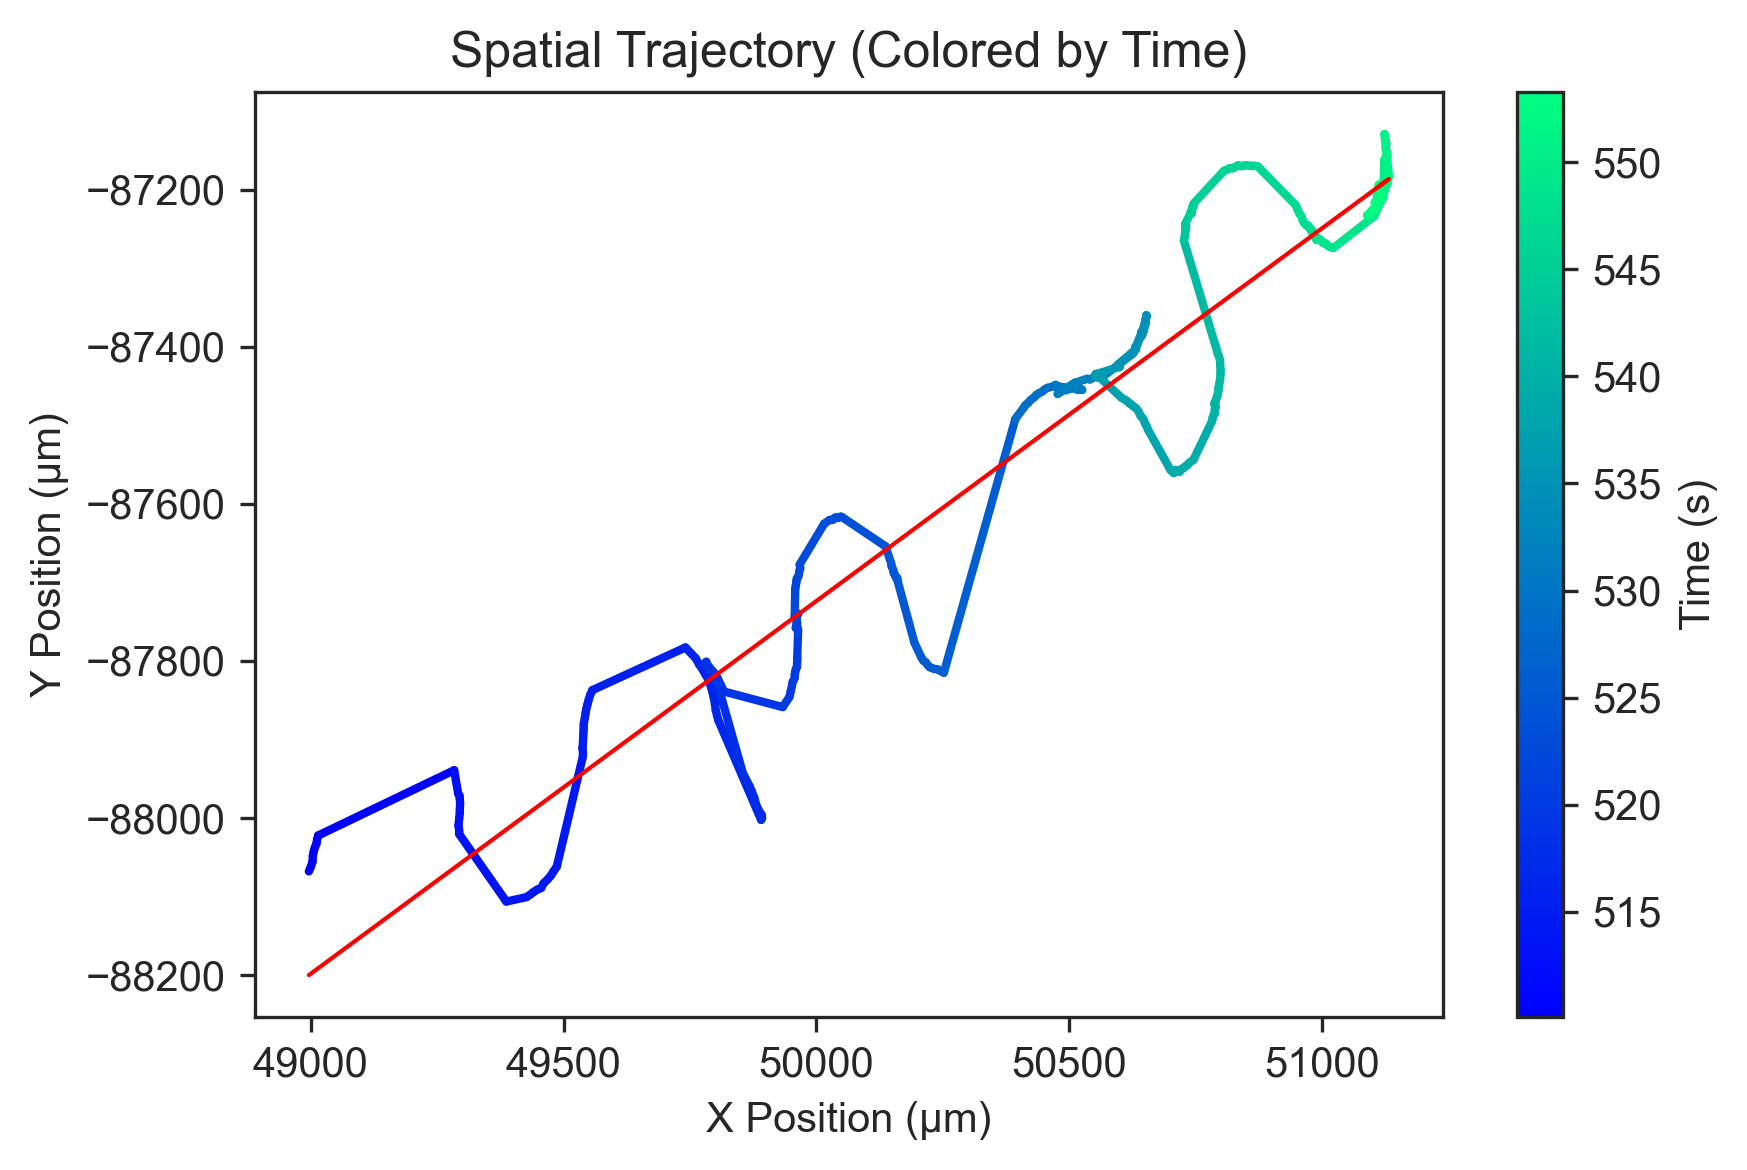

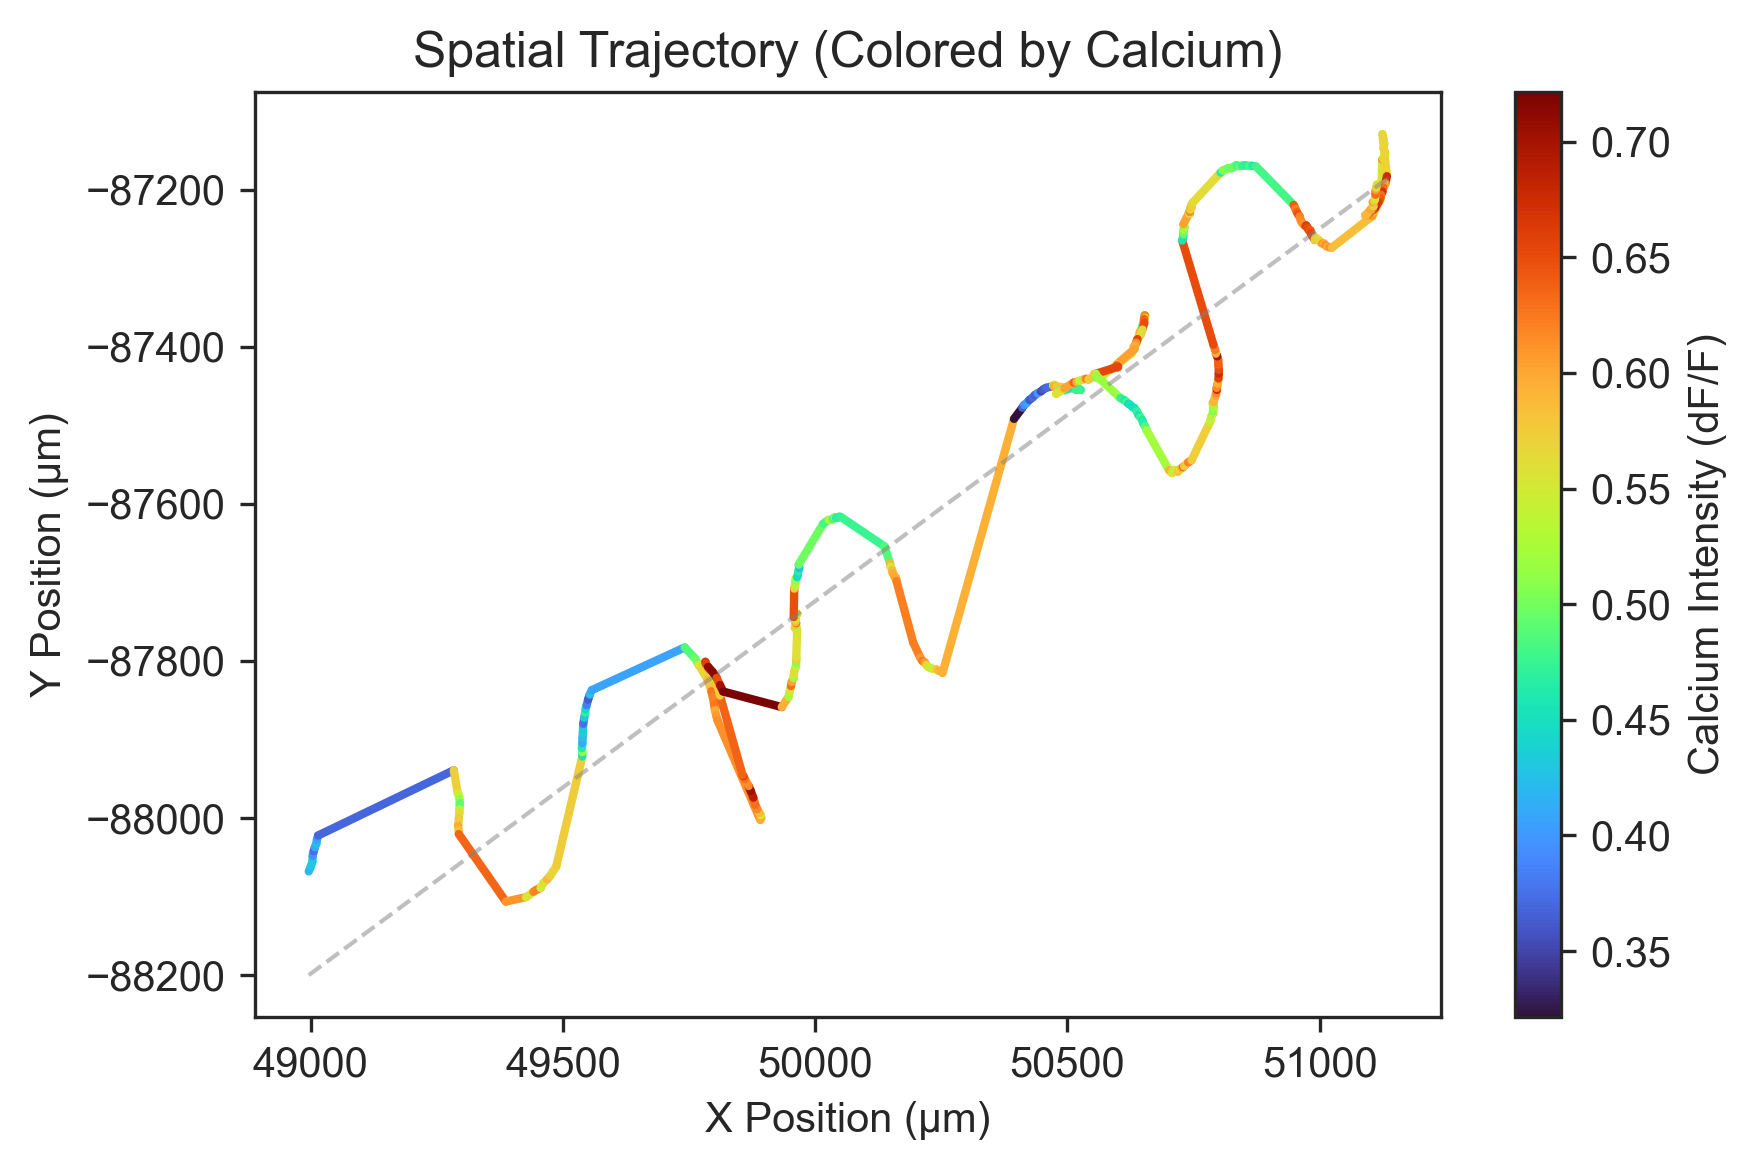

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib as mpl
from scipy.ndimage import gaussian_filter1d

# --- 1. PRE-PROCESSING (Existing) ---
Time_array = np.array(Time)
Cas = Ca

# Create points as a list of (x, y) pairs
points = np.array([x_prime_vert, y_prime_vert]).T.reshape(-1, 1, 2)
points_orig = np.array([Norm_X, Y]).T.reshape(-1, 1, 2)
ca_pts = np.array([Time, Cas]).T.reshape(-1, 1, 2)
Ca_vert_pts = np.array([x_prime_Ca, y_prime_Ca]).T.reshape(-1, 1, 2)

# Create segments for line collection (each segment is a pair of points)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
segments_orig = np.concatenate([points_orig[:-1], points_orig[1:]], axis=1)
segments_Ca = np.concatenate([ca_pts[:-1], ca_pts[1:]], axis=1)
segments_Ca_vert = np.concatenate([Ca_vert_pts[:-1], Ca_vert_pts[1:]], axis=1)

# --- 2. SETUP TIME HEATMAP (Existing) ---
norm_time = Normalize(Time_array.min(), Time_array.max())
cmap_time = plt.get_cmap('winter')

lc_orig = LineCollection(segments_orig, cmap=cmap_time, norm=norm_time)

# Smooth out the Time Plot ---
lc_orig.set_capstyle('round')
lc_orig.set_joinstyle('round')
# ---------------------------------------

lc_orig.set_array(Time_array[:-1])
lc_orig.set_linewidth(2)


# --- 3. SETUP CALCIUM HEATMAP ---
# Normalize Calcium values
norm_ca = Normalize(Cas.min(), Cas.max())
cmap_ca = plt.get_cmap('turbo')  # 'turbo' is best for 0->Max intensity

# Create LineCollection for the Calcium plot using the SAME spatial segments
lc_calcium_spatial = LineCollection(segments_orig, cmap=cmap_ca, norm=norm_ca)

# ---Smooth out the Calcium Plot ---
lc_calcium_spatial.set_capstyle('round')
lc_calcium_spatial.set_joinstyle('round')
# ------------------------------------------

# Set the color-value using the Calcium array (matching segment length)
lc_calcium_spatial.set_array(Cas[:-1])
lc_calcium_spatial.set_linewidth(2)


# --- 4. PLOT 1: TIME HEATMAP ---
fig1, ax1 = plt.subplots(figsize=(6, 4), dpi=300)

ax1.plot(Norm_X, Y, lw=0, alpha=0) # Hidden base plot to set scales automatically
ax1.add_collection(lc_orig)
ax1.plot(Norm_X, Y_fit, c="r", lw=1, label='Fit')

cbar1 = plt.colorbar(lc_orig, ax=ax1, alpha=1.0) 
cbar1.set_label("Time (s)")
ax1.set_ylabel("Y Position (µm)")
ax1.set_xlabel("X Position (µm)")
ax1.set_title("Spatial Trajectory (Colored by Time)")
#plt.savefig('Plat_5_XvsY_wFit_wTimeHeat.svg', dpi=600, bbox_inches='tight')
plt.tight_layout()


# --- 5. PLOT 2: CALCIUM HEATMAP (New) ---
fig2, ax2 = plt.subplots(figsize=(6, 4), dpi=300)

# Same spatial X/Y limits, but color by Calcium
ax2.set_xlim(ax1.get_xlim())
ax2.set_ylim(ax1.get_ylim())

# Add the Calcium collection
ax2.add_collection(lc_calcium_spatial)
ax2.plot(Norm_X, Y_fit, c="gray", lw=1, linestyle='--', alpha=0.5) # Optional: Faint fit line

cbar2 = plt.colorbar(lc_calcium_spatial, ax=ax2, alpha=1.0)
cbar2.set_label("Calcium Intensity (dF/F)")
ax2.set_ylabel("Y Position (µm)")
ax2.set_xlabel("X Position (µm)")
ax2.set_title("Spatial Trajectory (Colored by Calcium)")
plt.tight_layout()
#plt.savefig('Plat_5_XvsY_wFit_wCaHeat.svg', dpi=600, bbox_inches='tight')

plt.show()

Position Model parameters:
  Amplitude         : 154.306
  ω (rad/s)         : 1.40257  (4π/9)
  f (Hz)            : 0.223225
  Phase φ (rad)     : 10.0864  (16π/5)

position model generated
Calcium Model parameters:
  Amplitude         : 0.0962834
  ω (rad/s)         : 1.43518  (5π/11)
  f (Hz)            : 0.228416
  Phase φ (rad)     : -1.38172  (-4π/9)



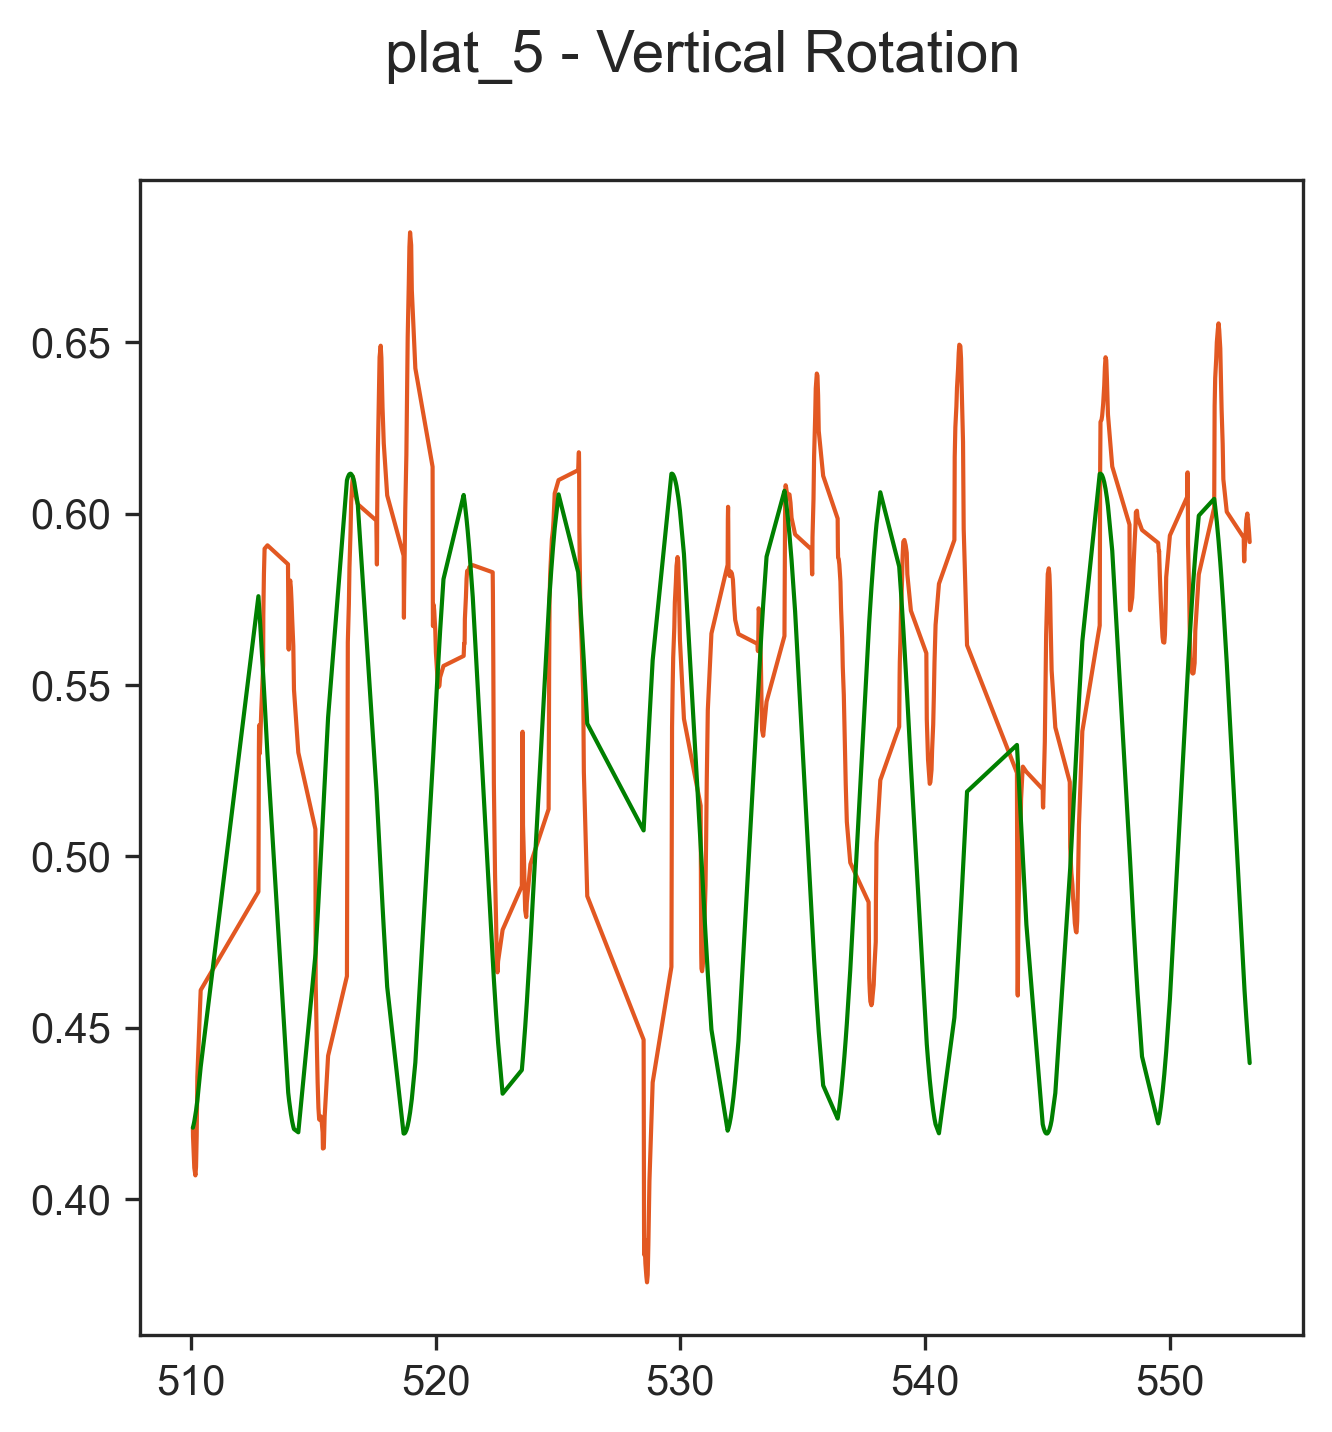


=== Model Comparison for plat_5 ===
Wrapped Position phase   : -2.47996 rad ≈ -4π/5
Wrapped Calcium phase    : -1.38172 rad ≈ -4π/9
Phase difference (Ca-Pos): 1.09824 rad ≈ 4π/11

 Position Angular Frequency   : 1.40257 rad ≈ 4π/9
 Calcium Angular Frequency    : 1.43518 rad ≈ 5π/11
Angular Frequency difference (Ca-Pos): 0.03261 rad ≈ 0

Position Frequency (Hz): 0.22323
Calcium Frequency (Hz): 0.22842
Frequency Difference (Hz): 0.00519



In [ ]:
# Find optimal model parameters for plateau event oscillations, stores params into dictionary
# 
from scipy.optimize import curve_fit
Xtra_smooth = 0 #std 15
Xtra_smooth_Ca = 2 #std 7
t_rel = Time - Time[0]
if Xtra_smooth > 0:
    X_prime_vert = gaussian_filter1d(  x_prime_vert, sigma = Xtra_smooth  )
else:
    X_prime_vert = x_prime_vert
if Xtra_smooth_Ca > 0 :
    Ca_sm = gaussian_filter1d( Ca, sigma = Xtra_smooth_Ca)

dXpr_dt = [0] + [ dY / dt for dY, dt in zip( np.diff( X_prime_vert ), np.diff(Time) ) ]
p="No"
# Helper to express a radian value as a π‐fraction string
from fractions import Fraction
def pi_fraction(val):
    frac = Fraction(val/np.pi).limit_denominator(12)
    n, d = frac.numerator, frac.denominator
    if n == 0:
        return "0"
    if d == 1:
        return f"{n}π"
    return f"{n}π/{d}"

if p == "Yes" or p == "yes":
    fig, ( ax5) = plt.subplots(1, 1, figsize=(5, 5), dpi=300)
    fig.suptitle(f"{run_key}", fontsize=14)
    ax5.plot(x_prime_vert, y_prime_vert, lw=1, color="blue", label="X Prime")
    plt.show()

def model_plat(t_rel, A,  ω, φ ):
    return y0  + A * np.sin(ω*t_rel + φ)

# MODELING POSITION ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# initial‐guesses
pos_mod = True
if pos_mod == True:
    n_wig = 8.0
    ω0   = 2*np.pi*n_wig / (Time[-1] - Time[0])
    φ0 = np.pi/2
    A0 = (X_prime_vert.max() - X_prime_vert.min()) / 2
    y0     = X_prime_vert[0] - A0 * np.sin(ω0*t_rel[0] + φ0)
    p0 = [ ω0, A0, φ0]

    p0_y = [ A0, ω0, φ0 ]
    bounds_y =  ( [0, -2*np.pi, -2*np.pi], [np.inf, 2*np.pi, 2*np.pi] )
    y0     = X_prime_vert[0] - A0 * np.sin(ω0*t_rel[0] + φ0)
    popt_y, _ = curve_fit(model_plat, t_rel, X_prime_vert, p0=p0_y, 
                        bounds=bounds_y,
                        method='trf', maxfev=20000)
    A_fit, ω_fit, φ_fit = popt_y
    A_fit = A_fit*2.5
    ω_fit = ω_fit*1.2
    φ_fit = φ_fit*3
    y0     = X_prime_vert[0] - A_fit * np.sin(ω_fit*t_rel[0] + φ_fit)

    f_fit = ω_fit / (2*np.pi)
    print("Position Model parameters:")
    print(f"  Amplitude         : {A_fit:.6g}")
    print(f"  ω (rad/s)         : {ω_fit:.6g}  ({pi_fraction(ω_fit)})")
    print(f"  f (Hz)            : {f_fit:.6g}")
    print(f"  Phase φ (rad)     : {φ_fit:.6g}  ({pi_fraction(φ_fit)})\n")

    model_plat_fitted = model_plat(t_rel, A_fit, ω_fit, φ_fit)
    print("position model generated")

# MODELING CALCIUM NOW ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
mod_Ca = True
def model_plat_Ca(t_rel, A_Ca,  ω_Ca, φ_Ca ):
    return y0_Ca  + A_Ca * np.sin(ω_Ca*t_rel + φ_Ca)
if mod_Ca == True:
    # initial‐guesses
    n_wig_Ca = 7
    ω0_Ca   = 2*np.pi*n_wig / (Time[-1] - Time[0])
    φ0_Ca = np.pi/6
    A0_Ca = (Ca_sm.max() - Ca_sm.min()) / 2
    y0_Ca     = Ca_sm[0] - A0_Ca * np.sin(ω0_Ca*t_rel[0] + φ0_Ca)
    p0_Ca = [ ω0_Ca, A0_Ca, φ0_Ca]

    p0_y_Ca = [ A0_Ca, ω0_Ca, φ0_Ca ]
    bounds_y =  ( [0, -2*np.pi, -2*np.pi], [np.inf, 2*np.pi, 2*np.pi] )

    popt_y_Ca, _ = curve_fit(model_plat_Ca, t_rel, Ca_sm, p0=p0_y_Ca, 
                        bounds=bounds_y,
                        method='trf', maxfev=10000)
    A_fit_Ca, ω_fit_Ca, φ_fit_Ca = popt_y_Ca
    A_fit_Ca = A_fit_Ca*2.5
    φ_fit_Ca = φ_fit_Ca*0.45
    y0_Ca     = Ca_sm[0] - A_fit_Ca * np.sin( ω_fit_Ca * t_rel[0] + φ_fit_Ca)

    f_fit_Ca = ω_fit_Ca / (2*np.pi)
    model_plat_fitted_Ca = model_plat_Ca(t_rel, A_fit_Ca, ω_fit_Ca, φ_fit_Ca)
    print("Calcium Model parameters:")
    print(f"  Amplitude         : {A_fit_Ca:.6g}")
    print(f"  ω (rad/s)         : {ω_fit_Ca:.6g}  ({pi_fraction(ω_fit_Ca)})")
    print(f"  f (Hz)            : {f_fit_Ca:.6g}")
    print(f"  Phase φ (rad)     : {φ_fit_Ca:.6g}  ({pi_fraction(φ_fit_Ca)})\n")

#~~~~~~~~~~~~~ PLOTTING~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
plot = "Yes"
both = "no"
only_Ca = True
only_Pos = False
only_models = False
if plot == "yes" or plot == "Yes":
    fig, ( ax5 ) = plt.subplots(1, 1, figsize=(5, 5), dpi=300)
    fig.suptitle(f"{run_key} - Vertical Rotation", fontsize=14)
    if only_Ca == True:
        ax5.plot(Time, Ca_sm, lw=1, color="#E25822", label="AFD Ca2+" )
        ax5.plot(Time, model_plat_fitted_Ca, lw=1, color="g", label="Model")
    elif only_Pos == True:
        ax5.plot(Time, X_prime_vert, lw=1, color="blue", label="X Prime")
        ax5.plot(Time, model_plat_fitted, lw=1, color="g", label="Position Model")
        ax5.set_ylabel("X_Norm Prime Position (um)", color="g")
    elif both == "yes":
        ax5.plot(Time, X_prime_vert, lw=1, color="blue", label="X Prime")
        ax5.plot(Time, model_plat_fitted, lw=1, color="g", label="Model")
        ax5.set_ylabel("X_Norm Prime Position (um)", color="blue")
        ax5b = ax5.twinx()
        ax5b.plot(Time, Ca_sm, lw=1, color="#E25822", label="AFD Ca2+"  )
        ax5b.set_ylabel("AFD Delta R/R", color="#E25822")
        ax5.set_xlabel("Time (s)")
    elif only_models == True:
        ax5.plot(Time, model_plat_fitted, lw=1, color="blue", label="Position Model")
        ax5.set_ylabel("X_Norm Prime Position (um)", color="blue")
        ax5b = ax5.twinx()
        ax5b.plot(Time, model_plat_fitted_Ca, lw=1, color="#E25822", label="AFD Ca2+ Model")
        ax5b.set_ylabel("AFD Delta R/R", color="#E25822")
        
    plt.show()

# Switch save to True and new to True the first time you run this cell to store the parameters
# Then switch new to False to keep adding more plateaus without overwriting the dictionary, and just change the run_key to the new plateau each time.
# Do it once for position, and then for calcium by changing data to Pos and Ca, respectively. 
save = False
data = "Pos"
new = False

if save == True:
    if new == True:
        storage_params_NOSM = {}  # Only reset when `new` is True

    # Ensure `run_key` exists before overwriting it
    if run_key not in storage_params_NOSM:
        storage_params_NOSM[run_key] = {}

    if data == "Pos":
        storage_params_NOSM[run_key]["Pos"] = {
            "Amplitude": A_fit,
            "ω": ω_fit,
            "frequency_Hz": f_fit,
            "φ": φ_fit,
            "y0": y0
        }
    elif data == "Ca":
        storage_params_NOSM[run_key]["Ca"] = {
            "Amplitude": A_fit_Ca,
            "ω": ω_fit_Ca,
            "frequency_Hz": f_fit_Ca,
            "φ": φ_fit_Ca,
            "y0": y0_Ca
        }

    print("saved")


# =============================================================================
# === ADDED PHASE AND FREQUENCY DIFFERENCE 
# =============================================================================

def wrap_to_pi(phi):
    """
    Wrap angle phi (in radians) into the interval (-π, π].
    """
    return (phi + np.pi) % (2*np.pi) - np.pi

φ_pos_wr = wrap_to_pi(φ_fit)
φ_ca_wr  = wrap_to_pi(φ_fit_Ca)
Δφ_wr   = wrap_to_pi(φ_ca_wr - φ_pos_wr)
abs_Δφ_wr = abs(Δφ_wr)
ω_pos_wr = wrap_to_pi(ω_fit)
ω_Ca_wr = wrap_to_pi(ω_fit_Ca)
Δω   = wrap_to_pi(ω_fit_Ca - ω_fit)
Δω_wr   = wrap_to_pi(ω_Ca_wr - ω_pos_wr)
abs_Δω_wr = abs(Δω_wr)
Δf = abs(f_fit - f_fit_Ca)

def pi_fraction_updated(phi, max_den=12):
    """
    Express phi (in radians) as a simplified fraction of π, e.g. "3π/4".
    """
    frac = Fraction(phi/np.pi).limit_denominator(max_den)
    n, d = frac.numerator, frac.denominator
    if n == 0:
        return "0"
    if d == 1:
        return f"{n}π"
    return f"{n}π/{d}"


print(f"\n=== Model Comparison for {run_key} ===")
print("Wrapped Position phase   :", 
  f"{φ_pos_wr:.5f} rad ≈ {pi_fraction_updated(φ_pos_wr)}")
print("Wrapped Calcium phase    :", 
  f"{φ_ca_wr:.5f} rad ≈ {pi_fraction_updated(φ_ca_wr)}")
print("Phase difference (Ca-Pos):", 
  f"{Δφ_wr:.5f} rad ≈ { pi_fraction_updated(Δφ_wr) }\n")

print(" Position Angular Frequency   :", 
  f"{ω_fit:.5f} rad ≈ {pi_fraction_updated(ω_fit)}")
print(" Calcium Angular Frequency    :", 
  f"{ω_fit_Ca:.5f} rad ≈ {pi_fraction_updated(ω_fit_Ca)}")
print("Angular Frequency difference (Ca-Pos):", 
  f"{Δω:.5f} rad ≈ { pi_fraction_updated(Δω) }\n")

print("Position Frequency (Hz):", f"{f_fit:.5f}")
print("Calcium Frequency (Hz):", f"{f_fit_Ca:.5f}")
print("Frequency Difference (Hz):", f"{Δf:.5f}\n")

<Figure size 640x480 with 0 Axes>

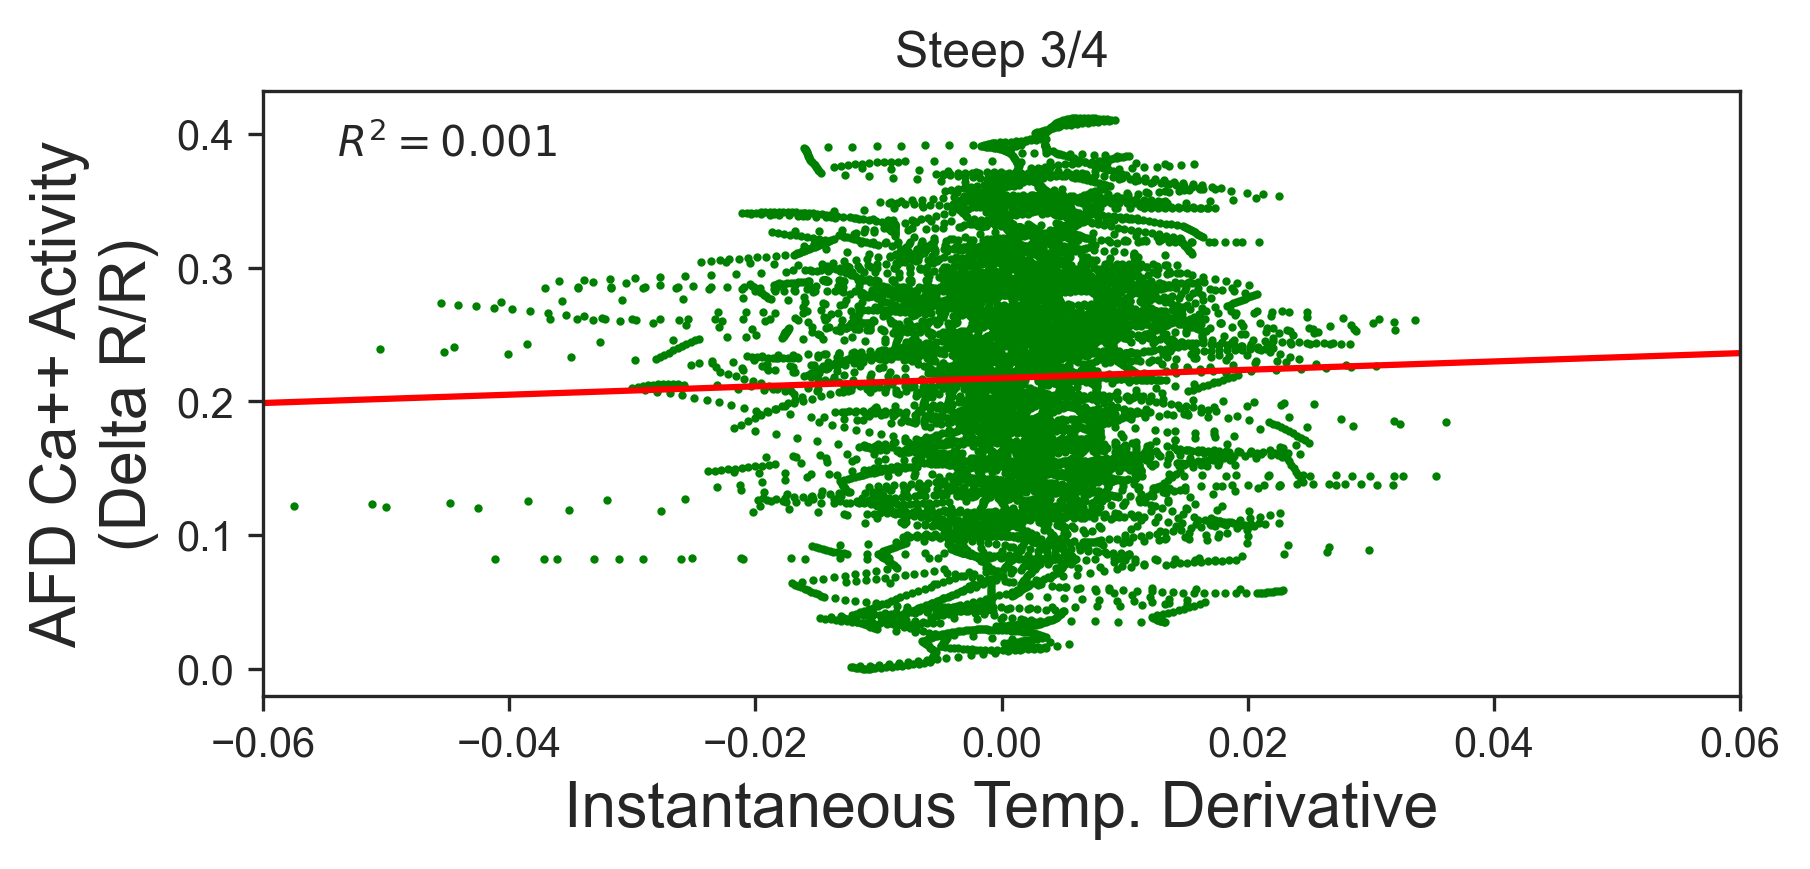

In [ ]:
from scipy import stats
temp_deriv_steep_3_4_20 = calc_temp_deriv(Time_steep_3_4_20, Temp_steep_3_4_20 )
x = np.array(temp_deriv_steep_3_4_20)
y = np.array(DeltaR_steep_3_4_20)
# Mask out NaNs or Infs if they exist
mask = ~np.isnan(x) & ~np.isnan(y)
x_reg = x[mask]
y_reg = y[mask]

# Perform Linear Regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x_reg, y_reg)
r_squared = r_value**2
x_range = np.linspace(-0.06, 0.06, 100)
y_line = slope * x_range + intercept
x_range = np.linspace(-0.06, 0.06, 100)
y_line = slope * x_range + intercept

text_label = f'$R^2 = {r_squared:.3f}$\n'

plt.clf()
plt.figure(figsize=(6,3), dpi=300)
plt.scatter(temp_deriv_steep_3_4_20,\
         DeltaR_steep_3_4_20, c='g', s=1)
plt.plot(x_range, y_line, color='red', lw=1.5, label='Linear Fit')
plt.xlabel('Instantaneous Temp. Derivative', fontsize=15)
plt.ylabel('AFD Ca++ Activity\n(Delta R/R)', fontsize=15)
plt.gca().text(0.05, 0.95, text_label, transform=plt.gca().transAxes, 
               fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.tick_params(axis = 'both', labelsize=10)
plt.title('Steep 3/4')
plt.tight_layout()
plt.xlim(-0.06,0.06)
#plt.savefig('C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/FreelyMoving_Behavior_Strats_Labeling/3_4_20_Allpts_Deriv_vs_InstCa.svg', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

